# Gap-Filling & Distressed Time-Series Reconstruction
### Equity Portfolio · Distress Events · Restructuring Regime Breaks

### Notebook Roadmap

| Section | Focus | Core Output |
|--------|-------|-------------|
| 0 | Problem setup | Distress and regime-break framing |
| 1 | Data construction | Real-data-driven AAPL reference + stressed observed path |
| 2 | Diagnostics | Returns + legacy-regime correlation |
| 3A | Simple baselines | Forward fill / backward fill / interpolation |
| 3B | Return clipping | IQR and 3-sigma winsorized reconstructions |
| 3C | Compatibility baseline | No-op placeholder (corporate-action logic removed) |
| 3D | Spline interpolation | Smooth anchor-based reconstruction |
| 3E-3I | Proxy methods | Static/dynamic/feature/PCA peer-based reconstructions |
| 4 | Evaluation | RMSE · MAE · correlation vs legacy reference |
| 5 | Decision guide | Method selection under regime breaks |
| 6 | Backtesting | Strategy impact of reconstructed inputs |

## 0. The Problem — What Is a "Distressed" Stock Series?

> **In plain English**: imagine you are a quant analyst backtesting a portfolio strategy.
> Your historical price data for one stock looks fine most of the time, but in one specific
> period prices become misleading relative to sector peers:
>
> **A distress-and-restructuring episode** — for 30 days the stock crashes, trades like a
> distressed security, and then emerges as a **restructured company**. From that point onward,
> it should be treated economically as a *new regime* with different betas, different volatility,
> and potentially a different business mix.

### Why Does This Matter?

| Use-case | What goes wrong with raw corrupted data |
|----------|-----------------------------------------|
| Backtesting | Strategy returns are distorted during the event |
| Risk models (VaR/CVaR) | Covariance matrix can mix incompatible regimes |
| Factor models | Beta estimates from the legacy stock are contaminated by post-restructuring behavior |
| Portfolio optimisation | The optimiser treats different economic states as one asset |
| ML features | Regime break harms stationarity |

### The Goal of This Notebook

We reconstruct **what the legacy pre-restructuring AAPL proxy series would have looked like during the distressed window**, using methods of increasing sophistication.

In this notebook:

- the distressed window belongs to the **legacy** entity,
- the post-distress period belongs to a **restructured** entity,
- methods that rely heavily on post-distress anchors are economically suspicious.

| Tier | Approach | Complexity |
|------|----------|------------|
| Simple | Forward fill · Backward fill · Linear interpolation | ⭐ |
| Statistical | Return winsorization (IQR clip, 3σ cap) | ⭐⭐ |
| Smooth | Cubic spline through anchor points | ⭐⭐⭐ |
| ML / Proxy | Regime-aware clustering + OLS regression on peer group | ⭐⭐⭐⭐ |

> **Reference note**: this notebook uses real AAPL prices as the legacy reference (`DIST_TRUE = AAPL_ORIG`) and injects only distress-window corruption into `DIST_OBS` for evaluation.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.interpolate import CubicSpline
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (14, 5), 'font.size': 11})
print('Libraries loaded successfully')

Libraries loaded successfully


In [4]:
instruments_df = pd.read_csv('./data/instruments.csv')
stocks_data_df = pd.read_csv('./data/stock_data.csv')

In [5]:
stocks_data_df.head()

,Date,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,...,WTW,WY,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZTS
0,2023-10-02,109.266762,172.064636,136.820404,136.559998,91.604523,75.472816,297.877075,521.130005,169.505737,...,203.134720,28.268171,90.666245,51.283436,107.814781,89.705528,120.291656,109.461388,233.630005,168.976089
1,2023-10-03,108.636185,170.727737,136.063629,127.730003,91.661942,74.132050,295.915466,507.029999,165.718109,...,201.582932,27.815580,88.317131,52.038292,108.001274,88.054436,118.300568,108.380722,230.330002,166.628250
2,2023-10-04,110.025406,171.975525,136.303604,127.410004,91.527977,76.509293,298.968964,518.419983,167.921127,...,203.583649,28.202169,86.339958,52.774506,103.963928,89.119347,118.819992,107.761803,230.940002,167.273926
3,2023-10-05,108.724861,173.213379,136.082108,124.989998,92.054276,77.631355,299.229950,516.440002,166.288223,...,203.564117,28.305887,87.592804,52.634716,101.623566,88.064224,117.194412,107.378654,222.539993,168.261948
4,2023-10-06,109.010582,175.768372,136.811172,126.360001,92.704971,78.144844,301.674713,526.679993,168.095062,...,204.149689,28.117310,90.450912,53.445484,99.926582,88.875107,114.905167,108.960358,223.850006,171.764160


## Section 1 — Real-Data-Driven AAPL Scenario with Distress and Regime Break

### Data Construction Logic

We build a six-name analysis universe directly from `instruments_df` and `stocks_data_df`:

- one target: `AAPL`
- three same-sector peers (mapped to `PEER_A`, `PEER_B`, `PEER_C`)
- two cross-sector peers (mapped to `OTHER_X`, `OTHER_Y`)

The clean legacy reference process is now the **actual AAPL price path** (`DIST_TRUE = AAPL_ORIG`).

### Why This Setup?

The point is to preserve realistic market structure while running controlled reconstruction experiments:

- peer co-movement is learned from observed returns
- sector relationships come from instrument metadata
- distress corruption is injected transparently for comparison

### Portfolio Structure

| Stock | Sector role | Notebook role |
|-------|-------------|---------------|
| PEER_A | Same sector as AAPL | Clean peer |
| PEER_B | Same sector as AAPL | Clean peer |
| PEER_C | Same sector as AAPL | Clean peer |
| DIST | Legacy AAPL reference path | Target series — distress then regime change |
| OTHER_X | Different sector | Lower-priority peer candidate |
| OTHER_Y | Different sector | Lower-priority peer candidate |

### Injected Scenario Event

| Event | Day range | Type | Description |
|-------|-----------|------|-------------|
| Distress window | Sample-dependent | Legacy-entity corruption | controlled drawdown then recovery shape |
| Restructuring date | End of distress window | Regime break | post-event observations treated as a new regime |

The crucial modelling assumption is this:

> **After restructuring, DIST is no longer the same statistical object.**
> The post-event observations are allowed to exist in the dataset, but they should not be used as if they were continuation points of the legacy stock.

In [18]:
# Build the portfolio from real inputs (instruments_df + stocks_data_df)
TARGET_TICKER = 'MSFT'
MIN_PEER_HISTORY_DAYS = 120
MIN_PEER_COVERAGE = 0.85
MAX_MODEL_PEERS = 25  # final model subset selected from full same-sector candidate universe

meta = instruments_df.copy()
meta['symbol'] = meta['symbol'].astype(str).str.upper()
sector_lookup = meta.set_index('symbol')['sector'].to_dict()
target_sector = sector_lookup.get(TARGET_TICKER)

prices_wide = stocks_data_df.copy()
prices_wide['Date'] = pd.to_datetime(prices_wide['Date'])
prices_wide = prices_wide.sort_values('Date').set_index('Date')
prices_wide.columns = [str(c).upper() for c in prices_wide.columns]

# Keep only tickers that also exist in instrument metadata
valid_tickers = [c for c in prices_wide.columns if c in set(meta['symbol'])]
prices_wide = prices_wide[valid_tickers]

if TARGET_TICKER not in prices_wide.columns:
    raise ValueError(f'{TARGET_TICKER} not available in stocks_data_df')

# Candidate universe: ALL same-sector tickers
same_sector_all = [
    s for s in valid_tickers
    if s != TARGET_TICKER and sector_lookup.get(s) == target_sector
]

target_ret_all = np.log(prices_wide[TARGET_TICKER] / prices_wide[TARGET_TICKER].shift(1))

# Rank candidates by empirical performance vs TARGET_TICKER in overlapping history
def evaluate_candidates(cands, target):
    rows = []
    for t in cands:
        px = prices_wide[t]
        overlap_px = pd.concat([prices_wide[target], px], axis=1).dropna()
        if len(overlap_px) < MIN_PEER_HISTORY_DAYS:
            continue

        ret_t = np.log(px / px.shift(1))
        overlap_ret = pd.concat([target_ret_all, ret_t], axis=1).dropna()
        if len(overlap_ret) < MIN_PEER_HISTORY_DAYS:
            continue

        corr = overlap_ret.iloc[:, 0].corr(overlap_ret.iloc[:, 1])
        mae = (overlap_ret.iloc[:, 0] - overlap_ret.iloc[:, 1]).abs().mean()
        coverage = prices_wide[t].notna().mean()

        if pd.isna(corr):
            continue

        perf_score = abs(corr) * coverage / (1.0 + mae)
        rows.append({
            'ticker': t,
            'sector': sector_lookup.get(t),
            'corr_to_target': float(corr),
            'abs_corr': float(abs(corr)),
            'ret_mae': float(mae),
            'coverage': float(coverage),
            'overlap_days': int(len(overlap_ret)),
            'peer_score': float(perf_score),
        })

    if not rows:
        return pd.DataFrame(columns=['ticker', 'sector', 'corr_to_target', 'abs_corr', 'ret_mae', 'coverage', 'overlap_days', 'peer_score'])

    return pd.DataFrame(rows).sort_values(['peer_score', 'abs_corr'], ascending=False).reset_index(drop=True)

same_sector_perf = evaluate_candidates(same_sector_all, TARGET_TICKER)

# Keep all qualifying same-sector peers as candidate basket
same_sector_peers = same_sector_perf[same_sector_perf['coverage'] >= MIN_PEER_COVERAGE]['ticker'].tolist()
if len(same_sector_peers) < 3:
    same_sector_peers = same_sector_perf['ticker'].tolist()
if len(same_sector_peers) < 3:
    raise ValueError('Not enough same-sector peers after performance screening')

# Final model subset: best peers by score from the broad same-sector basket
model_peer_cols = [t for t in same_sector_perf['ticker'].tolist() if t in same_sector_peers][:MAX_MODEL_PEERS]
if len(model_peer_cols) < 5:
    raise ValueError('Model peer subset is too small after ranking')

# No cross-sector peers in the model universe (per request)
cross_sector_peers = []

# Dedicated peers dataframe and dictionaries for downstream logic
peers_df = pd.DataFrame(
    [{'ticker': TARGET_TICKER, 'sector': target_sector, 'peer_bucket': 'target'}]
    + [{'ticker': t, 'sector': sector_lookup.get(t), 'peer_bucket': 'same_sector'} for t in same_sector_peers]
)
peer_sector_map = peers_df.set_index('ticker')['sector'].to_dict()
peer_bucket_map = peers_df.groupby('peer_bucket')['ticker'].apply(list).to_dict()

# Performance table for diagnostics and downstream selection
peers_performance_df = same_sector_perf.assign(peer_bucket='same_sector')

selected_tickers = [TARGET_TICKER] + same_sector_peers
raw = prices_wide[selected_tickers].dropna().copy()

if len(raw) < MIN_PEER_HISTORY_DAYS:
    raise ValueError(f'Not enough common history after broad peer selection: {len(raw)} days')

# Keep a manageable common sample length for the notebook logic
N_DAYS = min(500, len(raw))
raw = raw.iloc[-N_DAYS:]
dates = raw.index

# Main price container
prices_df = pd.DataFrame(index=dates)
for t in same_sector_peers + [TARGET_TICKER]:
    prices_df[t] = raw[t]
prices_df['TARGET_ORIG'] = raw[TARGET_TICKER]

# Use real TARGET_TICKER as legacy reference (no synthetic price path)
prices_df['DIST_TRUE'] = prices_df['TARGET_ORIG'].copy()

# Distress event settings
DIST_START = max(40, int(0.60 * N_DAYS))
DIST_END = min(DIST_START + 30, N_DAYS - 5)
RESTRUCTURE_DAY = DIST_END
DIST_DEPTH = 0.35

# Legacy compatibility placeholders
GAP_DAY = 0
GAP_FACTOR = 1.0
adj_factor = 1.0

# Create observed (corrupted) series from actual TARGET_TICKER legacy path (distress only)
DIST_OBS = prices_df['DIST_TRUE'].values.copy()

n_d = DIST_END - DIST_START
for i in range(n_d):
    t_norm = i / (n_d - 1) if n_d > 1 else 0.0
    dev = -DIST_DEPTH * np.sin(np.pi * t_norm)
    DIST_OBS[DIST_START + i] = prices_df['DIST_TRUE'].iloc[DIST_START + i] * (1 + dev)

prices_df['DIST_OBS'] = DIST_OBS

# Backward-compatibility aliases for older cells
if len(model_peer_cols) >= 3:
    prices_df['PEER_A'] = prices_df[model_peer_cols[0]]
    prices_df['PEER_B'] = prices_df[model_peer_cols[1]]
    prices_df['PEER_C'] = prices_df[model_peer_cols[2]]
if len(model_peer_cols) >= 5:
    prices_df['OTHER_X'] = prices_df[model_peer_cols[3]]
    prices_df['OTHER_Y'] = prices_df[model_peer_cols[4]]
P = prices_df

# Keep original mask variable names used throughout the notebook
gap_mask = np.zeros(N_DAYS, dtype=bool)
dist_mask = np.zeros(N_DAYS, dtype=bool)
dist_mask[DIST_START:DIST_END] = True
post_restructure_mask = np.zeros(N_DAYS, dtype=bool)
post_restructure_mask[RESTRUCTURE_DAY:] = True
legacy_clean_mask = (~dist_mask) & (~post_restructure_mask)
clean_mask = legacy_clean_mask.copy()

# Data shape checks
required_cols = model_peer_cols + ['TARGET_ORIG', 'DIST_TRUE', 'DIST_OBS']
missing_cols = [c for c in required_cols if c not in prices_df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns in prices_df: {missing_cols}')
if prices_df[required_cols].isna().any().any():
    raise ValueError('prices_df contains NaNs in required columns')
if peers_df[['ticker', 'sector', 'peer_bucket']].isna().any().any():
    raise ValueError('peers_df contains NaNs in required metadata')

# Use top-ranked peers for plotting readability
plot_same_sector_peers = model_peer_cols[:12]
plot_cross_sector_peers = []

print(f'Target ticker: {TARGET_TICKER} | sector: {target_sector}')
print(f'Same-sector universe size (all candidates): {len(same_sector_all)}')
print(f'Same-sector candidate basket after quality screen: {len(same_sector_peers)}')
print(f'Model peer subset (best by performance): {len(model_peer_cols)}')
print('Top same-sector peers by score:')
print(same_sector_perf[['ticker', 'peer_score', 'corr_to_target', 'ret_mae', 'coverage']].head(12).to_string(index=False))
print(f'Sample: {N_DAYS} trading days | starts {dates[0].date()} | ends {dates[-1].date()}')
print(f'Distress window: day {DIST_START}-{DIST_END-1} ({dates[DIST_START].date()} - {dates[DIST_END-1].date()}) -> max dip {DIST_DEPTH*100:.0f}%')
print(f'Restructuring: day {RESTRUCTURE_DAY} ({dates[RESTRUCTURE_DAY].date()})')
print('prices_df uses real TARGET_ORIG as DIST_TRUE reference; DIST_OBS is distress-only corrupted version.')

Target ticker: MSFT | sector: Information Technology
Same-sector universe size (all candidates): 68
Same-sector candidate basket after quality screen: 66
Model peer subset (best by performance): 25
Top same-sector peers by score:
ticker  peer_score  corr_to_target  ret_mae  coverage
   NOW    0.564552        0.571641 0.012557       1.0
  CDNS    0.548414        0.555248 0.012461       1.0
   APH    0.535083        0.541097 0.011239       1.0
  NVDA    0.534219        0.544585 0.019402       1.0
  AAPL    0.494745        0.500464 0.011559       1.0
  CRWD    0.489408        0.497902 0.017356       1.0
  ANET    0.479970        0.488331 0.017421       1.0
  MPWR    0.469315        0.479320 0.021318       1.0
  LRCX    0.464128        0.472015 0.016992       1.0
  AVGO    0.461092        0.469356 0.017922       1.0
   AMD    0.459485        0.468587 0.019809       1.0
   WDC    0.453479        0.461224 0.017081       1.0
Sample: 500 trading days | starts 2023-10-03 | ends 2025-09-30
Distr

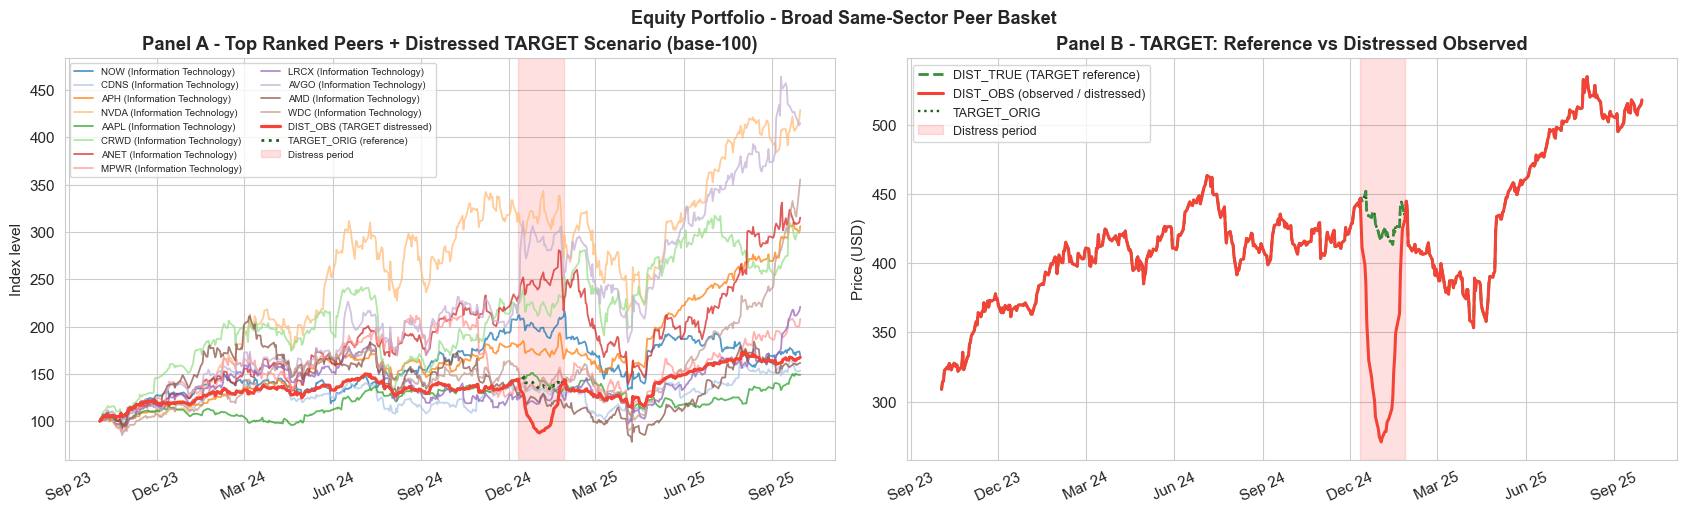

In [19]:
# First look at the portfolio and at observed-vs-reference AAPL path
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Use full peer basket in computation, but top-ranked subset in this chart for readability
plot_peer_cols = plot_same_sector_peers + plot_cross_sector_peers
peer_colors = sns.color_palette('tab20', n_colors=max(len(plot_peer_cols), 1))
peer_palette = {t: peer_colors[i] for i, t in enumerate(plot_peer_cols)}

# Panel A: show top-ranked peers + observed distressed path + original AAPL reference
ax = axes[0]
for t in plot_peer_cols:
    lbl = f"{t} ({peer_sector_map.get(t, 'Unknown')})"
    ax.plot(dates, prices_df[t] / prices_df[t].iloc[0] * 100,
            color=peer_palette[t], alpha=0.75, lw=1.3, label=lbl)
ax.plot(dates, prices_df['DIST_OBS'] / prices_df['DIST_OBS'].iloc[0] * 100,
        color='#F44336', lw=2.3, label='DIST_OBS (TARGET distressed)', zorder=5)
ax.plot(dates, prices_df['TARGET_ORIG'] / prices_df['TARGET_ORIG'].iloc[0] * 100,
        color='#1B5E20', lw=2.0, ls=':', label='TARGET_ORIG (reference)', zorder=4)
ax.axvspan(dates[DIST_START], dates[DIST_END - 1],
           color='red', alpha=0.12, label='Distress period')
ax.set_title('Panel A - Top Ranked Peers + Distressed TARGET Scenario (base-100)', fontweight='bold')
ax.set_ylabel('Index level')
ax.legend(fontsize=7, loc='upper left', ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

# Panel B: compare reference path, distressed observed, and original TARGET
ax = axes[1]
ax.plot(dates, prices_df['DIST_TRUE'], color='#388E3C', lw=2,
        ls='--', label='DIST_TRUE (TARGET reference)', zorder=4)
ax.plot(dates, prices_df['DIST_OBS'], color='#F44336', lw=2.2,
        label='DIST_OBS (observed / distressed)', zorder=5)
ax.plot(dates, prices_df['TARGET_ORIG'], color='#1B5E20', lw=1.7,
        ls=':', label='TARGET_ORIG', zorder=3)
ax.axvspan(dates[DIST_START], dates[DIST_END - 1],
           color='red', alpha=0.12, label='Distress period')
ax.set_title('Panel B - TARGET: Reference vs Distressed Observed', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

plt.tight_layout()
plt.suptitle('Equity Portfolio - Broad Same-Sector Peer Basket',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

### How to Read These First Portfolio Graphs

This figure gives your first visual map of the real-data-driven AAPL scenario.
Read it as: **what is normal in the portfolio, and what exactly is wrong with DIST?**

### Panel A — Full Portfolio

**What it shows**

All peer tickers are scaled to start at the same base level, so you can compare paths fairly.
This lets you focus on **relative movement** instead of raw dollar differences.

**Why we use it**

We want to see whether DIST broadly lives in the same world as the selected peers before the distress period.
Peer choice comes from `peers_df` and the `peer_bucket_map` / `peer_sector_map` dictionaries.

**How to read it**

1. Ignore absolute price levels and compare line shapes.
2. Look for which names move together over time.
3. Focus on the highlighted distress window.
4. Ask whether DIST looks peer-like before distress and abnormal inside distress.

### Panel B — DIST: Reference vs Observed

**What it shows**

This compares the legacy reference path (`DIST_TRUE`, equal to `TARGET_ORIG`) with the distressed observed path (`DIST_OBS`).

**Why we use it**

This is the benchmark visual for the whole notebook. It shows the exact corruption later methods try to fix.

**How to read it**

1. Compare the dashed reference line with the observed red line.
2. In the distress window, see how far the observed series falls below the reference.
3. After restructuring, remember post-event behavior belongs to a different regime.

**Debugger tip**

If later reconstruction plots are confusing, come back to this panel first.

## Section 2 — Returns & Correlation Structure

Before applying reconstruction, we analyse the **daily log-return** series and
the **pairwise correlation** structure.

> **What is a log return?**
> $r_t = \ln(P_t / P_{t-1})$
> For small changes it is almost identical to simple return $(P_t - P_{t-1})/P_{t-1}$.
> Log returns are additive over time and often easier to model statistically.

A critical regime rule is now in force:

- compute the correlation heatmap using **legacy clean days only**
- exclude the distressed window
- exclude the **post-restructuring regime**, because after restructuring DIST is not the same statistical object.

This matters because otherwise we mix two economically different entities into one estimate.

The legacy-regime heatmap should reveal the peer structure supporting later proxy methods.

In [20]:
# Pick performance-selected model peers and target columns for return conversion
peer_cols = model_peer_cols.copy()
price_cols = peer_cols + ['DIST_OBS']
prices_for_ret = prices_df[price_cols].copy()

print(f'Candidate same-sector peers: {len(same_sector_peers)} | Model peers used: {len(peer_cols)}')
print('Model peers (top 15):', peer_cols[:15])

Candidate same-sector peers: 66 | Model peers used: 25
Model peers (top 15): ['NOW', 'CDNS', 'APH', 'NVDA', 'AAPL', 'CRWD', 'ANET', 'MPWR', 'LRCX', 'AVGO', 'AMD', 'WDC', 'FFIV', 'ADSK', 'KLAC']


In [21]:
# Convert prices to daily log returns and rename DIST_OBS to DIST
ret_df = np.log(prices_for_ret / prices_for_ret.shift(1)).dropna()
ret_df = ret_df.rename(columns={'DIST_OBS': 'DIST'})

In this cell, `legacy_clean_mask` means: use only days where DIST still behaves like the original pre-restructuring stock and is not contaminated by distress corruption.

So a day is `True` in `legacy_clean_mask` only if it is:

* not inside the distressed window
* not after the restructuring date
* Why we need it in this cell:

The cell estimates the normal correlation structure of the legacy stock versus peers.
* If you include the distress window, you mix in corrupted prices that no longer reflect the clean legacy process.
* If you include post-restructuring data, you are no longer looking at the same economic/statistical asset.


In [22]:
# Shift the mask because returns start one day after prices
legacy_ret_mask = legacy_clean_mask[1:]
ret_legacy = ret_df.iloc[np.where(legacy_ret_mask)[0]]
corr_clean = ret_legacy.corr()

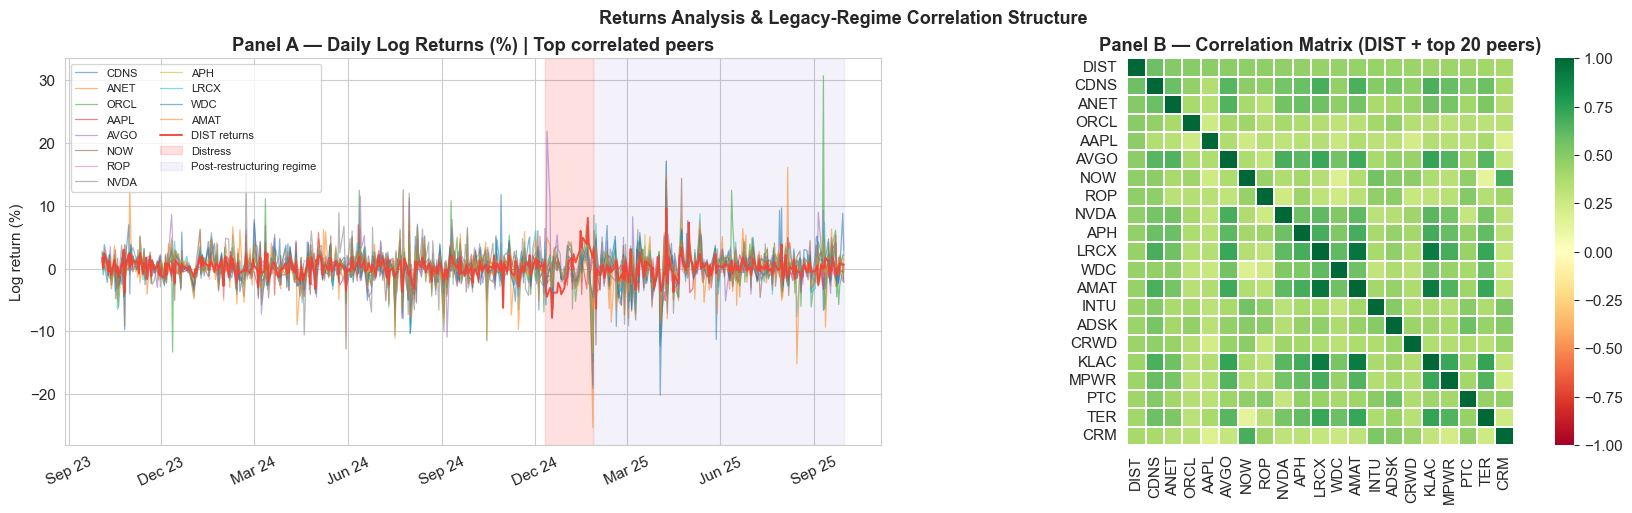

Top correlations with DIST (legacy clean days):
CDNS    0.572825
ANET    0.501123
ORCL    0.485171
AAPL    0.479916
AVGO    0.477039
NOW     0.476302
ROP     0.472074
NVDA    0.462354
APH     0.459977
LRCX    0.449336
WDC     0.448259
AMAT    0.445730
INTU    0.437809
ADSK    0.435545
CRWD    0.430499
KLAC    0.427833
MPWR    0.426934
PTC     0.415363
TER     0.406343
CRM     0.391685


In [23]:

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Focus visuals on the strongest peers while keeping full matrix for computation
if 'DIST' not in corr_clean.columns:
    raise ValueError('DIST column missing in corr_clean')

corr_to_dist = corr_clean['DIST'].drop('DIST').sort_values(ascending=False)
plot_peer_cols = corr_to_dist.head(12).index.tolist()
heatmap_cols = ['DIST'] + corr_to_dist.head(20).index.tolist()

# Panel A: show daily returns for top peers and DIST
ax = axes[0]
peer_colors = sns.color_palette('tab10', n_colors=max(len(plot_peer_cols), 1))
for col, c in zip(plot_peer_cols, peer_colors):
    ax.plot(ret_df.index, ret_df[col] * 100, color=c, alpha=0.55, lw=0.9, label=col)
ax.plot(ret_df.index, ret_df['DIST'] * 100,
        color='#F44336', lw=1.4, alpha=0.95, label='DIST returns')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1],
           color='red', alpha=0.12, label='Distress')
ax.axvspan(dates[RESTRUCTURE_DAY], dates[-1],
           color='slateblue', alpha=0.08, label='Post-restructuring regime')
ax.set_title('Panel A — Daily Log Returns (%) | Top correlated peers', fontweight='bold')
ax.set_ylabel('Log return (%)')
ax.legend(fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

# Panel B: show reduced correlation matrix for readability
ax = axes[1]
corr_plot = corr_clean.loc[heatmap_cols, heatmap_cols]
sns.heatmap(corr_plot, annot=False, cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.3, linecolor='white')
ax.set_title('Panel B — Correlation Matrix (DIST + top 20 peers)', fontweight='bold')

plt.tight_layout()
plt.suptitle('Returns Analysis & Legacy-Regime Correlation Structure',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

print('Top correlations with DIST (legacy clean days):')
print(corr_to_dist.head(20).to_string())

### How to Read the Returns and Correlation Graphs

This figure moves from **price levels** to **returns and relationships**.
Read it as: **how noisy is DIST day to day, and which stocks are actually close enough to be useful peers?**

### Panel A — Daily Log Returns

**What it shows**

Each line is a daily log-return series rather than a price path.
Returns make spikes and abnormal moves easier to see.

**Why we use it**

Proxy models, clipping rules, and correlations are all easier to understand in return space than in price space.

**How to read it**

1. Look for unusually large spikes, especially around the gap day and distress window.
2. Compare DIST's return swings with the peer stocks.
3. In the post-restructuring area, ask whether DIST still behaves like the same asset.
4. If DIST becomes visibly different, that supports the regime-break story.

### Panel B — Legacy Clean Correlation Matrix

**What it shows**

This heatmap shows pairwise correlations using only the clean legacy days.
Each number tells you how strongly two return series moved together during the valid training regime.

**Why we use it**

Later peer-based methods rely on correlated stocks. This panel checks whether the basic proxy assumption is economically reasonable.

**How to read it**

1. Find the DIST row or column first.
2. Look for the largest positive correlations with DIST.
3. Check whether the expected tech peers are close to DIST and whether unrelated names are weaker.
4. Stronger green values mean better candidate proxies; lower values suggest weaker economic similarity.

**Debugger tip**

If the best DIST correlations are weak or economically strange, later proxy methods may fail for a simple reason: the peer universe is poor.

## Reconstruction Methods — Overview

All approaches below target the **legacy distress period** (days 180–209).
The corporate-action gap (day 100) is handled specifically in Approach 3C.

> **The central question**: during the 30 distressed legacy days, what price would DIST have had
> *if the credit event had not occurred and before the restructuring reset its parameters*?

Each method answers this differently:

| Method | Core idea | Handles gap? | Handles distress? |
|--------|-----------|:---:|:---:|
| 3A Forward fill | Freeze at last legacy clean price | partial | ✓ |
| 3A Backward fill | Pull in first post-distress observation | partial | ✓ |
| 3A Linear interp | Straight line between pre- and post-window endpoints | partial | ✓ |
| 3B Winsorization | Cap extreme daily *returns* | ✓ | partial |
| 3C Back-adjustment | Divide historical prices by gap factor | ✓ | ✗ |
| 3D Cubic spline | Smooth curve through anchor points | partial | ✓ |
| 3E Dynamic proxy + rolling OLS | Use legacy-regime peer relationships to infer missing returns | ✓ | ✓ |

> **Key insight**: methods 3A–3D are purely *mechanical* — they use only DIST's own history.
> Under restructuring, that becomes a serious limitation because the post-distress observations may belong
> to a **different economic entity**. Method 3E is more appropriate because it can be trained entirely on
> the legacy regime and does not need to assume that the post-restructuring price is a valid anchor for the old stock.

## Section 3 — Reconstruction Methods for the Distress Window

All approaches below target the **legacy distress period** only.

| Method | Core idea | Handles distress? |
|--------|-----------|-------------------|
| 3A Forward fill | Carry last clean level through window | partial |
| 3A Backward fill | Pull in first post-window observation | partial |
| 3A Linear interpolation | Bridge two anchors with straight line | partial |
| 3B Return clipping | Cap extreme returns then rebuild prices | ✓ |
| 3C No-op baseline | Compatibility placeholder (no transformation) | n/a |
| 3D Cubic spline | Smooth curve through anchor points | ✓ |
| 3E-3I Proxy methods | Peer-based regime-aware reconstruction | ✓ |

The central question is: what would the legacy AAPL path have looked like inside the distress window without the corruption?

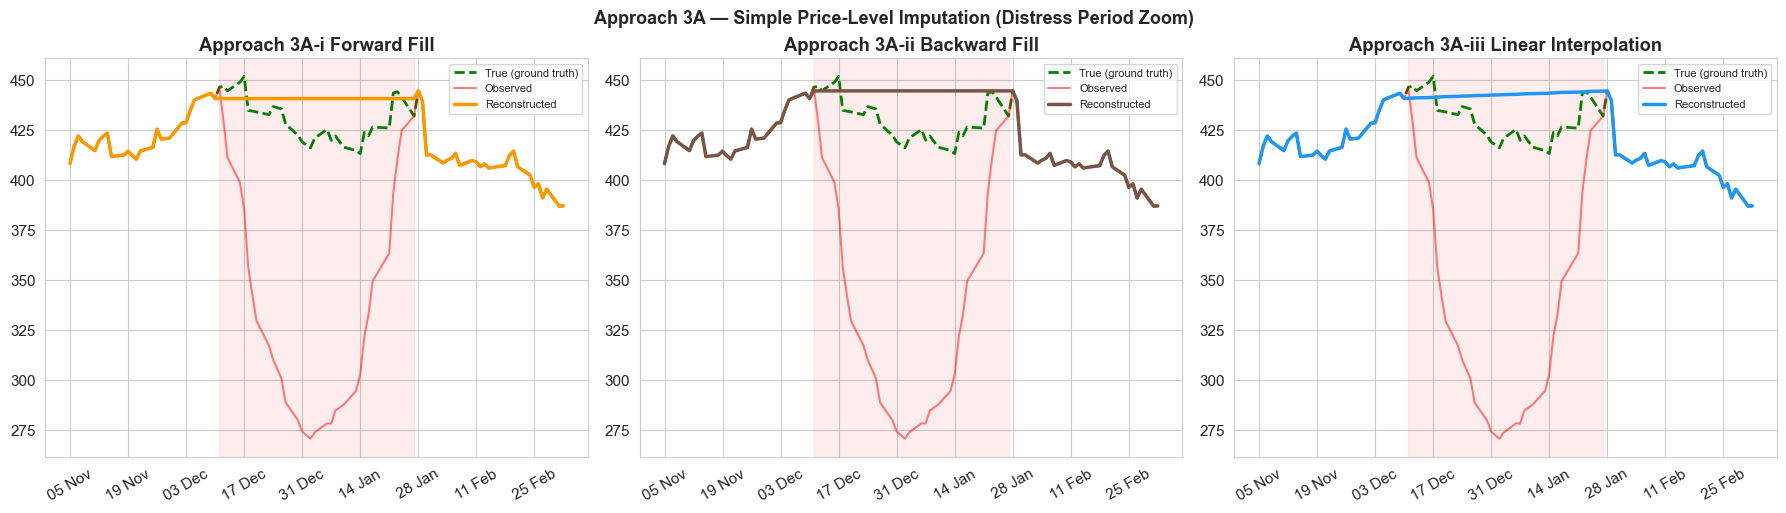

In [24]:
# Simple price-filling methods for the distressed window
# Use the last clean price and the first price after the window as anchors

anchor_pre  = P['DIST_OBS'].iloc[DIST_START - 1]   # last clean price before distress
anchor_post = P['DIST_OBS'].iloc[DIST_END]          # first price after distress

# Method A: keep the price flat at the last clean value
dist_ffill = P['DIST_OBS'].copy()
dist_ffill.iloc[DIST_START:DIST_END] = anchor_pre

# Method B: fill the window with the first price after it
dist_bfill = P['DIST_OBS'].copy()
dist_bfill.iloc[DIST_START:DIST_END] = anchor_post

# Method C: remove the distressed window, then connect the ends with a straight line
dist_linear = P['DIST_OBS'].copy()
dist_linear.iloc[DIST_START:DIST_END] = np.nan
dist_linear = dist_linear.interpolate(method='linear')

# Zoom in around the distressed period so the differences are easier to see
z0, z1 = DIST_START - 25, DIST_END + 25
zd = dates[z0:z1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles  = ['3A-i Forward Fill', '3A-ii Backward Fill', '3A-iii Linear Interpolation']
series  = [dist_ffill,           dist_bfill,             dist_linear]
colours = ['#FF9800',            '#795548',               '#2196F3']

for ax, s, ttl, c in zip(axes, series, titles, colours):
    ax.plot(zd, P['DIST_TRUE'].iloc[z0:z1], 'g--', lw=2,   label='True (ground truth)')
    ax.plot(zd, P['DIST_OBS'].iloc[z0:z1],  'r-',  lw=1.5, alpha=0.5, label='Observed')
    ax.plot(zd, s.iloc[z0:z1],              '-',   lw=2.5, color=c, label='Reconstructed')
    ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
    ax.set_title(f'Approach {ttl}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.suptitle('Approach 3A — Simple Price-Level Imputation (Distress Period Zoom)',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

# Save these reconstructed series for the later comparison table
recon = {
    'Forward Fill':  dist_ffill,
    'Backward Fill': dist_bfill,
    'Linear Interp': dist_linear,
}

### How to Read the Approach 3A Graphs

This figure compares the three simplest price-filling methods.
Read it as: **what happens if we fill the distressed window mechanically without using peer information?**

### The three panels

- left: forward fill
- middle: backward fill
- right: linear interpolation

Each panel shows the same three ingredients: ground truth, observed distressed series, and reconstructed series.

### Why we use this figure

These methods are basic baselines. They help beginners see what a very simple imputation looks like before moving to more statistical or proxy-based methods.

### How to read each panel

1. Compare the reconstructed line with the dashed true line inside the red distressed window.
2. Check whether the method captures the direction and shape of the clean legacy path.
3. Notice how much each method depends on anchor choices rather than real market information.

### What each method is telling you

**Forward fill**

- holds the price flat at the last clean value
- good as a crude benchmark for very short gaps
- easy to spot because the line becomes flat through the window

**Backward fill**

- uses the first price after the window as the fill value
- visually simple, but dangerous if that post-window point already belongs to the restructured stock
- easy to spot because the entire missing window is pinned to the future anchor

**Linear interpolation**

- draws a straight line between the pre-window and post-window anchors
- can look smoother than the fills, but that smoothness may be fake
- easy to spot because the line moves with constant slope through the whole window

**Debugger tip**

If a simple method looks surprisingly good here, ask whether it is truly reconstructing the legacy process or just benefiting from convenient anchor points.

## Approach 3B — Return Winsorization

> **Simple idea**: instead of fixing the price chart directly, we first fix the **daily returns**.
> If one day shows an unrealistically large move, we cap it to a more reasonable value, then rebuild the price series from those cleaned returns.

### Step-by-step intuition

1. Start from the observed DIST price series.
2. Convert prices into **daily returns**.
3. Look only at the **clean period** to learn what a normal return usually looks like.
4. Set upper and lower limits for returns.
5. If a return is too extreme, replace it with the nearest limit.
6. Rebuild the price series using these capped returns.

### Why work with returns instead of prices?

Prices naturally drift over time, so price levels are harder to compare across the full sample.
Returns are more stable and easier to judge statistically.

For example:

- a price of 80 USD is not automatically "low" or "abnormal"
- but a one-day return of +26% is clearly unusual

So returns are a better place to detect suspicious jumps.

### The two clipping rules used here

We build return limits from the **clean returns only** using two methods:

#### 1. IQR clipping

- `Q1` = 25th percentile of clean returns
- `Q3` = 75th percentile of clean returns
- `IQR = Q3 - Q1`

Then we define the allowed range as:

$$[Q_1 - 3 \cdot \text{IQR},\ Q_3 + 3 \cdot \text{IQR}]$$

This method is **robust** because it focuses on the middle part of the data and is less influenced by extreme values.

#### 2. 3-sigma clipping

- $\bar r$ = average clean return
- $\sigma$ = standard deviation of clean returns

Then we define the allowed range as:

$$[\bar r - 3\sigma,\ \bar r + 3\sigma]$$

This method is based on the familiar idea that most normal observations should lie within about 3 standard deviations of the mean.

### How the price is rebuilt

After clipping the returns, we reconstruct the cleaned price path from the starting price:

$$P_t^{\text{clean}} = P_0 \cdot \prod_{s=1}^{t}(1 + r_s^{\text{clipped}})$$

In plain English:

- start from the first price
- apply each cleaned daily return one by one
- this gives a new price series with the extreme jumps reduced

### What this method is good at

- detecting and capping extreme one-day moves
- reducing the effect of abnormal spikes
- cleaning return series before further analysis

### Main limitation

This method rebuilds the whole price series by compounding returns from the beginning.
That means small errors can build up over time.

So even if each clipped return looks reasonable, the final reconstructed price level can slowly drift away from the true path.

This is called **error propagation**.

In [25]:
# Clean the DIST series by capping unusually large daily returns

dist_ret_obs = P['DIST_OBS'].pct_change()   # simple daily returns (first row is NaN)

# Learn what 'normal' returns look like from the clean days only
clean_returns = dist_ret_obs[clean_mask]

# IQR rule: build lower and upper bounds from the middle of the data
Q1, Q3 = clean_returns.quantile(0.25), clean_returns.quantile(0.75)
IQR = Q3 - Q1
lo_iqr, hi_iqr = Q1 - 3.0 * IQR, Q3 + 3.0 * IQR

# 3-sigma rule: build bounds from the mean and standard deviation
mu_c, sig_c = clean_returns.mean(), clean_returns.std()
lo_sig, hi_sig = mu_c - 3 * sig_c, mu_c + 3 * sig_c

def recon_from_returns(ret_clipped):
    # Start at S0 and rebuild the full price path one day at a time
    price = pd.Series(index=dates, dtype=float)
    price.iloc[0] = S0
    for i in range(1, N_DAYS):
        price.iloc[i] = price.iloc[i - 1] * (1 + ret_clipped.iloc[i])
    return price

dist_iqr   = recon_from_returns(dist_ret_obs.clip(lower=lo_iqr, upper=hi_iqr))
dist_3sig  = recon_from_returns(dist_ret_obs.clip(lower=lo_sig, upper=hi_sig))

# Plot the return limits and the cleaned price paths
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Panel A: raw returns with the clipping bands
ax = axes[0]
ax.plot(dates, dist_ret_obs * 100, color='#F44336', lw=0.7, alpha=0.8, label='Raw returns')
ax.axhline(lo_iqr * 100, color='#FF9800', ls='--', lw=1.5,
           label=f'IQR lower ({lo_iqr*100:.1f}%)')
ax.axhline(hi_iqr * 100, color='#FF9800', ls='--', lw=1.5,
           label=f'IQR upper ({hi_iqr*100:.1f}%)')
ax.axhline(lo_sig * 100, color='#9C27B0', ls=':', lw=1.5, label='3σ bounds')
ax.axhline(hi_sig * 100, color='#9C27B0', ls=':', lw=1.5)
ax.axvspan(dates[GAP_DAY - 1], dates[GAP_DAY + 1], color='gold', alpha=0.5)
ax.axvspan(dates[DIST_START], dates[DIST_END - 1],  color='red',  alpha=0.12)
ax.set_title('Panel A — Daily Returns with Clip Thresholds', fontweight='bold')
ax.set_ylabel('Return (%)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

# Panel B: compare the cleaned price paths around the distressed window
z0, z1 = DIST_START - 20, DIST_END + 20
ax = axes[1]
ax.plot(dates[z0:z1], P['DIST_TRUE'].iloc[z0:z1], 'g--', lw=2, label='True')
ax.plot(dates[z0:z1], P['DIST_OBS'].iloc[z0:z1],  'r-',  lw=1.5, alpha=0.5, label='Observed')
ax.plot(dates[z0:z1], dist_iqr.iloc[z0:z1],  color='#FF9800', lw=2, label='IQR winsorized')
ax.plot(dates[z0:z1], dist_3sig.iloc[z0:z1], color='#9C27B0', lw=2, label='3σ clipped')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
ax.set_title('Panel B — Reconstructed Prices (Distress Zoom)', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.suptitle('Approach 3B — Return Winsorization',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

recon['IQR Winsorize'] = dist_iqr
recon['3σ Clip']       = dist_3sig

NameError: name 'S0' is not defined

### How to Read the Approach 3B Graphs

This figure explains return winsorization from two angles: **what returns are being clipped** and **what price path that clipping produces**.

### Panel A — Daily Returns with Clip Thresholds

**What it shows**

You see raw daily DIST returns with the clipping boundaries drawn on top.
The IQR lines and 3-sigma lines show the range the method considers still acceptable based on clean data.

**Why we use it**

Before trusting the cleaned price path, you need to see whether the clipping rule is sensible.
This panel helps answer: **which returns are being treated as too extreme?**

**How to read it**

1. Look for return spikes that sit far outside the threshold lines.
2. Check whether the corporate-action jump and distress days are exactly the kind of extremes the method is meant to cap.
3. Compare the IQR and 3-sigma bands: wider bands are more tolerant, narrower bands are more aggressive.

### Panel B — Reconstructed Prices

**What it shows**

This panel shows what the clipped returns imply once they are compounded back into prices.

**Why we use it**

A clipping rule may look reasonable in return space but still produce drift in price space. This panel reveals that compounding effect.

**How to read it**

1. Compare each reconstructed line with the dashed true line in the distress window.
2. See whether the method removes the extreme drop without creating a long-run level drift.
3. Compare the IQR version with the 3-sigma version to see which balance of aggressiveness works better.

**Debugger tip**

If the clipping bands in Panel A look sensible but Panel B still drifts badly, the issue is probably error propagation from compounding many small return mistakes.

## Approach 3C — No-Op Baseline (Compatibility Only)

This section does not perform any transformation.
It is retained only to keep method ordering stable while focus remains on distress reconstruction approaches.

No-op baseline active: no structural-jump preprocessing is applied.
No-op series is an unchanged copy of DIST_OBS.


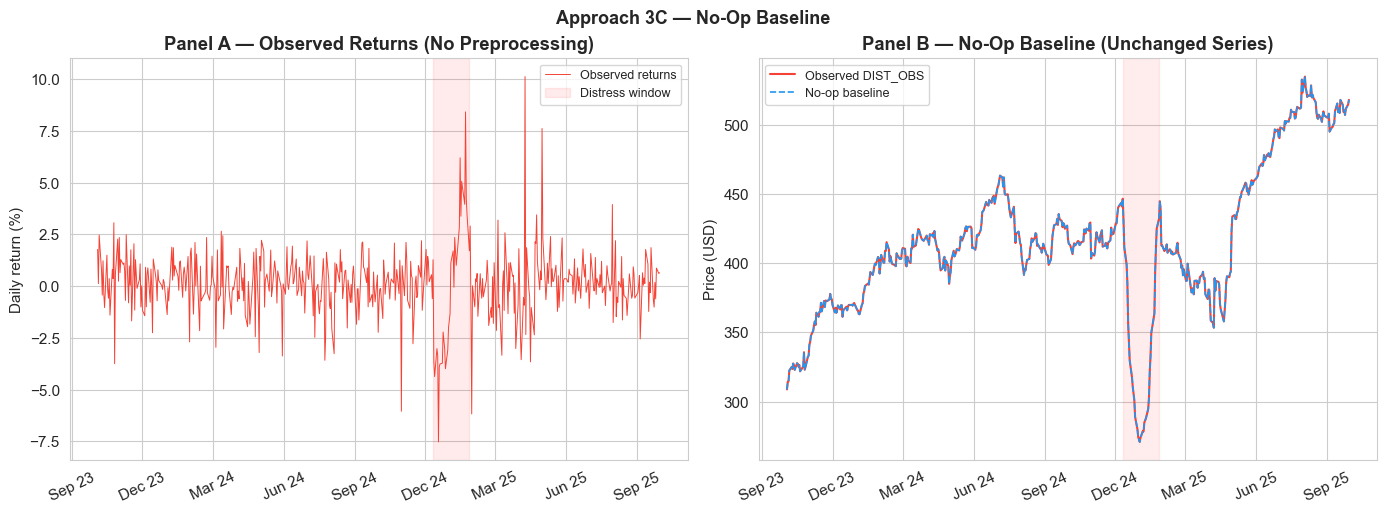

In [26]:
# No-op compatibility baseline: no structural-jump preprocessing is applied

dist_back_adj = prices_df['DIST_OBS'].copy()
ret_series = prices_df['DIST_OBS'].pct_change()
ret_adj = dist_back_adj.pct_change()

print('No-op baseline active: no structural-jump preprocessing is applied.')
print('No-op series is an unchanged copy of DIST_OBS.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: observed returns with distress highlight
ax = axes[0]
ax.plot(dates, ret_series * 100, color='#F44336', lw=0.7, label='Observed returns')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.08, label='Distress window')
ax.set_title('Panel A — Observed Returns (No Preprocessing)', fontweight='bold')
ax.set_ylabel('Daily return (%)')
ax.legend(fontsize=9)

# Panel B: observed vs no-op baseline
ax = axes[1]
ax.plot(dates, prices_df['DIST_OBS'], color='#F44336', lw=1.5, label='Observed DIST_OBS')
ax.plot(dates, dist_back_adj, color='#2196F3', lw=1.2, ls='--', label='No-op baseline')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
ax.set_title('Panel B — No-Op Baseline (Unchanged Series)', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

plt.tight_layout()
plt.suptitle('Approach 3C — No-Op Baseline',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

recon['No-op Baseline'] = dist_back_adj

### How to Read the Approach 3C Graphs

This section is now a **no-op compatibility baseline**.
There is no corporate-action processing in this notebook version.

### Panel A

Shows raw observed returns and the distress window highlight only.

### Panel B

Shows that the no-op baseline equals the observed series.

Interpretation:

- this section no longer changes data
- it exists only to preserve method-table continuity
- reconstruction comparisons should be interpreted against the distress-focused methods

## Approach 3D — Cubic Spline Interpolation

> **Analogy**: forward fill gave you a flat ruler; linear interpolation gave you a straight
> ruler. A cubic spline gives you a *flexible ruler* (like a draughtsman's spline) that
> bends smoothly through a set of anchor points on both sides of the gap.

The algorithm:
1. Choose **anchor points** — clean prices from the weeks *before* and *after* the distress window
2. Fit a **natural cubic spline** through these anchors using `scipy.interpolate.CubicSpline`
3. Evaluate the fitted spline at the distress-period indices to obtain reconstructed prices

**Why cubic?** A cubic polynomial is the lowest-degree polynomial that can match both
value *and* slope at the endpoints — this gives smooth join-up to the surrounding clean data.
"Natural" boundary conditions additionally constrain the second derivative to zero at the
endpoints, which prevents the spline from oscillating wildly outside the data range.

**Important restructuring warning**: this method quietly assumes that post-window anchor points
belong to the same economic series as the pre-window anchor points. If the company has already
been restructured, then those post-window anchors come from a **new regime**. In that case the
spline can still be plotted as a mechanical benchmark, but it should not be interpreted as a
proper legacy-stock reconstruction.

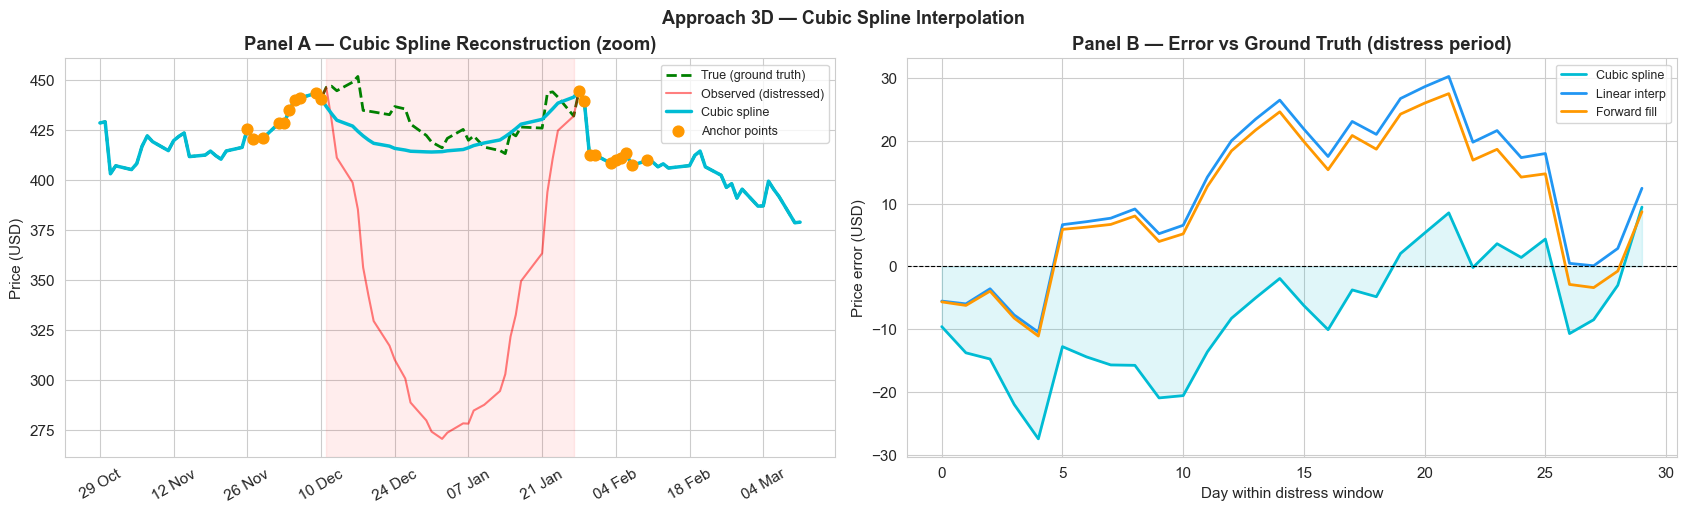

In [27]:
# Fill the distressed window with a smooth curve built from nearby clean points

N_ANCHORS = 10   # use 10 clean points on each side of the window

pre_idx  = list(range(DIST_START - N_ANCHORS, DIST_START))   # days before the gap
post_idx = list(range(DIST_END, DIST_END + N_ANCHORS))        # days after the gap

anchor_idx = np.array(pre_idx + post_idx)
anchor_x   = anchor_idx.astype(float)
anchor_y   = P['DIST_OBS'].iloc[anchor_idx].values

# Fit the spline to the anchor points, then evaluate it inside the missing window
cs     = CubicSpline(anchor_x, anchor_y, bc_type='natural')
fill_x = np.arange(DIST_START, DIST_END, dtype=float)
fill_y = cs(fill_x)

dist_spline = P['DIST_OBS'].copy()
dist_spline.iloc[DIST_START:DIST_END] = fill_y

# Plot the reconstructed path and compare its errors with simpler methods
z0, z1 = DIST_START - 30, DIST_END + 30

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

ax = axes[0]
ax.plot(dates[z0:z1], P['DIST_TRUE'].iloc[z0:z1], 'g--', lw=2,
        label='True (ground truth)')
ax.plot(dates[z0:z1], P['DIST_OBS'].iloc[z0:z1],  'r-',  lw=1.5, alpha=0.5,
        label='Observed (distressed)')
ax.plot(dates[z0:z1], dist_spline.iloc[z0:z1], color='#00BCD4', lw=2.5,
        label='Cubic spline')
ax.scatter(dates[anchor_idx], P['DIST_OBS'].iloc[anchor_idx],
           color='#FF9800', s=60, zorder=5, label='Anchor points')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
ax.set_title('Panel A — Cubic Spline Reconstruction (zoom)', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1]
true_d = P['DIST_TRUE'].iloc[DIST_START:DIST_END].values
err_sp = dist_spline.iloc[DIST_START:DIST_END].values - true_d
err_li = recon['Linear Interp'].iloc[DIST_START:DIST_END].values - true_d
err_ff = recon['Forward Fill'].iloc[DIST_START:DIST_END].values - true_d
days_d = np.arange(len(true_d))

ax.plot(days_d, err_sp, color='#00BCD4', lw=2,   label='Cubic spline')
ax.plot(days_d, err_li, color='#2196F3', lw=2,   label='Linear interp')
ax.plot(days_d, err_ff, color='#FF9800', lw=2,   label='Forward fill')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.fill_between(days_d, err_sp, alpha=0.12, color='#00BCD4')
ax.set_title('Panel B — Error vs Ground Truth (distress period)',
             fontweight='bold')
ax.set_ylabel('Price error (USD)')
ax.set_xlabel('Day within distress window')
ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle('Approach 3D — Cubic Spline Interpolation',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

recon['Cubic Spline'] = dist_spline

### How to Read the Approach 3D Graphs

This figure asks whether a smooth curve through nearby anchor points can stand in for the missing legacy prices.

### Panel A — Cubic Spline Reconstruction

**What it shows**

The spline reconstruction is plotted together with the true path, observed distressed path, and the anchor points used to fit the curve.

**Why we use it**

This panel helps you judge whether a smooth mathematical interpolation looks economically plausible.

**How to read it**

1. Look at the orange anchor points first; they tell you what information the spline is forced to pass through.
2. Then watch how the cyan spline bends through the missing window.
3. Compare that shape with the dashed true path.
4. Ask whether the spline is producing a believable smooth legacy path or simply imposing a neat curve.

### Panel B — Error vs Ground Truth

**What it shows**

This panel compares the spline's error with simpler benchmarks across the distressed days.

**Why we use it**

A pretty line in Panel A is not enough. We also want to know whether the spline actually reduces error versus simpler methods.

**How to read it**

1. The horizontal zero line means perfect reconstruction.
2. Lines above zero are overestimates; lines below zero are underestimates.
3. Smaller error magnitude is better.
4. Compare whether the spline stays closer to zero than forward fill and linear interpolation.

**Debugger tip**

If the spline looks smooth but still has large error, the problem is usually not smoothness. It is that the anchor points themselves come from economically inconsistent regimes.

## Interlude — The Earlier Static Proxy Method

> Before the dynamic method, it helps to understand the simpler proxy idea first.

The earlier proxy method makes **one main peer-choice decision at the start of the missing window** and then keeps that decision fixed for the whole window.

### What does "one correlation matrix and one cluster for the entire missing window" mean?

It means we do these steps **once**, right before the distressed period starts:

1. Take one clean historical lookback window from the **legacy regime**.
2. Compute **one correlation matrix** between DIST and all candidate peers.
3. Convert that matrix into distances and build **one clustering tree**.
4. Find the cluster that contains DIST.
5. Choose a fixed set of peers from that cluster.
6. Keep using those same peers for **every missing day** in the distressed window.

So the method is called **static** because the peer group is fixed. It does **not** re-check whether the best cluster changes from day to day.

### Beginner intuition

Imagine you are trying to estimate the missing sound of one instrument in an orchestra.
The static method listens to one rehearsal right before the performance, decides which instruments sound most similar, and then trusts that same small group for the entire missing section.

That can work well when relationships stay stable.
But it can struggle if market relationships drift during the distressed window.

### Static Proxy Workflow

| Step | What happens once at the start? | What stays fixed later? |
|------|--------------------------------|--------------------------|
| 1 | Pick one legacy lookback window | The starting evidence set |
| 2 | Build one correlation matrix | The similarity snapshot |
| 3 | Build one cluster tree | DIST's cluster membership rule |
| 4 | Choose DIST's peers | The peer basket |
| 5 | Predict each missing day with those peers | The chosen peer list stays the same |

### Why show this before the dynamic method?

Because the dynamic method is easier to understand once you see what it is changing.

- **Static proxy**: choose peers once and reuse them
- **Dynamic proxy**: re-check the correlations, clusters, and peer choice every missing day

The charts below show the earlier static method visually: one fixed correlation map, one fixed clustering tree, one fixed peer basket, and the resulting reconstruction.

In [34]:
# Visualise the earlier static proxy method: one correlation snapshot and one fixed peer basket

STATIC_LOOKBACK = 80
STATIC_CLUSTER_THR = 0.35
STATIC_MAX_PEERS = len(model_peer_cols)   # use the full basket
STATIC_MIN_PEERS = 2
# Use the full performance-ranked basket (all 25 best peers) rather than a fixed small set
static_proxy_candidates = model_peer_cols.copy()

# Build distress-window working series from observed prices
intro_dist_gap_neutral = prices_df['DIST_OBS'].copy()

intro_dist_log_ret = np.log(intro_dist_gap_neutral / intro_dist_gap_neutral.shift(1)).dropna()
intro_ret_work = ret_df.copy()
intro_ret_work['DIST'] = intro_dist_log_ret.values
intro_dist_recon = intro_dist_gap_neutral.copy()


In [33]:
model_peer_cols

['NOW',
 'CDNS',
 'APH',
 'NVDA',
 'AAPL',
 'CRWD',
 'ANET',
 'MPWR',
 'LRCX',
 'AVGO',
 'AMD',
 'WDC',
 'FFIV',
 'ADSK',
 'KLAC',
 'AMAT',
 'CRM',
 'PTC',
 'ADI',
 'ORCL',
 'INTU',
 'TER',
 'TEL',
 'ROP',
 'NXPI']

In [35]:

# Build one correlation matrix from the last clean window before distress starts
intro_ret_row = DIST_START - 1
intro_window_end = intro_ret_row
intro_window_start = max(0, intro_window_end - STATIC_LOOKBACK)
intro_window_df = intro_ret_work.iloc[intro_window_start:intro_window_end].copy()


In [36]:
# Explanation: how clustering works here, and why we use it
# -------------------------------------------------------------------
# Goal:
# We want a fixed peer basket for DIST before the distressed window.
# Clustering helps us group stocks that behaved similarly in the clean lookback window.

# 1) Measure similarity with correlation (higher correlation = more similar movement)
intro_corr = intro_window_df.corr()

# 2) Start with the standard correlation distance used earlier:
#    distance = (1 - corr) / 2
#    - corr = 1.0  -> distance = 0.0 (very similar)
#    - corr = 0.0  -> distance = 0.5
#    - corr = -1.0 -> distance = 1.0 (opposite moves)
intro_corr_dist = ((1 - intro_corr) / 2).clip(lower=0, upper=1)
np.fill_diagonal(intro_corr_dist.values, 0.0)

# 3) Add two extra ingredients to build a more creative weighted distance:
#    - volatility mismatch: do the two stocks swing by similar amounts?
#    - tracking-error distance: how noisy is the return gap between them?
intro_vol = intro_window_df.std()
intro_vol_diff = pd.DataFrame(0.0, index=intro_corr.index, columns=intro_corr.columns)
intro_tracking_dist = pd.DataFrame(0.0, index=intro_corr.index, columns=intro_corr.columns)

for stock_i in intro_corr.index:
    for stock_j in intro_corr.columns:
        intro_vol_diff.loc[stock_i, stock_j] = abs(intro_vol[stock_i] - intro_vol[stock_j])
        intro_tracking_dist.loc[stock_i, stock_j] = (
            intro_window_df[stock_i] - intro_window_df[stock_j]
        ).std()

max_vol_diff = intro_vol_diff.to_numpy().max()
if max_vol_diff > 0:
    intro_vol_diff = intro_vol_diff / max_vol_diff

max_tracking_dist = intro_tracking_dist.to_numpy().max()
if max_tracking_dist > 0:
    intro_tracking_dist = intro_tracking_dist / max_tracking_dist

# 4) Weighted distance for clustering:
#    - 60% correlation distance (main driver)
#    - 20% volatility mismatch
#    - 20% tracking-error distance
# Lower weighted distance means more similar behaviour overall.
intro_dist = (
    0.60 * intro_corr_dist
    + 0.20 * intro_vol_diff
    + 0.20 * intro_tracking_dist
).clip(lower=0, upper=1)
np.fill_diagonal(intro_dist.values, 0.0)  # each stock has zero distance to itself

# 5) Build a hierarchical clustering tree (dendrogram) from the weighted distance matrix
intro_stocks = intro_corr.columns.tolist()
intro_linkage = linkage(squareform(intro_dist.values), method='ward')

# 6) Cut the tree at STATIC_CLUSTER_THR to get cluster labels
intro_labels = fcluster(intro_linkage, t=STATIC_CLUSTER_THR, criterion='distance')

# 7) Find DIST's cluster members (excluding DIST itself)
intro_dist_cluster = intro_labels[intro_stocks.index('DIST')]
intro_same_cluster = [
    stock for stock, cluster_id in zip(intro_stocks, intro_labels)
    if cluster_id == intro_dist_cluster and stock != 'DIST'
]

# 8) Build a more intuitive peer score for ranking candidates.
#    We give the biggest weight to positive correlation, then add volatility
#    and tracking similarity so we prefer peers that also 'feel' similar.
intro_corr_component = intro_corr.loc['DIST'].drop('DIST').clip(lower=0.0)
intro_vol_similarity = 1.0 - intro_vol_diff.loc['DIST'].drop('DIST')
intro_tracking_similarity = 1.0 - intro_tracking_dist.loc['DIST'].drop('DIST')

intro_peer_score = (
    0.50 * intro_corr_component
    + 0.25 * intro_vol_similarity
    + 0.25 * intro_tracking_similarity
).sort_values(ascending=False)

intro_peer_diagnostics = pd.DataFrame({
    'corr_with_DIST': intro_corr.loc['DIST'].drop('DIST'),
    'vol_similarity': intro_vol_similarity,
    'tracking_similarity': intro_tracking_similarity,
    'weighted_peer_score': intro_peer_score,
}).sort_values('weighted_peer_score', ascending=False)

# 9) Peer selection rule:
#    - if DIST's cluster has enough names, use best weighted-score names from that cluster
#    - otherwise fallback to best weighted-score names overall
if len(intro_same_cluster) >= STATIC_MIN_PEERS:
    intro_peers = sorted(
        intro_same_cluster,
        key=lambda stock: intro_peer_score.loc[stock],
        reverse=True,
    )[:STATIC_MAX_PEERS]
    intro_selection_rule = 'same cluster + weighted peer score'
else:
    intro_peers = intro_peer_score.index[:STATIC_MAX_PEERS].tolist()
    intro_selection_rule = 'fallback weighted peer score'

intro_static_records = []
dist_col_idx = intro_ret_work.columns.get_loc('DIST')

print('Why cluster? To pick peers that moved most similarly to DIST in the clean legacy window.')
print('Weighted distance for clustering = 60% correlation distance + 20% volatility mismatch + 20% tracking-error distance')
print('Weighted peer score for ranking = 50% positive correlation + 25% volatility similarity + 25% tracking similarity')
print(f'DIST cluster id: {intro_dist_cluster}')
print(f'Stocks in DIST cluster: {intro_same_cluster}')
print('Top weighted peer diagnostics:')
print(intro_peer_diagnostics.head(5).round(3).to_string())
print(f'Selected peers: {intro_peers} ({intro_selection_rule})')



Why cluster? To pick peers that moved most similarly to DIST in the clean legacy window.
Weighted distance for clustering = 60% correlation distance + 20% volatility mismatch + 20% tracking-error distance
Weighted peer score for ranking = 50% positive correlation + 25% volatility similarity + 25% tracking similarity
DIST cluster id: 4
Stocks in DIST cluster: ['AAPL', 'FFIV', 'PTC', 'TEL', 'ROP']
Top weighted peer diagnostics:
      corr_with_DIST  vol_similarity  tracking_similarity  weighted_peer_score
TEL            0.514           0.972                0.695                0.674
AAPL           0.493           0.969                0.709                0.666
FFIV           0.477           0.929                0.667                0.638
ROP            0.455           0.927                0.711                0.637
APH            0.506           0.838                0.634                0.621
Selected peers: ['TEL', 'AAPL', 'FFIV', 'ROP', 'PTC'] (same cluster + weighted peer score)


### Optional Alternative Peer-Selection Frameworks: Simple, Weighted, and Advanced

The cell above keeps the current peer-selection logic.
This new section gives you a **second, optional framework** that you can run if you want to compare three different ideas for choosing peers.

The goal is to let you test three versions:

1. **Simple distance calculation**
2. **Weighted version**
3. **Proposed version**

### Why have multiple versions?

Peer selection is one of the most important parts of the reconstruction problem.
If we choose weak peers, even a good regression model will struggle.
So it is useful to compare different ways of deciding which stocks are the best neighbours for DIST.

## Version 1 — Simple distance calculation

This is the most basic method.
It uses only correlation and converts it into a clustering distance:

$$
d_{ij}^{\text{simple}} = \frac{1 - \rho_{ij}}{2}
$$

Then we rank peers mainly by correlation with DIST.

### Beginner view

- high correlation = stocks move similarly
- low distance = stocks are closer together
- closest names are natural peer candidates

### Scientific view

This is a clean baseline, but it assumes linear co-movement is enough to define similarity.
It ignores differences in volatility, sector identity, downside behaviour, and tracking stability.

## Version 2 — Weighted version

This is the richer version used in the current cell above.
It still starts from correlation distance, but adds extra information such as:

- volatility mismatch
- tracking-error distance

So the weighted distance becomes a blend of multiple similarity ideas rather than correlation alone.

### Beginner view

Two stocks are better peers if they:

- move in the same direction often
- swing by similar amounts
- do not drift too far apart in daily return behaviour

### Scientific view

This version tries to improve robustness by using a composite distance metric, not just a single statistic.

## Version 3 — Proposed version

This is the more selective idea proposed here.
It adds three extra constraints or scoring improvements:

1. **Hard minimum-correlation filter**
A stock must have at least some minimum correlation with DIST before it can even be considered.
This stops weakly related names from winning only because of a secondary metric.

2. **Sector bonus / penalty**
A stock in the same sector as DIST gets a small bonus.
A stock from another sector gets a penalty.
This adds simple economic knowledge to the selection process.

3. **Downside-correlation term**
We measure how similarly a peer moves on bad days for DIST.
This is useful because distressed reconstruction often cares most about behaviour during negative or stressed periods, not just average daily co-movement.

### Proposed scoring intuition

The proposed idea is:

- first remove clearly weak peers
- then reward stocks that are economically similar
- then reward stocks that behave similarly especially when DIST is falling

That usually makes the peer choice more realistic, not just statistically convenient.

## How to use the cell below

The code cell below lets you choose:

- `'simple'`
- `'weighted'`
- `'proposed'`

It will then:

- build the appropriate distance matrix
- form clusters
- score candidate peers
- choose the final peer basket
- overwrite the working peer-selection variables used by the downstream static reconstruction

So if you run that cell and then rerun the static reconstruction cells below, you can compare the three versions directly.

## Practical expectation

- **Simple** is best as a teaching baseline
- **Weighted** is a stronger statistical version
- **Proposed** is the most economically informed version in this section

The best method is not guaranteed in advance. The point is to test which peer-selection logic gives the most stable and believable reconstruction.

In [37]:
# Optional peer-selection switcher: simple vs weighted vs proposed

STATIC_PEER_VERSION = 'proposed'  # choose: 'simple', 'weighted', 'proposed'
MIN_CORR_FOR_PEER = 0.20          # lower threshold — all basket peers are already quality-screened
SECTOR_BONUS = 0.10
SECTOR_PENALTY = 0.10
PROPOSED_SCORE_WEIGHTS = {
    'corr': 0.40,
    'vol': 0.20,
    'tracking': 0.15,
    'downside': 0.25,
}
PROPOSED_DISTANCE_WEIGHTS = {
    'corr': 0.45,
    'vol': 0.15,
    'tracking': 0.15,
    'downside': 0.25,
}

# Build sector_map from peers_df so it covers the real tickers in intro_window_df
sector_map = {row['ticker']: row['sector'] for _, row in peers_df.iterrows()}
sector_map['DIST'] = peers_df.loc[peers_df['ticker'] == TARGET_TICKER, 'sector'].iloc[0]

def build_downside_similarity(ret_window, target_col='DIST'):
    downside_mask = ret_window[target_col] < 0
    downside_similarity = pd.Series(0.0, index=ret_window.columns, dtype=float)
    target_series = ret_window.loc[downside_mask, target_col]

    for stock in ret_window.columns:
        if stock == target_col:
            downside_similarity.loc[stock] = 1.0
            continue
        pair_df = pd.concat([target_series, ret_window.loc[downside_mask, stock]], axis=1).dropna()
        if len(pair_df) >= 5:
            corr_val = pair_df.iloc[:, 0].corr(pair_df.iloc[:, 1])
            downside_similarity.loc[stock] = np.clip((corr_val + 1) / 2, 0, 1) if pd.notna(corr_val) else 0.0
        else:
            downside_similarity.loc[stock] = 0.0

    return downside_similarity

def build_peer_method(
    ret_window,
    method_name,
    cluster_thr=STATIC_CLUSTER_THR,
    max_peers=STATIC_MAX_PEERS,
    min_peers=STATIC_MIN_PEERS,
    min_corr_for_peer=MIN_CORR_FOR_PEER,
    sector_bonus=SECTOR_BONUS,
    sector_penalty=SECTOR_PENALTY,
    proposed_score_weights=None,
    proposed_distance_weights=None,
):
    # --- shared computations ---
    _target_sector = sector_map.get('DIST', '')
    corr_mat = ret_window.corr()
    stocks = corr_mat.columns.tolist()

    corr_dist = ((1 - corr_mat) / 2).clip(lower=0, upper=1)
    np.fill_diagonal(corr_dist.values, 0.0)

    vol_series = ret_window.std()
    vol_diff = pd.DataFrame(0.0, index=stocks, columns=stocks)
    tracking_dist_m = pd.DataFrame(0.0, index=stocks, columns=stocks)
    for stock_i in stocks:
        for stock_j in stocks:
            vol_diff.loc[stock_i, stock_j] = abs(vol_series[stock_i] - vol_series[stock_j])
            tracking_dist_m.loc[stock_i, stock_j] = (ret_window[stock_i] - ret_window[stock_j]).std()

    max_vol = vol_diff.to_numpy().max()
    if max_vol > 0:
        vol_diff = vol_diff / max_vol

    max_tracking = tracking_dist_m.to_numpy().max()
    if max_tracking > 0:
        tracking_dist_m = tracking_dist_m / max_tracking

    downside_similarity = build_downside_similarity(ret_window, target_col='DIST')
    downside_dist = pd.DataFrame(1.0, index=stocks, columns=stocks)
    for stock_i in stocks:
        for stock_j in stocks:
            downside_dist.loc[stock_i, stock_j] = abs(
                downside_similarity.loc[stock_i] - downside_similarity.loc[stock_j]
            )

    # --- method-specific scoring ---
    if method_name == 'simple':
        dist_mat = corr_dist.copy()
        peer_score = corr_mat.loc['DIST'].drop('DIST').sort_values(ascending=False)
        selection_rule = 'simple correlation distance'
        eligible_names = peer_score.index.tolist()

    elif method_name == 'weighted':
        dist_mat = (
            0.60 * corr_dist
            + 0.20 * vol_diff
            + 0.20 * tracking_dist_m
        ).clip(lower=0, upper=1)

        corr_component = corr_mat.loc['DIST'].drop('DIST').clip(lower=0.0)
        vol_similarity = 1.0 - vol_diff.loc['DIST'].drop('DIST')
        tracking_similarity = 1.0 - tracking_dist_m.loc['DIST'].drop('DIST')
        peer_score = (
            0.50 * corr_component
            + 0.25 * vol_similarity
            + 0.25 * tracking_similarity
        ).sort_values(ascending=False)
        selection_rule = 'weighted distance + weighted peer score'
        eligible_names = peer_score.index.tolist()

    elif method_name == 'proposed':
        score_w = proposed_score_weights or PROPOSED_SCORE_WEIGHTS
        dist_w = proposed_distance_weights or PROPOSED_DISTANCE_WEIGHTS

        dist_mat = (
            dist_w['corr'] * corr_dist
            + dist_w['vol'] * vol_diff
            + dist_w['tracking'] * tracking_dist_m
            + dist_w['downside'] * downside_dist
        ).clip(lower=0, upper=1)

        raw_corr = corr_mat.loc['DIST'].drop('DIST')
        corr_component = raw_corr.clip(lower=0.0)
        vol_similarity = 1.0 - vol_diff.loc['DIST'].drop('DIST')
        tracking_similarity = 1.0 - tracking_dist_m.loc['DIST'].drop('DIST')
        downside_component = downside_similarity.drop('DIST')

        sector_adjustment = pd.Series(
            {stock: sector_bonus if sector_map.get(stock) == _target_sector else -sector_penalty
             for stock in raw_corr.index}
        )

        base_score = (
            score_w['corr'] * corr_component
            + score_w['vol'] * vol_similarity
            + score_w['tracking'] * tracking_similarity
            + score_w['downside'] * downside_component
        ) + sector_adjustment

        eligible_mask = raw_corr >= min_corr_for_peer
        peer_score = base_score[eligible_mask].sort_values(ascending=False)
        selection_rule = 'minimum correlation + sector-aware + downside-aware score'
        eligible_names = peer_score.index.tolist()

    else:
        raise ValueError("STATIC_PEER_VERSION must be 'simple', 'weighted', or 'proposed'")

    np.fill_diagonal(dist_mat.values, 0.0)
    linkage_mat = linkage(squareform(dist_mat.values), method='ward')
    labels = fcluster(linkage_mat, t=cluster_thr, criterion='distance')
    dist_cluster = labels[stocks.index('DIST')]
    same_cluster = [
        stock for stock, cluster_id in zip(stocks, labels)
        if cluster_id == dist_cluster and stock != 'DIST' and stock in eligible_names
    ]

    if len(same_cluster) >= min_peers:
        peers = sorted(
            same_cluster,
            key=lambda stock: peer_score.loc[stock],
            reverse=True,
        )[:max_peers]
        final_rule = f'{selection_rule} | cluster-first'
    else:
        peers = peer_score.index[:max_peers].tolist()
        final_rule = f'{selection_rule} | fallback global score'

    diagnostics = pd.DataFrame(index=corr_mat.loc['DIST'].drop('DIST').index)
    diagnostics['corr_with_DIST'] = corr_mat.loc['DIST'].drop('DIST')
    diagnostics['vol_similarity'] = (1.0 - vol_diff.loc['DIST'].drop('DIST'))
    diagnostics['tracking_similarity'] = (1.0 - tracking_dist_m.loc['DIST'].drop('DIST'))
    diagnostics['downside_similarity'] = downside_similarity.drop('DIST')
    diagnostics['same_sector'] = [sector_map.get(stock) == _target_sector for stock in diagnostics.index]
    if method_name == 'proposed':
        diagnostics['passes_min_corr'] = diagnostics['corr_with_DIST'] >= min_corr_for_peer
    diagnostics['peer_score'] = 0.0
    if len(peer_score) > 0:
        diagnostics.loc[peer_score.index, 'peer_score'] = peer_score.values
    diagnostics = diagnostics.sort_values('peer_score', ascending=False)

    return {
        'corr': corr_mat,
        'dist': dist_mat,
        'linkage': linkage_mat,
        'labels': labels,
        'stocks': stocks,
        'dist_cluster': dist_cluster,
        'same_cluster': same_cluster,
        'peer_score': peer_score,
        'diagnostics': diagnostics,
        'peers': peers,
        'selection_rule': final_rule,
    }

peer_method_results = {
    'simple': build_peer_method(intro_window_df, 'simple'),
    'weighted': build_peer_method(intro_window_df, 'weighted'),
    'proposed': build_peer_method(intro_window_df, 'proposed'),
}

chosen_peer_method = peer_method_results[STATIC_PEER_VERSION]

# Overwrite the working variables so the static reconstruction below can use the chosen version
intro_corr = chosen_peer_method['corr']
intro_dist = chosen_peer_method['dist']
intro_linkage = chosen_peer_method['linkage']
intro_labels = chosen_peer_method['labels']
intro_stocks = chosen_peer_method['stocks']
intro_dist_cluster = chosen_peer_method['dist_cluster']
intro_same_cluster = chosen_peer_method['same_cluster']
intro_peers = chosen_peer_method['peers']
intro_selection_rule = chosen_peer_method['selection_rule']

print(f'Chosen peer-selection version: {STATIC_PEER_VERSION}')
print(f'Candidate pool size: {len(static_proxy_candidates)} peers')
print(f'Selected peers ({len(intro_peers)}): {intro_peers}')
print(f'Selection rule: {intro_selection_rule}')
print('\nTop diagnostics for chosen version:')
print(chosen_peer_method['diagnostics'].head(10).round(3).to_string())

comparison_rows = []
for method_name, result in peer_method_results.items():
    comparison_rows.append({
        'method': method_name,
        'n_selected': len(result['peers']),
        'same_cluster_size': len(result['same_cluster']),
        'selected_peers': ', '.join(result['peers'][:8]) + ('...' if len(result['peers']) > 8 else ''),
        'rule': result['selection_rule'],
    })

peer_method_compare_df = pd.DataFrame(comparison_rows)
print('\nPeer-selection comparison across the three versions:')
print(peer_method_compare_df.to_string(index=False))


Chosen peer-selection version: proposed
Candidate pool size: 25 peers
Selected peers (6): ['TEL', 'AAPL', 'FFIV', 'ROP', 'CDNS', 'PTC']
Selection rule: minimum correlation + sector-aware + downside-aware score | cluster-first

Top diagnostics for chosen version:
      corr_with_DIST  vol_similarity  tracking_similarity  downside_similarity  same_sector  passes_min_corr  peer_score
TEL            0.514           0.972                0.695                0.805         True             True       0.805
AAPL           0.493           0.969                0.709                0.761         True             True       0.787
FFIV           0.477           0.929                0.667                0.806         True             True       0.778
ROP            0.455           0.927                0.711                0.795         True             True       0.773
NOW            0.484           0.841                0.629                0.726         True             True       0.738
APH        

### Comparing the Three Peer-Selection Versions and Tuning the Proposed One

The next cell does three things:

1. draws a small graph comparing peer scores across the three versions
2. runs the full static reconstruction for each version and compares RMSE side by side
3. tunes the proposed version over several weight settings and minimum-correlation thresholds

### Why this matters

A peer-selection rule should not be judged only by how intuitive it sounds.
It should also be judged by whether it improves the final reconstruction error.

So this comparison cell connects:

- peer scores
- chosen peer basket
- final static-reconstruction RMSE

That makes the section more scientific, because we can test whether a more advanced peer-selection rule actually improves the reconstruction.

Static reconstruction comparison across versions:
              version                  selected_peers    RMSE     MAE  Return Corr
             weighted       TEL, AAPL, FFIV, ROP, PTC  8.4422  7.2831       0.7674
proposed (best tuned)      TEL, AAPL, FFIV, ROP, CDNS  9.3114  7.9701       0.7807
   proposed (default) TEL, AAPL, FFIV, ROP, CDNS, PTC  9.9726  8.6424       0.7915
               simple                      MPWR, AAPL 20.3134 17.1524       0.7351

Top proposed tuning settings:
weight_profile  min_corr  sector_penalty  min_peer_count             selected_peers   RMSE    MAE  Return Corr
      balanced      0.35            0.10               1 TEL, AAPL, FFIV, ROP, CDNS 9.3114 7.9701       0.7807
      balanced      0.35            0.10               2 TEL, AAPL, FFIV, ROP, CDNS 9.3114 7.9701       0.7807
      balanced      0.35            0.10               3 TEL, AAPL, FFIV, ROP, CDNS 9.3114 7.9701       0.7807
      balanced      0.35            0.20               1 TEL

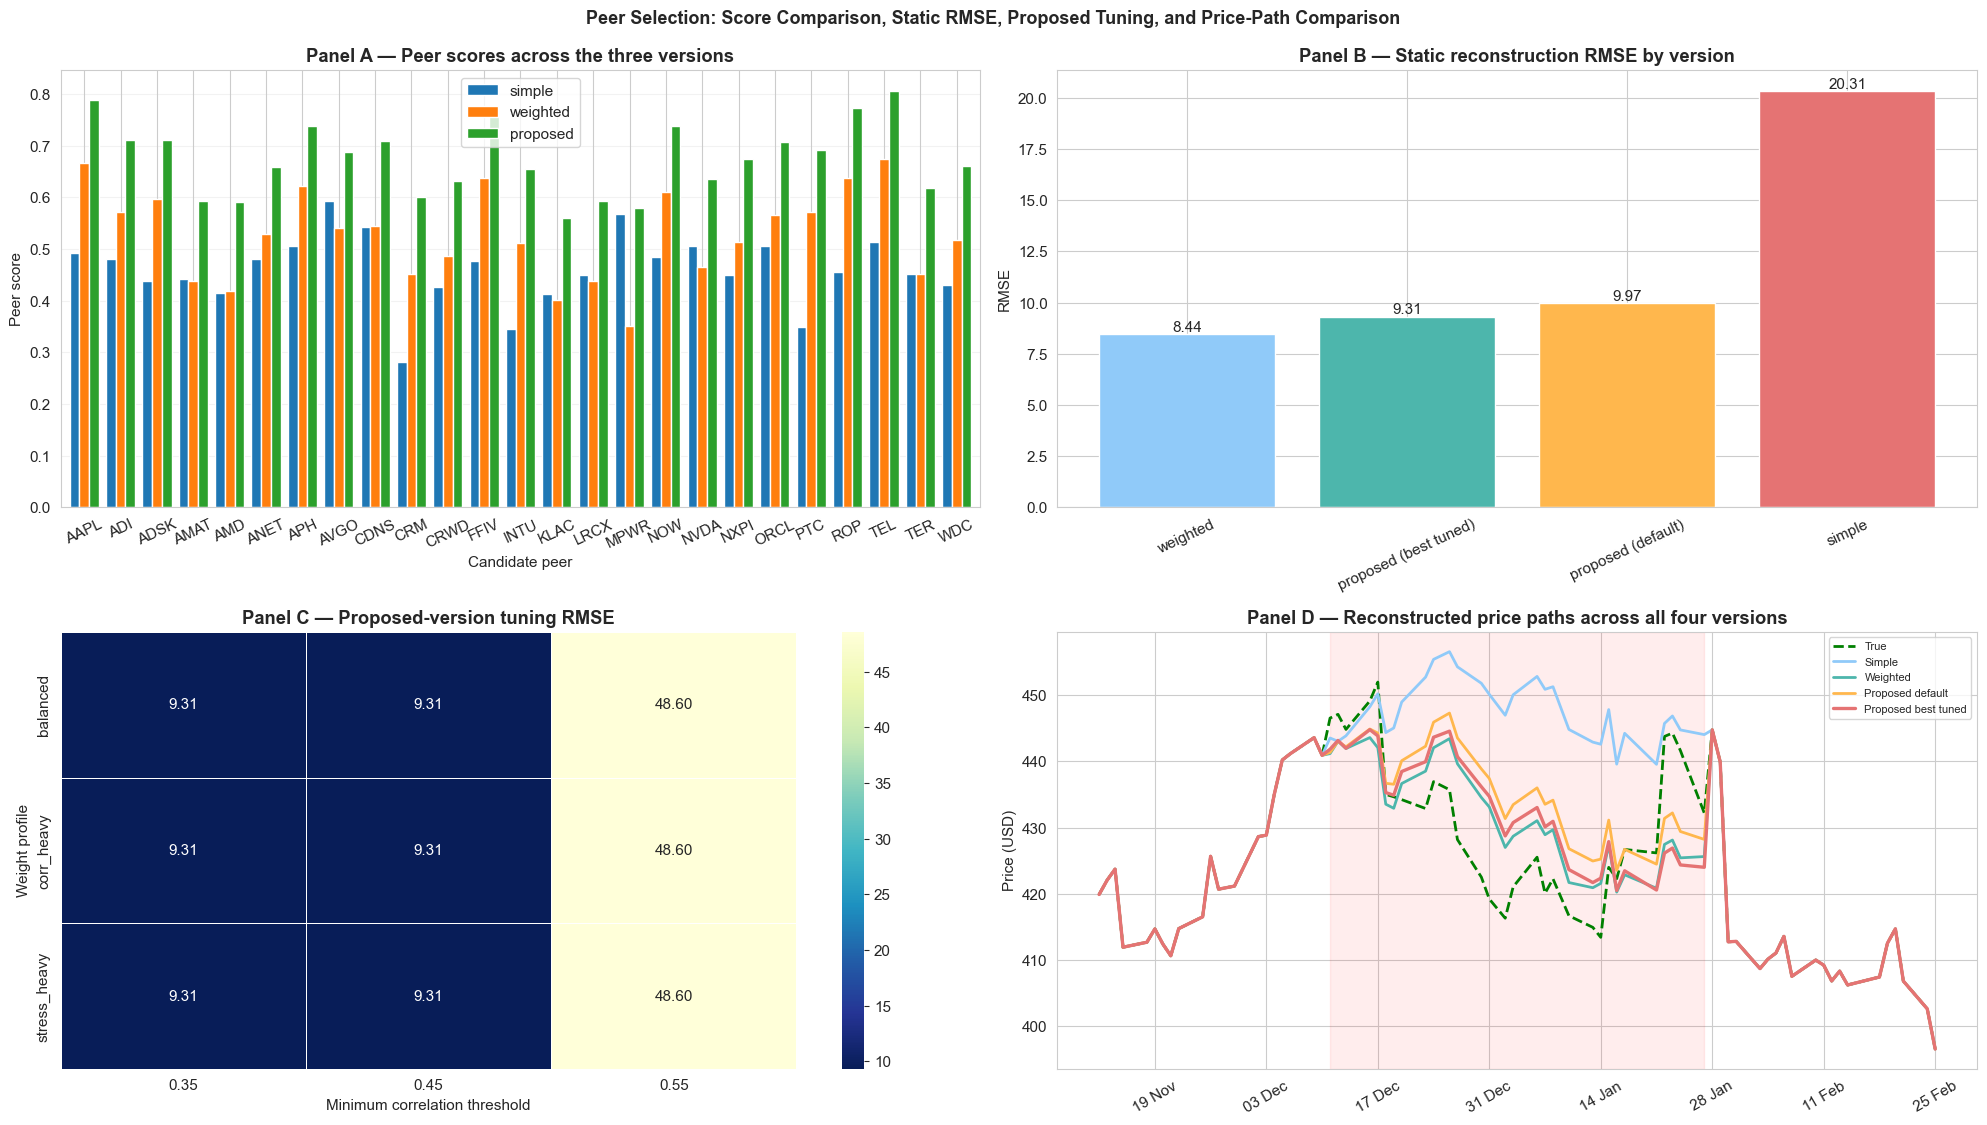

In [38]:
# Compare simple, weighted, and proposed peer selection, then tune the proposed version

AUTO_USE_BEST_PROPOSED_FOR_STATIC = True

def run_static_reconstruction_with_peers(peers):
    # Rebuild the static proxy path using one fixed peer basket
    local_ret_work = intro_ret_work.copy()
    local_dist_recon = intro_dist_gap_neutral.copy()
    local_records = []
    local_dist_col_idx = local_ret_work.columns.get_loc('DIST')

    for current_idx in range(DIST_START, DIST_END):
        ret_row = current_idx - 1
        window_end = ret_row
        window_start = max(0, window_end - STATIC_LOOKBACK)
        window_df = local_ret_work.iloc[window_start:window_end].copy()

        train_df = window_df[['DIST'] + peers].dropna()
        X_train = train_df[peers].values
        y_train = train_df['DIST'].values
        reg = LinearRegression().fit(X_train, y_train)

        peer_today = ret_df.iloc[ret_row][peers]
        pred_log_ret = reg.predict(peer_today.to_frame().T)[0]
        true_log_ret = np.log(P['DIST_TRUE'].iloc[current_idx] / P['DIST_TRUE'].iloc[current_idx - 1])

        local_ret_work.iloc[ret_row, local_dist_col_idx] = pred_log_ret
        local_dist_recon.iloc[current_idx] = local_dist_recon.iloc[current_idx - 1] * np.exp(pred_log_ret)

        local_records.append({
            'date': dates[current_idx],
            'pred_log_ret': pred_log_ret,
            'true_log_ret': true_log_ret,
            'model_r2': reg.score(X_train, y_train),
        })

    local_daily_df = pd.DataFrame(local_records)
    recon_prices = local_dist_recon.iloc[DIST_START:DIST_END].values
    true_prices = P['DIST_TRUE'].iloc[DIST_START:DIST_END].values

    return {
        'series': local_dist_recon,
        'daily_df': local_daily_df,
        'rmse': np.sqrt(mean_squared_error(true_prices, recon_prices)),
        'mae': np.mean(np.abs(recon_prices - true_prices)),
        'ret_corr': np.corrcoef(local_daily_df['pred_log_ret'], local_daily_df['true_log_ret'])[0, 1],
    }

# 1) Run the full static reconstruction for the three versions
static_version_eval = {}
for method_name, result in peer_method_results.items():
    static_version_eval[method_name] = run_static_reconstruction_with_peers(result['peers'])

# 2) Tune the proposed version across several thresholds, weight sets, sector penalties, and minimum peer counts
proposed_weight_grid = [
    {
        'name': 'balanced',
        'score': {'corr': 0.40, 'vol': 0.20, 'tracking': 0.15, 'downside': 0.25},
        'dist': {'corr': 0.45, 'vol': 0.15, 'tracking': 0.15, 'downside': 0.25},
    },
    {
        'name': 'corr_heavy',
        'score': {'corr': 0.55, 'vol': 0.15, 'tracking': 0.10, 'downside': 0.20},
        'dist': {'corr': 0.60, 'vol': 0.15, 'tracking': 0.10, 'downside': 0.15},
    },
    {
        'name': 'stress_heavy',
        'score': {'corr': 0.35, 'vol': 0.15, 'tracking': 0.10, 'downside': 0.40},
        'dist': {'corr': 0.35, 'vol': 0.15, 'tracking': 0.10, 'downside': 0.40},
    },
]
proposed_min_corr_grid = [0.35, 0.45, 0.55]
sector_penalty_grid = [0.10, 0.20, 0.35]
min_peer_count_grid = [1, 2, 3]

tuning_rows = []
best_tuned_result = None

for weight_spec in proposed_weight_grid:
    for min_corr_val in proposed_min_corr_grid:
        for sector_penalty_val in sector_penalty_grid:
            for min_peer_count_val in min_peer_count_grid:
                tuned_result = build_peer_method(
                    intro_window_df,
                    'proposed',
                    min_corr_for_peer=min_corr_val,
                    sector_penalty=sector_penalty_val,
                    min_peers=min_peer_count_val,
                    proposed_score_weights=weight_spec['score'],
                    proposed_distance_weights=weight_spec['dist'],
                )
                if len(tuned_result['peers']) == 0:
                    continue

                tuned_eval = run_static_reconstruction_with_peers(tuned_result['peers'])
                tuning_row = {
                    'weight_profile': weight_spec['name'],
                    'min_corr': min_corr_val,
                    'sector_penalty': sector_penalty_val,
                    'min_peer_count': min_peer_count_val,
                    'selected_peers': ', '.join(tuned_result['peers']),
                    'RMSE': tuned_eval['rmse'],
                    'MAE': tuned_eval['mae'],
                    'Return Corr': tuned_eval['ret_corr'],
                }
                tuning_rows.append(tuning_row)

                if best_tuned_result is None or tuned_eval['rmse'] < best_tuned_result['eval']['rmse']:
                    best_tuned_result = {
                        'method_result': tuned_result,
                        'eval': tuned_eval,
                        'weight_profile': weight_spec['name'],
                        'min_corr': min_corr_val,
                        'sector_penalty': sector_penalty_val,
                        'min_peer_count': min_peer_count_val,
                    }

tuning_df = pd.DataFrame(tuning_rows).sort_values('RMSE').reset_index(drop=True)

comparison_summary_df = pd.DataFrame([
    {
        'version': 'simple',
        'selected_peers': ', '.join(peer_method_results['simple']['peers']),
        'RMSE': static_version_eval['simple']['rmse'],
        'MAE': static_version_eval['simple']['mae'],
        'Return Corr': static_version_eval['simple']['ret_corr'],
    },
    {
        'version': 'weighted',
        'selected_peers': ', '.join(peer_method_results['weighted']['peers']),
        'RMSE': static_version_eval['weighted']['rmse'],
        'MAE': static_version_eval['weighted']['mae'],
        'Return Corr': static_version_eval['weighted']['ret_corr'],
    },
    {
        'version': 'proposed (default)',
        'selected_peers': ', '.join(peer_method_results['proposed']['peers']),
        'RMSE': static_version_eval['proposed']['rmse'],
        'MAE': static_version_eval['proposed']['mae'],
        'Return Corr': static_version_eval['proposed']['ret_corr'],
    },
    {
        'version': 'proposed (best tuned)',
        'selected_peers': ', '.join(best_tuned_result['method_result']['peers']),
        'RMSE': best_tuned_result['eval']['rmse'],
        'MAE': best_tuned_result['eval']['mae'],
        'Return Corr': best_tuned_result['eval']['ret_corr'],
    },
]).sort_values('RMSE').reset_index(drop=True)

print('Static reconstruction comparison across versions:')
print(comparison_summary_df.round(4).to_string(index=False))
print('\nTop proposed tuning settings:')
print(tuning_df.head(8).round(4).to_string(index=False))
print('\nBest tuned proposed configuration:')
print(f"weight profile = {best_tuned_result['weight_profile']}")
print(f"minimum correlation = {best_tuned_result['min_corr']}")
print(f"sector penalty = {best_tuned_result['sector_penalty']}")
print(f"minimum peer count = {best_tuned_result['min_peer_count']}")
print(f"selected peers = {best_tuned_result['method_result']['peers']}")

fig, axes = plt.subplots(2, 2, figsize=(20, 11))

# Panel A: peer-score comparison across versions
ax = axes[0, 0]
score_compare = pd.DataFrame({
    'simple': peer_method_results['simple']['diagnostics']['peer_score'],
    'weighted': peer_method_results['weighted']['diagnostics']['peer_score'],
    'proposed': peer_method_results['proposed']['diagnostics']['peer_score'],
}).fillna(0.0)
score_compare.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Panel A — Peer scores across the three versions', fontweight='bold')
ax.set_ylabel('Peer score')
ax.set_xlabel('Candidate peer')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.25)

# Panel B: RMSE comparison for full static reconstruction
ax = axes[0, 1]
rmse_plot_df = comparison_summary_df.set_index('version').loc[comparison_summary_df['version']]
ax.bar(rmse_plot_df.index, rmse_plot_df['RMSE'], color=['#90CAF9', '#4DB6AC', '#FFB74D', '#E57373'])
ax.set_title('Panel B — Static reconstruction RMSE by version', fontweight='bold')
ax.set_ylabel('RMSE')
ax.tick_params(axis='x', rotation=25)
for idx, val in enumerate(rmse_plot_df['RMSE']):
    ax.text(idx, val, f'{val:.2f}', ha='center', va='bottom')

# Panel C: tuning heatmap for the proposed version
ax = axes[1, 0]
tuning_pivot = tuning_df.pivot_table(index='weight_profile', columns='min_corr', values='RMSE', aggfunc='min')
sns.heatmap(tuning_pivot, annot=True, fmt='.2f', cmap='YlGnBu_r', ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('Panel C — Proposed-version tuning RMSE', fontweight='bold')
ax.set_xlabel('Minimum correlation threshold')
ax.set_ylabel('Weight profile')

# Panel D: compare reconstructed price paths visually
ax = axes[1, 1]
plot_start, plot_end = DIST_START - 20, DIST_END + 20
zoom_dates = dates[plot_start:plot_end]
ax.plot(zoom_dates, P['DIST_TRUE'].iloc[plot_start:plot_end], 'g--', lw=2, label='True')
ax.plot(zoom_dates, static_version_eval['simple']['series'].iloc[plot_start:plot_end], color='#90CAF9', lw=2, label='Simple')
ax.plot(zoom_dates, static_version_eval['weighted']['series'].iloc[plot_start:plot_end], color='#4DB6AC', lw=2, label='Weighted')
ax.plot(zoom_dates, static_version_eval['proposed']['series'].iloc[plot_start:plot_end], color='#FFB74D', lw=2, label='Proposed default')
ax.plot(zoom_dates, best_tuned_result['eval']['series'].iloc[plot_start:plot_end], color='#E57373', lw=2.4, label='Proposed best tuned')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
ax.set_title('Panel D — Reconstructed price paths across all four versions', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.suptitle('Peer Selection: Score Comparison, Static RMSE, Proposed Tuning, and Price-Path Comparison', fontweight='bold', fontsize=13, y=1.02)
plt.show()

# Save the best tuned result for optional downstream use
best_proposed_peer_method = best_tuned_result['method_result']
best_proposed_static_eval = best_tuned_result['eval']
best_proposed_tuning_config = {
    'weight_profile': best_tuned_result['weight_profile'],
    'min_corr': best_tuned_result['min_corr'],
    'sector_penalty': best_tuned_result['sector_penalty'],
    'min_peer_count': best_tuned_result['min_peer_count'],
}

In [39]:
# Static proxy reconstruction
# -----------------------------------------------------------
# Candidate pool: all 25 performance-ranked basket peers (static_proxy_candidates).
# Peer selection: cluster + score using the chosen peer-selection version.
# The tuning cell above searched the full candidate pool across weights,
# min-correlation, and min-peer-count grids to find the best subset.
# AUTO_USE_BEST_PROPOSED_FOR_STATIC=True applies that best configuration here.

from sklearn.linear_model import LinearRegression

# Select active peer basket
if (
    globals().get('AUTO_USE_BEST_PROPOSED_FOR_STATIC', False)
    and 'best_proposed_peer_method' in globals()
    and STATIC_PEER_VERSION == 'proposed'
    and len(best_proposed_peer_method.get('peers', [])) > 0
):
    active_intro_peers = best_proposed_peer_method['peers']
    active_intro_selection_rule = (
        'best tuned proposed peer method (from full basket) | '
        f"profile={best_proposed_tuning_config['weight_profile']}, "
        f"min_corr={best_proposed_tuning_config['min_corr']}, "
        f"sector_penalty={best_proposed_tuning_config['sector_penalty']}, "
        f"min_peer_count={best_proposed_tuning_config['min_peer_count']}"
    )
else:
    active_intro_peers = intro_peers
    active_intro_selection_rule = intro_selection_rule

print(f'Candidate pool: {len(static_proxy_candidates)} basket peers')
print(f'Active peer basket for reconstruction: {len(active_intro_peers)} peers')
print(f'Peers: {active_intro_peers}')
print(f'Active selection rule: {active_intro_selection_rule}')

# Rebuild working series from scratch
intro_dist_gap_neutral = prices_df['DIST_OBS'].copy()
intro_dist_log_ret     = np.log(intro_dist_gap_neutral / intro_dist_gap_neutral.shift(1)).dropna()
intro_ret_work         = ret_df.copy()
intro_ret_work['DIST'] = intro_dist_log_ret.values
intro_dist_recon       = intro_dist_gap_neutral.copy()

intro_static_records = []
dist_col_idx = intro_ret_work.columns.get_loc('DIST')

for current_idx in range(DIST_START, DIST_END):
    ret_row      = current_idx - 1
    window_end   = ret_row
    window_start = max(0, window_end - STATIC_LOOKBACK)
    window_df    = intro_ret_work.iloc[window_start:window_end].copy()

    available_peers = [p for p in active_intro_peers if p in window_df.columns]
    train_df = window_df[['DIST'] + available_peers].dropna()
    X_train  = train_df[available_peers].values
    y_train  = train_df['DIST'].values

    reg = LinearRegression().fit(X_train, y_train)
    r2  = reg.score(X_train, y_train)

    peer_today   = ret_df.iloc[ret_row][available_peers]
    pred_log_ret = reg.predict(peer_today.to_frame().T)[0]
    true_log_ret = np.log(prices_df['DIST_TRUE'].iloc[current_idx] / prices_df['DIST_TRUE'].iloc[current_idx - 1])

    intro_ret_work.iloc[ret_row, dist_col_idx] = pred_log_ret
    intro_dist_recon.iloc[current_idx] = intro_dist_recon.iloc[current_idx - 1] * np.exp(pred_log_ret)

    intro_static_records.append({
        'date':         dates[current_idx],
        'n_peers_used': len(available_peers),
        'pred_log_ret': pred_log_ret,
        'true_log_ret': true_log_ret,
        'model_r2':     r2,
    })

static_proxy_df = pd.DataFrame(intro_static_records)
recon_prices = intro_dist_recon.iloc[DIST_START:DIST_END].values
true_prices  = prices_df['DIST_TRUE'].iloc[DIST_START:DIST_END].values

print(f'\nReconstruction complete: {len(static_proxy_df)} days')
print(f'Mean model R²:      {static_proxy_df["model_r2"].mean():.4f}')
print(f'Return correlation: {static_proxy_df["pred_log_ret"].corr(static_proxy_df["true_log_ret"]):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(true_prices, recon_prices)):.4f}')
print(f'MAE:  {np.mean(np.abs(recon_prices - true_prices)):.4f}')


Candidate pool: 25 basket peers
Active peer basket for reconstruction: 5 peers
Peers: ['TEL', 'AAPL', 'FFIV', 'ROP', 'CDNS']
Active selection rule: best tuned proposed peer method (from full basket) | profile=balanced, min_corr=0.35, sector_penalty=0.1, min_peer_count=1

Reconstruction complete: 30 days
Mean model R²:      0.4934
Return correlation: 0.7807
RMSE: 9.3114
MAE:  7.9701


### Challenger Model Idea for Beginners

In this cell, the main model is `LinearRegression()`.
That is the simplest standard linear model, so it is a good **baseline**.

A baseline means: start with the simplest reasonable method first, then compare other models against it.

### What `LinearRegression()` is doing here

The model is trying to learn a rule like this:

$$
\text{DIST return today} \approx \text{constant} + \text{effect of Peer 1} + \text{effect of Peer 2} + \text{effect of Peer 3}
$$

In plain English:

- if the selected peers move today
- how much would DIST usually move with them?

So the model uses peer returns as inputs and predicts the missing DIST return as output.

### Why is `LinearRegression()` a good starting point?

Because it is:

- simple
- fast
- easy to interpret
- a good reference point for comparison

### What is a challenger model?

A **challenger model** is just another model we test against the baseline.

The question is:

> can another model make more stable or more accurate predictions than plain `LinearRegression()`?

### Best challenger here: `Ridge`

The first challenger to try is usually `Ridge`.

Why? Because the peer returns are often similar to each other.
When inputs are similar or overlapping, plain linear regression can become unstable. That means the fitted coefficients can jump around more than we want.

`Ridge` keeps the same basic linear idea but adds a small penalty that stops the model from relying too heavily on noisy or overlapping inputs.

### Beginner intuition

Think of it like this:

- `LinearRegression()` says: use the peer information as freely as possible
- `Ridge` says: use the same peer information, but be a bit more careful and less aggressive

So `Ridge` often gives smoother and more stable predictions.

### Why this matters in this notebook

This model is used again and again inside a rolling reconstruction loop.
That means even small prediction errors can build up over time into a larger price-path error.

So if `Ridge` makes each daily prediction a little more stable, the final reconstructed series may also improve.

### If we switch from `LinearRegression()` to `Ridge`, what changes?

Only the regression model changes.
These parts stay the same:

- same selected peers
- same rolling window
- same target return
- same reconstruction loop
- same evaluation metrics

### What the code change would look like

```python
from sklearn.linear_model import Ridge

reg = Ridge(alpha=1.0)
reg.fit(X_train, y_train)
pred_log_ret = reg.predict(peer_today.to_frame().T)[0]
```

### Other possible challenger models

- `HuberRegressor`: good if we worry about outliers
- `ElasticNet`: useful when we later use many overlapping engineered features
- `BayesianRidge`: useful when the training window is small and noisy

### Simple takeaway

For this cell:

- `LinearRegression()` = the baseline model
- `Ridge` = the best first challenger model to test

The reason is simple: `Ridge` still behaves like a linear model, but it is usually more stable when the peer inputs are correlated.

### How is the DIST return calculated?

The regression model in this section is predicting a **DIST return**, not the price directly.
So it helps to pause and define exactly what a return means.

### 1. Normal return formula

The standard or simple daily return is:

$$
r_t^{\text{simple}} = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

This means:

- take today's price `P_t`
- subtract yesterday's price `P_{t-1}`
- divide by yesterday's price

So if the price moves from `100` to `103`, the simple return is:

$$
\frac{103 - 100}{100} = 0.03 = 3\%
$$

### 2. Log return formula

In this notebook, the model usually works with **log returns**:

$$
r_t^{\text{log}} = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

This is the same idea, but written in a form that is often more convenient for modelling and compounding over time.

For small daily moves, simple return and log return are usually very close.

### 3. Why use returns instead of prices?

Because the model wants to learn **how much DIST tends to move when its peers move**.
That relationship is easier to model in returns than in raw prices.

Prices can drift upward or downward over time, but returns are more directly comparable from one day to the next.

### 4. What the code is doing

When you see something like:

```python
true_log_ret = np.log(P['DIST_TRUE'].iloc[current_idx] / P['DIST_TRUE'].iloc[current_idx - 1])
```

it means:

- take today's DIST price
- divide by yesterday's DIST price
- take the natural log
- that gives today's log return

### 5. After predicting the return, how do we get price back?

Once the model predicts a log return, we convert it back into a price using:

$$
P_t = P_{t-1} \cdot e^{r_t^{\text{log}}}
$$

So the workflow is:

1. compute returns from prices
2. predict the missing DIST return
3. turn that predicted return back into a price

The graph below shows this visually using one example day from the DIST series.

Example DIST return calculation
Previous day: 2024-12-03  price = 428.84
Current day : 2024-12-04  price = 435.03
Simple return = (P_t - P_(t-1)) / P_(t-1) = 1.4425%
Log return    = ln(P_t / P_(t-1))         = 1.4322%


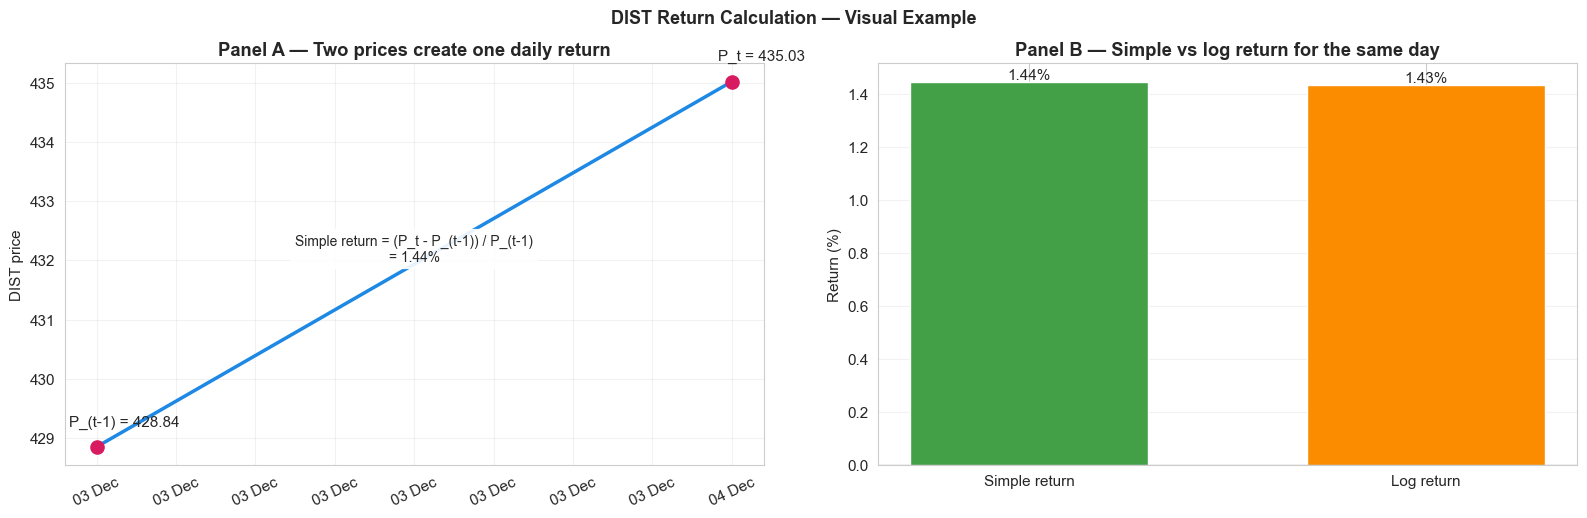

In [40]:
# Visualise how one DIST return is calculated from two consecutive prices

# Pick one clean example day before the distressed window``
example_idx = DIST_START - 5
example_date_prev = dates[example_idx - 1]
example_date_now = dates[example_idx]

example_price_prev = intro_dist_gap_neutral.iloc[example_idx - 1]
example_price_now = intro_dist_gap_neutral.iloc[example_idx]

example_simple_ret = (example_price_now - example_price_prev) / example_price_prev
example_log_ret = np.log(example_price_now / example_price_prev)

print('Example DIST return calculation')
print(f'Previous day: {example_date_prev.date()}  price = {example_price_prev:.2f}')
print(f'Current day : {example_date_now.date()}  price = {example_price_now:.2f}')
print(f'Simple return = (P_t - P_(t-1)) / P_(t-1) = {example_simple_ret:.4%}')
print(f'Log return    = ln(P_t / P_(t-1))         = {example_log_ret:.4%}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel A: two-price picture with the return formula
ax = axes[0]
ax.plot([example_date_prev, example_date_now], [example_price_prev, example_price_now],
        color='#1E88E5', marker='o', lw=2.5)
ax.scatter([example_date_prev, example_date_now], [example_price_prev, example_price_now],
           color='#D81B60', s=90, zorder=5)
ax.annotate(f'P_(t-1) = {example_price_prev:.2f}',
            (example_date_prev, example_price_prev),
            textcoords='offset points', xytext=(-20, 15), ha='left')
ax.annotate(f'P_t = {example_price_now:.2f}',
            (example_date_now, example_price_now),
            textcoords='offset points', xytext=(-10, 15), ha='left')
ax.set_title('Panel A — Two prices create one daily return', fontweight='bold')
ax.set_ylabel('DIST price')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)
ax.grid(alpha=0.25)

mid_x = example_date_prev + (example_date_now - example_date_prev) / 2
mid_y = (example_price_prev + example_price_now) / 2
ax.text(mid_x, mid_y,
        f'Simple return = (P_t - P_(t-1)) / P_(t-1)\n= {example_simple_ret:.2%}',
        fontsize=10, ha='center', va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

# Panel B: compare simple and log return values
ax = axes[1]
bar_labels = ['Simple return', 'Log return']
bar_vals = [example_simple_ret * 100, example_log_ret * 100]
bar_colors = ['#43A047', '#FB8C00']
bars = ax.bar(bar_labels, bar_vals, color=bar_colors, width=0.6)
for bar, val in zip(bars, bar_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val, f'{val:.2f}%', ha='center', va='bottom')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Panel B — Simple vs log return for the same day', fontweight='bold')
ax.set_ylabel('Return (%)')
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.suptitle('DIST Return Calculation — Visual Example', fontweight='bold', fontsize=13, y=1.03)
plt.show()

Earlier static proxy setup:
Lookback window used once at the start: 80 trading days
Cluster threshold: 0.35
DIST cluster id at distress start: 5
Fixed peers used for every missing day: ['TEL', 'AAPL', 'FFIV', 'ROP', 'CDNS', 'PTC']
Peer-choice rule: minimum correlation + sector-aware + downside-aware score | cluster-first


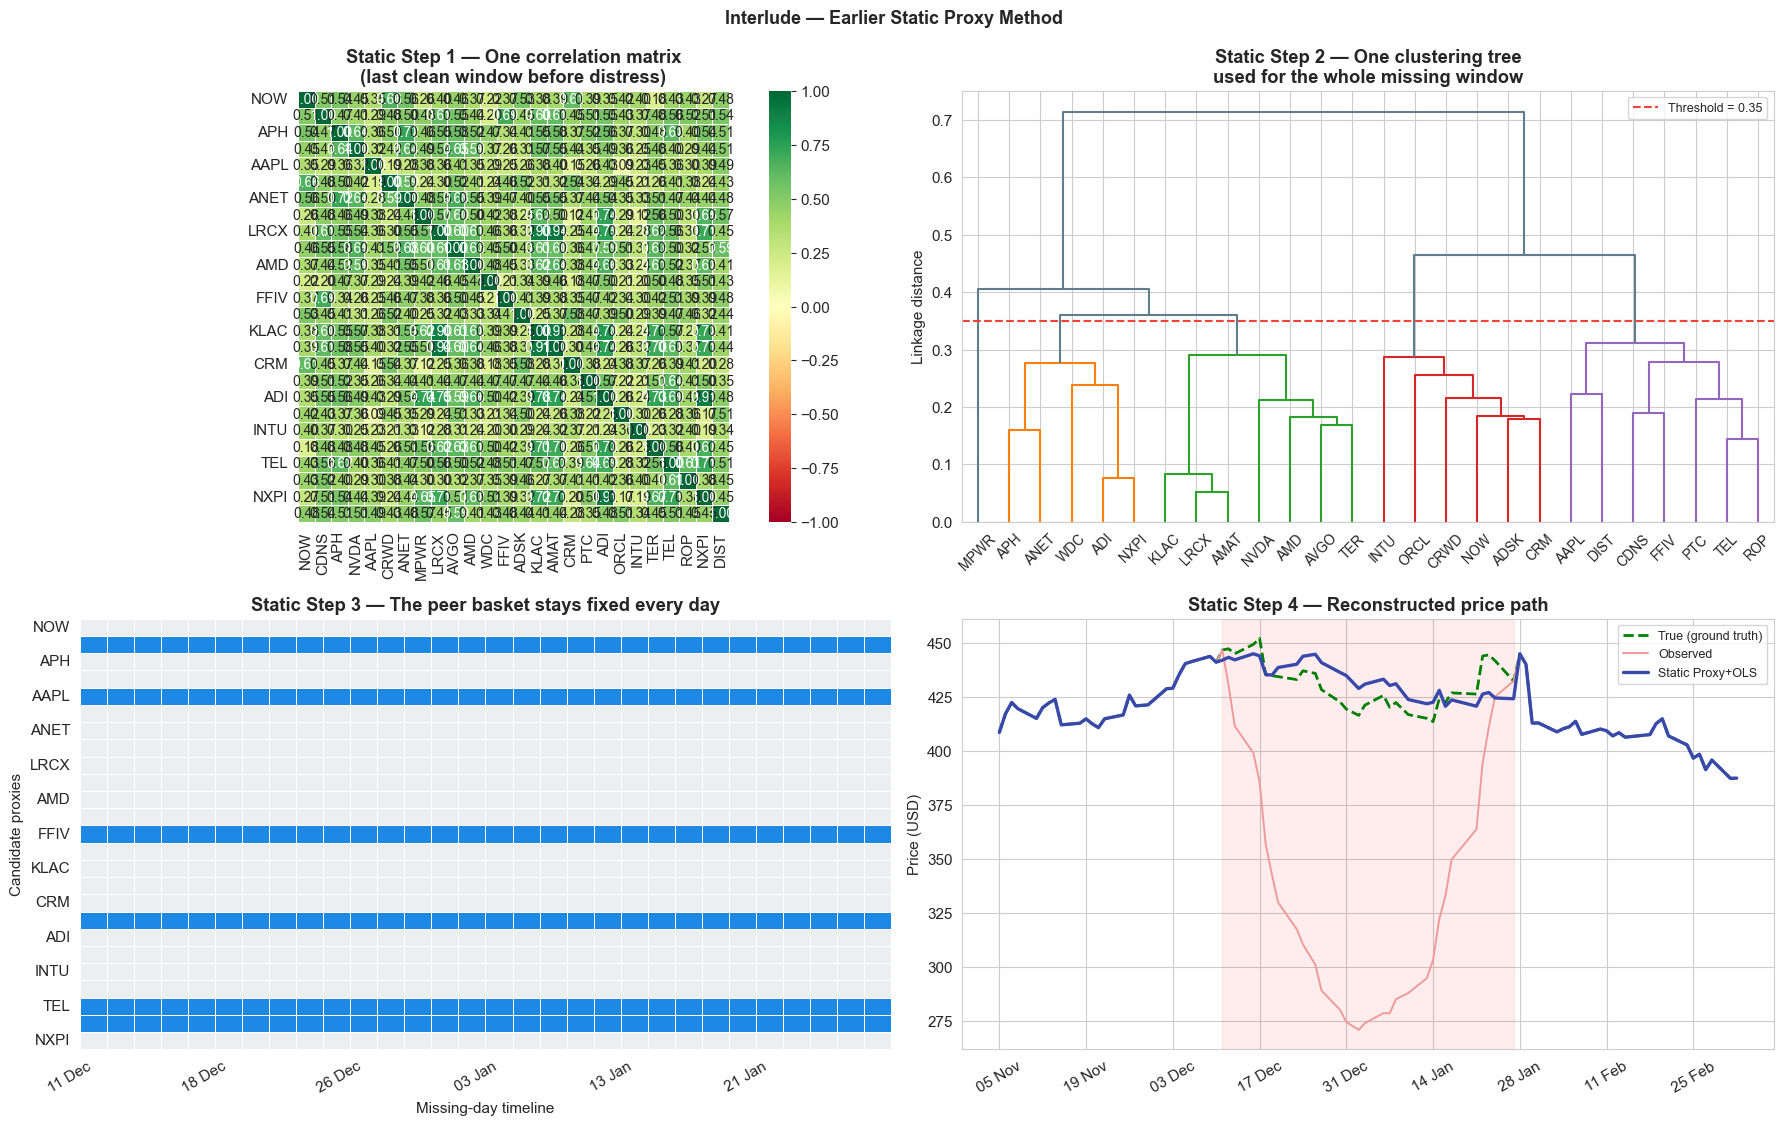

In [41]:


intro_static_df = pd.DataFrame(intro_static_records)

print('Earlier static proxy setup:')
print(f'Lookback window used once at the start: {STATIC_LOOKBACK} trading days')
print(f'Cluster threshold: {STATIC_CLUSTER_THR}')
print(f'DIST cluster id at distress start: {intro_dist_cluster}')
print(f'Fixed peers used for every missing day: {intro_peers}')
print(f'Peer-choice rule: {intro_selection_rule}')

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

ax = axes[0, 0]
sns.heatmap(intro_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, linecolor='white', annot_kws={'size': 10})
ax.set_title('Static Step 1 — One correlation matrix\n(last clean window before distress)', fontweight='bold')

ax = axes[0, 1]
dendrogram(intro_linkage, labels=intro_stocks, ax=ax,
           color_threshold=STATIC_CLUSTER_THR, above_threshold_color='#607D8B')
ax.axhline(STATIC_CLUSTER_THR, color='#F44336', ls='--', lw=1.5,
           label=f'Threshold = {STATIC_CLUSTER_THR}')
ax.set_title('Static Step 2 — One clustering tree\nused for the whole missing window', fontweight='bold')
ax.set_ylabel('Linkage distance')
ax.legend(fontsize=9)

ax = axes[1, 0]
intro_peer_map = pd.DataFrame(False, index=intro_static_df['date'], columns=static_proxy_candidates)
for peer in intro_peers:
    intro_peer_map.loc[:, peer] = True
sns.heatmap(intro_peer_map.T.astype(int), cmap=sns.color_palette(['#ECEFF1', '#1E88E5']),
            cbar=False, linewidths=0.4, linecolor='white', ax=ax)
ax.set_title('Static Step 3 — The peer basket stays fixed every day', fontweight='bold')
ax.set_xlabel('Missing-day timeline')
ax.set_ylabel('Candidate proxies')
ax.set_xticks(np.arange(0.5, len(intro_peer_map.index), 5))
ax.set_xticklabels([d.strftime('%d %b') for d in intro_peer_map.index[::5]], rotation=30, ha='right')

ax = axes[1, 1]
intro_z0, intro_z1 = DIST_START - 25, DIST_END + 25
ax.plot(dates[intro_z0:intro_z1], P['DIST_TRUE'].iloc[intro_z0:intro_z1], 'g--', lw=2,
        label='True (ground truth)')
ax.plot(dates[intro_z0:intro_z1], P['DIST_OBS'].iloc[intro_z0:intro_z1], color='#EF9A9A', lw=1.4,
        label='Observed')
ax.plot(dates[intro_z0:intro_z1], intro_dist_recon.iloc[intro_z0:intro_z1], color='#3949AB', lw=2.4,
        label='Static Proxy+OLS')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
ax.set_title('Static Step 4 — Reconstructed price path', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.suptitle('Interlude — Earlier Static Proxy Method', fontweight='bold', fontsize=13, y=1.02)
plt.show()

### How to Read the Static Proxy Graphs

This interlude figure explains the older proxy method that uses **one fixed similarity snapshot** before the missing window.

### Panel A — One Correlation Matrix

**What it shows**

A single correlation matrix built from the last clean legacy window before distress starts.

**Why we use it**

This is the starting information set for the static method. It decides which stocks look most similar before any missing-day prediction begins.

**How to read it**

1. Find the DIST row or column.
2. Identify which names have the strongest correlations with DIST.
3. Remember that this snapshot is taken once and then reused for the whole missing window.

### Panel B — One Clustering Tree

**What it shows**

A single dendrogram built from that same fixed window.

**Why we use it**

It turns the correlation snapshot into a group structure so we can choose a peer cluster for DIST.

**How to read it**

1. Follow DIST in the tree.
2. See which names join DIST at low linkage distance.
3. The horizontal threshold line decides which names are considered part of the same cluster.

### Panel C — Fixed Peer Basket

**What it shows**

A heatmap showing that the same peers are used on every missing day.

**Why we use it**

This is the core visual difference between static and dynamic proxy selection.

**How to read it**

1. Read down the chosen peer names.
2. Read across the missing-day timeline.
3. If a peer stays highlighted for all days, the basket is fixed by construction.

### Panel D — Static Reconstruction

**What it shows**

The price path reconstructed using that one fixed peer basket.

**Why we use it**

This tells you how far a single pre-window peer choice can carry the reconstruction.

**How to read it**

1. Compare the static reconstruction with the dashed true line inside the distressed window.
2. Check whether error grows as the window progresses.
3. If the line drifts badly, the fixed-basket assumption may be too rigid.

**Debugger tip**

If the static method fails, ask whether the initial cluster was poor or whether the market relationships changed after the window started.

### How to Read the Cluster Part of This Cell — Beginner Explanation

This cell is doing two related things:

1. it builds a **cluster view** of the stocks
2. it uses that cluster view to choose candidate peers for DIST

### What does a cluster mean here?

A **cluster** is just a group of stocks that behaved similarly in the clean lookback window.

In this notebook, "similar" mainly means:

- their returns moved together often
- their correlation-based distance is small
- the clustering tree puts them close together

So when we say a stock is in the same cluster as DIST, we mean:

> based on the clean legacy history, this stock looks like one of DIST's closest behavioural neighbours

### How to read `DIST cluster id`

The printed `DIST cluster id` is just the label assigned to DIST after cutting the clustering tree.

Important point for beginners:

- the number itself does **not** have economic meaning
- cluster `1` is not automatically better than cluster `2` or cluster `3`
- it is only an internal group label

What matters is **who else is inside the same cluster as DIST**, not the number of the label.

### How to read the dendrogram

The dendrogram is the tree diagram in the cluster panel.

Read it like this:

1. Start at `DIST`.
2. Look for the names that join DIST at a **low height**.
3. Lower joining height means more similar behaviour.
4. The horizontal threshold line cuts the tree into final groups.
5. Any names connected with DIST below that cut are treated as part of DIST's cluster.

### Beginner intuition

Think of the dendrogram like a family tree of similarity.
Stocks that join together very low in the tree are like close relatives in behaviour.
Stocks that only join at high levels are more distant relatives.

### What this cell is trying to do scientifically

This cell is not yet fitting the regression. First it is solving a **peer-selection problem**:

- which stocks are most similar to DIST in the clean legacy regime?
- which of those should be trusted as candidate predictors?

So the clustering step is really a **preprocessing / model design** step before the regression step.

### Why clustering helps

If we skipped clustering and just used every stock, we could accidentally include names that:

- belong to a different sector
- move very differently from DIST
- add noise instead of signal

Clustering is a way to narrow the peer universe to a smaller, more plausible set of candidates.

### Can we use different clustering approaches?

Yes. The current notebook uses **hierarchical clustering with Ward linkage**, but that is only one option.

Other reasonable choices include:

1. **Average linkage hierarchical clustering**
This merges groups using average pairwise distance rather than Ward's criterion.
It can be easier to interpret when you care about average similarity rather than compact variance-based clusters.

2. **Complete linkage hierarchical clustering**
This is stricter: a cluster is only tight if even its most distant members are still close.
Useful if you want more conservative peer groups.

3. **Single linkage hierarchical clustering**
This can create long chain-like clusters, so it is usually less stable for peer selection, but it is still a valid alternative.

4. **K-means clustering**
This works better in feature space than directly on a correlation distance matrix.
It is fast, but you must choose the number of clusters in advance.

5. **Spectral clustering**
Useful when similarity structure is more complex and not well captured by simple geometric clusters.
More flexible, but also more advanced.

6. **Graph / network methods**
You can treat stocks as nodes and similarity as weighted edges, then detect communities.
This is often appealing in finance when thinking about market structure.

### Which alternatives are most realistic here?

For this notebook, the most natural alternatives would be:

- hierarchical clustering with a different linkage rule
- K-means on a feature representation of returns
- graph-based community detection if you want a more network-style interpretation

### Practical beginner takeaway

When reading this cell, think in this order:

1. **Correlation matrix**: who looks similar to DIST?
2. **Dendrogram**: which names join DIST at low distance?
3. **Cluster membership**: who survives inside DIST's group after the threshold cut?
4. **Peer basket**: which of those names are finally chosen for the reconstruction model?

That is the full logic from raw similarity to final peer choice.

### Why Ward Linkage Was Chosen Here

We use **Ward linkage** here because it tends to create **compact, stable clusters**.
That is useful when the goal is to find a small peer group for DIST that behaves consistently rather than loosely.

A short comparison:

- **Ward linkage**: merges groups in a way that tries to keep within-cluster variation small. Good when you want tight, well-separated peer baskets.
- **Average linkage**: merges groups using average pairwise distance. It is often more flexible, but can produce broader clusters that are less selective.
- **Complete linkage**: looks at the farthest pair when merging groups. It is stricter and can create very tight clusters, but sometimes becomes too conservative and splits plausible peers apart.

### Why do we use a threshold at all?

The clustering tree by itself does not yet tell us the final groups.
We still need a **cut level** to decide where the tree should be split into clusters.

That cut level is the **threshold** shown by the horizontal line in the dendrogram.
In this notebook, that threshold is `STATIC_CLUSTER_THR = 0.35`.

### Beginner intuition for the threshold

Think of the dendrogram like a tree of friendships:

- names that join together **below** the threshold are treated as close enough to belong to the same group
- names that only join **above** the threshold are treated as too different and stay in separate groups

So the threshold is simply the rule that says:

> how similar do two stocks need to be before we allow them into the same cluster?

### How to read the threshold

- **Lower threshold** = stricter clustering
- fewer names join DIST's group
- clusters are smaller and tighter

- **Higher threshold** = looser clustering
- more names are allowed into DIST's group
- clusters are bigger and broader

### Why was `0.35` chosen here?

We chose `0.35` as a practical middle ground:

- low enough to avoid very loose peer groups
- high enough that DIST is not left isolated too often
- suitable for a small notebook example where we want a cluster that is selective but still usable for regression

So this value is not a universal truth. It is a modelling choice.

### Scientific interpretation

The threshold controls the tradeoff between:

- **cluster purity**: tighter, more homogeneous peers
- **cluster size**: enough peers to build a useful regression model

If the threshold is too low, you may get very pure clusters but not enough peer names.
If the threshold is too high, you may get enough names but they may be too weakly related to DIST.

### Practical reason in this notebook

For peer selection, Ward plus a threshold of `0.35` is a good default because we want clusters that are:

- relatively compact
- not too loose
- stable enough to support regression on a small basket of peers

So Ward is not the only valid choice, and `0.35` is not the only valid threshold, but together they form a reasonable middle-ground starting point for this example.

### Why do we divide `intro_dist_gap_neutral.iloc[GAP_DAY:]` by `adj_factor`?

This step removes the one-time **corporate-action jump** before we start the static proxy reconstruction.

The observed series `DIST_OBS` was intentionally pushed upward from the gap day onward in the controlled AAPL scenario. So here we undo that level shift by dividing the post-gap part of the series by the same adjustment factor.

In plain English, this line says:

- copy the observed DIST price series
- go to the gap day and every day after it
- divide those prices by `adj_factor`
- bring the series back onto the old legacy price scale

So the code

```python
intro_dist_gap_neutral.iloc[GAP_DAY:] /= adj_factor
```

means

$$
P_t^{\text{gap-neutral}} = \frac{P_t^{\text{observed}}}{\text{adj\_factor}}, \quad t \geq \text{GAP\_DAY}
$$

### Why do we do this before the proxy model?

If we leave the jump in place, the model would treat a mechanical level shift as if it were normal market behavior.
That would distort the return series, correlation structure, and the later peer-based regression.

### Small intuition example

- price before gap: `100`
- price after controlled jump: `108`
- adjustment factor: `1.08`
- gap-neutralised price: `108 / 1.08 = 100`

So this step does **not** fix the distressed window yet. It only removes the separate corporate-action distortion so the later proxy method starts from a cleaner series.

## Approach 3E — Dynamic Proxy Selection via Rolling Correlations, Clustering, and OLS

This is the most advanced approach in the notebook and the one most consistent with the idea that a distressed name can emerge from restructuring as a **different stock**.

### Why a *regime-aware dynamic* proxy method?

The section just above showed the earlier **static proxy** idea: build one correlation matrix, build one clustering tree, choose one peer basket, and then reuse that same basket for the whole missing window.

That is a useful starting point because it is simple and easy to explain. But in real data, the "best" peer group can shift over time. A stock that was a strong proxy last month may become less useful this week because:

- sector leadership rotates,
- volatility regimes change,
- event spillovers affect some peers but not others,
- a peer temporarily decouples from the target stock,
- the distressed issuer is approaching a restructuring event that changes its economic identity.

So instead of picking proxies **once**, we re-evaluate them **for every single missing day**, but only within the **legacy regime**.

### Beginner Intuition

Think of DIST as a microphone that stopped working for 30 trading days.
We still hear the rest of the orchestra: PEER_A, PEER_B, PEER_C, OTHER_X, OTHER_Y.
For each missing day we ask five questions:

1. Have we first removed any *structural* level shift, such as the corporate-action gap?
2. Are we still reconstructing the **legacy** stock rather than the post-restructuring entity?
3. Which instruments currently sound most similar to legacy DIST based on the most recent legacy history?
4. Which group (cluster) does legacy DIST belong to *today*?
5. Given what those peers played today, what would legacy DIST most likely have played?

Then we use that predicted return to rebuild the missing legacy price path one day at a time.

### From Static to Dynamic

- **Static proxy**: one similarity snapshot, one cluster decision, one fixed peer basket
- **Dynamic proxy**: a new similarity snapshot each day, a new cluster check each day, and the peer basket can change when the data says it should

The static method answers: "who looked closest right before the window started?"
The dynamic method answers: "who looks closest **today**, based on the latest legacy information?"

### Daily Methodology — Plain-English Version

For each missing day $t$, the workflow is:

| Step | What we do | Why it matters |
|------|------------|----------------|
| 0 | **Gap-neutralise DIST first**. Remove any one-off corporate-action jump so the series is on the same price basis as the old legacy stock. | If you skip this, the model starts from the wrong level and every later prediction is anchored badly. |
| 1 | **Use only the pre-restructuring regime**. Train only on the part of history where DIST still behaves like the old company. | This avoids mixing the legacy stock with the post-restructuring stock, which may have different risk, sector exposure, and business economics. |
| 2 | **Take a rolling lookback window ending at $t-1$**. For each missing day, use only the recent past up to the day before. | This keeps the model realistic and avoids using future information. It also lets relationships change over time. |
| 3 | **Compute the correlation matrix in that window**. Measure how similarly DIST and the peer stocks have been moving recently. | Correlation is the first clue about which peers are currently useful proxies. |
| 4 | **Turn correlation into distance** with $d_{ij} = (1 - \rho_{ij})/2$. | Clustering methods work with distances, not correlations. High correlation becomes small distance; weak correlation becomes larger distance. |
| 5 | **Run hierarchical clustering**. Group stocks that have been moving similarly in the recent window. | This helps us find a peer group that behaves like legacy DIST right now, not just on average across the whole sample. |
| 6 | **Find DIST's cluster for that day**. Use the cluster containing DIST to choose candidate proxy stocks. | The best peer set may change from day to day, especially during stressed markets. |
| 7 | **Fit OLS on the selected peers**. Learn a simple relationship between peer returns and legacy DIST returns using the same lookback window. | This is the step where the model learns how DIST usually reacts when its peers move. |
| 8 | **Predict the missing return for day $t$**. Feed in the peers' observed moves on day $t$ and estimate what legacy DIST likely did that day. | We are reconstructing the missing **return**, not guessing the price directly. |
| 9 | **Rebuild the price from the predicted return**. Chain the predicted return onto the previous reconstructed price. | Returns are the model output; prices are rebuilt from those returns one day at a time. |
| 10 | **Stop at restructuring**. Do not continue pretending that the old and new stock are the same asset after the regime break. | This preserves the economic meaning of the legacy series. |

### Where does the adjustment factor come from in practice?

In this notebook, we infer the gap adjustment factor from the observed return jump in the controlled AAPL scenario.
In a real-world workflow, you would usually get the factor from **corporate-actions data**, not guess it from the chart alone.

Typical sources are:

- market data vendors such as Bloomberg, Refinitiv, FactSet, CRSP, or your exchange data feed
- issuer filings and exchange notices
- split, dividend, rights issue, spin-off, or merger event terms stored in a corporate-actions database

Examples:

- a **2-for-1 split** gives a known split adjustment factor
- a **special dividend** gives a vendor-provided dividend adjustment factor
- a **spin-off** or **rights issue** uses the event terms to compute the back-adjustment ratio
- a **cash merger jump** may be linked to the announced deal price rather than inferred statistically

So in production, Step 0 usually means: **first clean the series using known corporate-action metadata, then run the proxy reconstruction on the cleaned legacy series.**

### Important Detail: Why not anchor to post-distress prices?

Because after restructuring, the stock may have:

- new leverage,
- new business lines,
- different investor base,
- different beta to its sector,
- different volatility profile.

So the first post-distress observation is **not automatically a legitimate anchor** for the legacy stock. That is the main reason the proxy approach becomes preferable to backward-fill, linear interpolation, or spline methods.

### Design Choices Used Here

- **Gap neutralisation**: divide the post-gap DIST prices by the inferred corporate-action factor
- **Legacy-only estimation**: clean correlations are estimated only before restructuring
- **Lookback window**: 80 recent trading days
- **Distance threshold**: fixed dendrogram cut at 0.35
- **Minimum peer count**: if DIST's cluster is too small, fall back to the top correlated peers
- **Regression target**: daily **log return** of legacy DIST
- **Price reconstruction**: convert predicted log return back to price with $P_t = P_{t-1} e^{\hat r_t}$

### What the charts below will show

1. A correlation heatmap for the **first missing day**
2. The dendrogram for that same day
3. Which peers were selected on **each** missing day
4. How stable the daily cluster choice and model fit are
5. How predicted returns compare with the reference legacy returns
6. How the final reconstructed legacy price path compares with the reference path inside the distressed window

In [42]:
model_peer_cols

['NOW',
 'CDNS',
 'APH',
 'NVDA',
 'AAPL',
 'CRWD',
 'ANET',
 'MPWR',
 'LRCX',
 'AVGO',
 'AMD',
 'WDC',
 'FFIV',
 'ADSK',
 'KLAC',
 'AMAT',
 'CRM',
 'PTC',
 'ADI',
 'ORCL',
 'INTU',
 'TER',
 'TEL',
 'ROP',
 'NXPI']

Dynamic proxy selection summary (first 10 missing days):
      date  cluster_id peer_1 peer_2 peer_3            selection_rule  model_r2  pred_log_ret
2024-12-11           6   MPWR   AAPL   None              same cluster  0.411201      0.005923
2024-12-12           2   CDNS   ORCL   FFIV              same cluster  0.402117     -0.003509
2024-12-13           7   AVGO   MPWR   CDNS fallback top correlations  0.461295      0.027864
2024-12-16           4   AVGO   ANET    APH              same cluster  0.412183      0.021989
2024-12-17           6   AVGO   ANET    APH              same cluster  0.429595     -0.008826
2024-12-18           1   AVGO   ANET    APH              same cluster  0.434670     -0.023098
2024-12-19           3   AVGO   AAPL   None              same cluster  0.482801     -0.001627
2024-12-20           4   AVGO   ANET    APH              same cluster  0.455626      0.004273
2024-12-23           4   AVGO   ANET    APH              same cluster  0.454062      0.009841
202

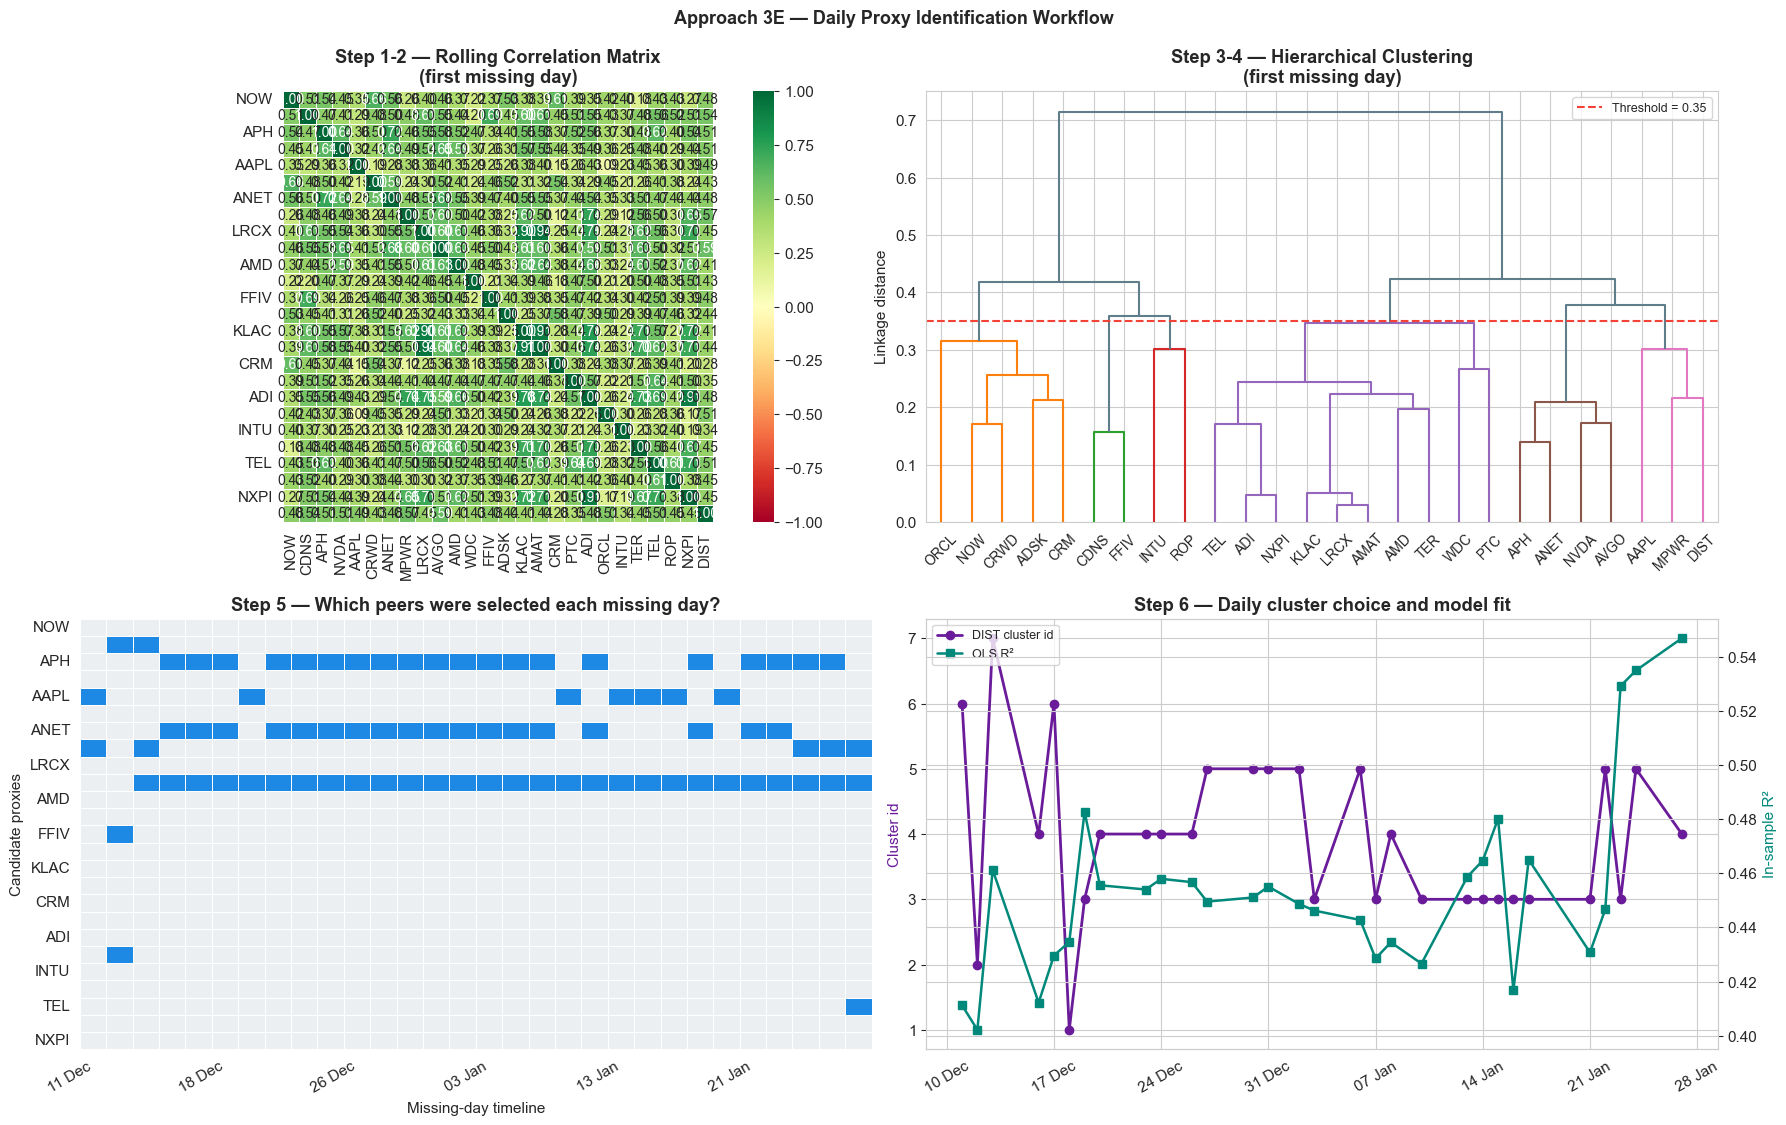

In [43]:
# Reusable helper code for the proxy-based reconstruction methods

LOOKBACK = 80
CLUSTER_THR = 0.35
MAX_PEERS = 3
MIN_PEERS = 2
proxy_candidates = model_peer_cols.copy()
FEATURE_CONFIG = {
    'ret_1d': 1,
    'ret_3d': 3,
    'ret_5d': 5,
    'ret_10d': 10,
    'vol_5d': 5,
    'vol_10d': 10,
    'drawdown_5d': 5,
    'drawdown_10d': 10,
    'downside_semivol_5d': 5,
    'downside_semivol_10d': 10,
    'spread_mean_1d': 1,
    'spread_mean_3d': 3,
    'spread_mean_5d': 5,
}
MAX_SELECTED_FEATURES = 6
PCA_VAR_THRESHOLD = 0.9
PCA_MAX_COMPONENTS = 3
FEATURE_COUNT_GRID = [4, 6, 8, 10]
PCA_VAR_GRID = [0.8, 0.9, 0.95]
PCA_COMPONENT_GRID = [2, 3, 4]


def choose_proxy_peers(corr_window, labels_now, stocks_now, max_peers=3, min_peers=2):
    # Try to use peers from DIST's own cluster first
    dist_cluster = labels_now[stocks_now.index('DIST')]
    same_cluster = [
        stock for stock, cluster_id in zip(stocks_now, labels_now)
        if cluster_id == dist_cluster and stock != 'DIST'
    ]
    corr_rank = corr_window['DIST'].drop('DIST').sort_values(ascending=False)

    if len(same_cluster) >= min_peers:
        chosen_peers = sorted(
            same_cluster,
            key=lambda stock: corr_window.loc['DIST', stock],
            reverse=True,
        )[:max_peers]
        selection_rule = 'same cluster'
    else:
        chosen_peers = corr_rank.index[:max_peers].tolist()
        selection_rule = 'fallback top correlations'

    return dist_cluster, chosen_peers, selection_rule


def rolling_downside_semivol(series, window):
    # Measure downside risk only by ignoring positive returns
    downside_sq = np.square(np.minimum(series, 0.0))
    return downside_sq.rolling(window).mean().pow(0.5)


def rolling_drawdown_from_returns(series, window):
    # Build a simple price path from returns, then measure drawdown
    pseudo_price = np.exp(series.cumsum())
    rolling_peak = pseudo_price.rolling(window).max()
    return pseudo_price / rolling_peak - 1.0


def build_peer_feature_frame(ret_frame, peers, feature_config):
    # Create a set of simple and multi-day features for the selected peers
    feature_df = pd.DataFrame(index=ret_frame.index)
    cluster_mean_1d = ret_frame[peers].mean(axis=1)

    for peer in peers:
        peer_series = ret_frame[peer]
        feature_df[f'{peer}_ret_1d'] = peer_series
        for feature_name, horizon in feature_config.items():
            if feature_name == 'ret_1d':
                continue
            if feature_name.startswith('ret_'):
                feature_df[f'{peer}_{feature_name}'] = peer_series.rolling(horizon).sum()
            elif feature_name.startswith('vol_'):
                feature_df[f'{peer}_{feature_name}'] = peer_series.rolling(horizon).std()
            elif feature_name.startswith('drawdown_'):
                feature_df[f'{peer}_{feature_name}'] = rolling_drawdown_from_returns(peer_series, horizon)
            elif feature_name.startswith('downside_semivol_'):
                feature_df[f'{peer}_{feature_name}'] = rolling_downside_semivol(peer_series, horizon)
            elif feature_name.startswith('spread_mean_'):
                if horizon == 1:
                    peer_spread = peer_series - cluster_mean_1d
                else:
                    peer_spread = peer_series.rolling(horizon).sum() - cluster_mean_1d.rolling(horizon).sum()
                feature_df[f'{peer}_{feature_name}'] = peer_spread
    return feature_df


def select_features(train_features, target, max_features=6):
    # Keep the features that move most closely with DIST in the training window
    aligned = train_features.copy()
    aligned['target'] = target
    aligned = aligned.dropna()
    if aligned.empty:
        return [], pd.Series(dtype=float)
    feature_cols = [col for col in aligned.columns if col != 'target']
    score_series = aligned[feature_cols].corrwith(aligned['target']).abs().fillna(0.0)
    selected = score_series.sort_values(ascending=False).head(max_features).index.tolist()
    return selected, score_series.sort_values(ascending=False)


def fit_raw_feature_model(train_features, target, selected_features):
    # Standardise the chosen features, then fit a linear model
    aligned = train_features[selected_features].copy()
    aligned['target'] = target
    aligned = aligned.dropna()
    X = aligned[selected_features].values
    y = aligned['target'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    reg = LinearRegression().fit(X_scaled, y)
    r2 = reg.score(X_scaled, y)

    return {
        'scaler': scaler,
        'reg': reg,
        'r2': r2,
        'n_components': len(selected_features),
        'explained_var': 1.0,
    }


def fit_feature_pca_model(train_features, target, selected_features,
                          pca_var_threshold=0.9, pca_max_components=3):
    # Standardise the chosen features, compress them with PCA, then fit a linear model
    aligned = train_features[selected_features].copy()
    aligned['target'] = target
    aligned = aligned.dropna()
    X = aligned[selected_features].values
    y = aligned['target'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    full_pca = PCA().fit(X_scaled)
    cum_var = np.cumsum(full_pca.explained_variance_ratio_)
    n_components = np.searchsorted(cum_var, pca_var_threshold) + 1
    n_components = max(1, min(n_components, pca_max_components, X_scaled.shape[1]))

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    reg = LinearRegression().fit(X_pca, y)
    r2 = reg.score(X_pca, y)

    return {
        'scaler': scaler,
        'pca': pca,
        'reg': reg,
        'r2': r2,
        'n_components': n_components,
        'explained_var': pca.explained_variance_ratio_.sum(),
    }


def compute_proxy_reconstruction(mode='dynamic', lookback=80, cluster_thr=0.35,
                                 max_peers=3, min_peers=2):
    # First remove the one-day gap so DIST is on a cleaner price level
    dist_gap_neutral = P['DIST_OBS'].copy()
    dist_gap_neutral.iloc[GAP_DAY:] /= adj_factor

    dist_gap_log_ret = np.log(dist_gap_neutral / dist_gap_neutral.shift(1)).dropna()
    ret_work = ret_df.copy()
    ret_work['DIST'] = dist_gap_log_ret.values
    dist_recon = dist_gap_neutral.copy()

    static_setup = None
    if mode == 'static':
        # Static mode chooses one peer set at the start and reuses it every day
        static_ret_row = DIST_START - 1
        static_window_end = static_ret_row
        static_window_start = max(0, static_window_end - lookback)
        static_window_df = ret_work.iloc[static_window_start:static_window_end].copy()
        static_corr = static_window_df.corr()
        static_dist = ((1 - static_corr) / 2).clip(lower=0, upper=1)
        np.fill_diagonal(static_dist.values, 0.0)
        static_stocks = static_corr.columns.tolist()
        static_linkage = linkage(squareform(static_dist.values), method='ward')
        static_labels = fcluster(static_linkage, t=cluster_thr, criterion='distance')
        static_cluster_id, static_peers, static_rule = choose_proxy_peers(
            static_corr, static_labels, static_stocks, max_peers=max_peers, min_peers=min_peers
        )
        static_setup = {
            'corr': static_corr,
            'linkage': static_linkage,
            'stocks': static_stocks,
            'cluster_id': static_cluster_id,
            'peers': static_peers,
            'selection_rule': static_rule,
        }

    daily_records = []
    first_day_corr = None
    first_day_linkage = None
    first_day_stocks = None

    for current_idx in range(DIST_START, DIST_END):
        # For each missing day, look only at history up to the day before
        ret_row = current_idx - 1
        window_end = ret_row
        window_start = max(0, window_end - lookback)
        window_df = ret_work.iloc[window_start:window_end].copy()

        corr_window = window_df.corr()
        dist_window = ((1 - corr_window) / 2).clip(lower=0, upper=1)
        np.fill_diagonal(dist_window.values, 0.0)
        stocks_now = corr_window.columns.tolist()
        Z_window = linkage(squareform(dist_window.values), method='ward')
        labels_now = fcluster(Z_window, t=cluster_thr, criterion='distance')

        if mode == 'dynamic':
            dist_cluster, chosen_peers, selection_rule = choose_proxy_peers(
                corr_window, labels_now, stocks_now, max_peers=max_peers, min_peers=min_peers
            )
        else:
            dist_cluster = static_setup['cluster_id']
            chosen_peers = static_setup['peers']
            selection_rule = 'fixed initial cluster'

        # Fit a simple regression from peer returns to DIST returns
        train_df = window_df[['DIST'] + chosen_peers].dropna()
        X_train = train_df[chosen_peers].values
        y_train = train_df['DIST'].values
        reg = LinearRegression().fit(X_train, y_train)
        r2 = reg.score(X_train, y_train)

        # Use today's peer moves to predict today's missing DIST return
        peer_today = ret_df.iloc[ret_row][chosen_peers]
        pred_log_ret = reg.predict(peer_today.to_frame().T)[0]
        true_log_ret = np.log(P['DIST_TRUE'].iloc[current_idx] / P['DIST_TRUE'].iloc[current_idx - 1])

        # Feed the predicted return back into the working series and price path
        ret_work.iloc[ret_row, ret_work.columns.get_loc('DIST')] = pred_log_ret
        dist_recon.iloc[current_idx] = dist_recon.iloc[current_idx - 1] * np.exp(pred_log_ret)

        record = {
            'date': dates[current_idx],
            'day_index': current_idx,
            'cluster_id': dist_cluster,
            'peer_count': len(chosen_peers),
            'selection_rule': selection_rule,
            'window_start': ret_df.index[window_start],
            'window_end': ret_df.index[window_end - 1],
            'pred_log_ret': pred_log_ret,
            'true_log_ret': true_log_ret,
            'model_r2': r2,
        }

        for rank in range(max_peers):
            record[f'peer_{rank + 1}'] = chosen_peers[rank] if rank < len(chosen_peers) else None
            record[f'beta_{rank + 1}'] = reg.coef_[rank] if rank < len(chosen_peers) else np.nan
            record[f'corr_{rank + 1}'] = (
                corr_window.loc['DIST', chosen_peers[rank]] if rank < len(chosen_peers) else np.nan
            )

        daily_records.append(record)

        if first_day_corr is None:
            # Save the first day's objects for the explanation charts
            first_day_corr = corr_window.copy()
            first_day_linkage = Z_window.copy()
            first_day_stocks = stocks_now.copy()

    return {
        'series': dist_recon,
        'daily_df': pd.DataFrame(daily_records),
        'first_day_corr': first_day_corr,
        'first_day_linkage': first_day_linkage,
        'first_day_stocks': first_day_stocks,
        'gap_neutral_series': dist_gap_neutral,
        'static_setup': static_setup,
        'mode': mode,
        'lookback': lookback,
        'cluster_thr': cluster_thr,
    }


def compute_feature_proxy_reconstruction(use_pca=True, lookback=80, cluster_thr=0.35,
                                         max_peers=3, min_peers=2,
                                         max_selected_features=6,
                                         pca_var_threshold=0.9,
                                         pca_max_components=3):
    # This version adds engineered peer features before the regression step
    dist_gap_neutral = P['DIST_OBS'].copy()
    dist_gap_neutral.iloc[GAP_DAY:] /= adj_factor

    dist_gap_log_ret = np.log(dist_gap_neutral / dist_gap_neutral.shift(1)).dropna()
    ret_work = ret_df.copy()
    ret_work['DIST'] = dist_gap_log_ret.values
    dist_recon = dist_gap_neutral.copy()

    daily_records = []
    first_day_corr = None
    first_day_linkage = None
    first_day_stocks = None
    first_day_feature_scores = None

    for current_idx in range(DIST_START, DIST_END):
        ret_row = current_idx - 1
        window_end = ret_row
        window_start = max(0, window_end - lookback)
        window_df = ret_work.iloc[window_start:window_end].copy()

        corr_window = window_df.corr()
        dist_window = ((1 - corr_window) / 2).clip(lower=0, upper=1)
        np.fill_diagonal(dist_window.values, 0.0)
        stocks_now = corr_window.columns.tolist()
        Z_window = linkage(squareform(dist_window.values), method='ward')
        labels_now = fcluster(Z_window, t=cluster_thr, criterion='distance')
        dist_cluster, chosen_peers, selection_rule = choose_proxy_peers(
            corr_window, labels_now, stocks_now, max_peers=max_peers, min_peers=min_peers
        )

        feature_frame = build_peer_feature_frame(window_df, chosen_peers, FEATURE_CONFIG)
        selected_features, feature_scores = select_features(
            feature_frame, window_df['DIST'], max_features=max_selected_features
        )
        if use_pca:
            feature_model = fit_feature_pca_model(
                feature_frame,
                window_df['DIST'],
                selected_features,
                pca_var_threshold=pca_var_threshold,
                pca_max_components=pca_max_components,
            )
        else:
            feature_model = fit_raw_feature_model(
                feature_frame,
                window_df['DIST'],
                selected_features,
            )

        # Build today's feature row, then predict the missing DIST return
        feature_today = build_peer_feature_frame(
            ret_work.iloc[max(0, window_start - 10):window_end + 1].copy(),
            chosen_peers,
            FEATURE_CONFIG,
        ).iloc[-1:][selected_features]
        feature_today_scaled = feature_model['scaler'].transform(feature_today.values)
        if use_pca:
            model_input = feature_model['pca'].transform(feature_today_scaled)
        else:
            model_input = feature_today_scaled
        pred_log_ret = feature_model['reg'].predict(model_input)[0]
        true_log_ret = np.log(P['DIST_TRUE'].iloc[current_idx] / P['DIST_TRUE'].iloc[current_idx - 1])

        ret_work.iloc[ret_row, ret_work.columns.get_loc('DIST')] = pred_log_ret
        dist_recon.iloc[current_idx] = dist_recon.iloc[current_idx - 1] * np.exp(pred_log_ret)

        record = {
            'date': dates[current_idx],
            'day_index': current_idx,
            'cluster_id': dist_cluster,
            'peer_count': len(chosen_peers),
            'selection_rule': selection_rule,
            'selected_features': ', '.join(selected_features),
            'n_components': feature_model['n_components'],
            'explained_var': feature_model['explained_var'],
            'pred_log_ret': pred_log_ret,
            'true_log_ret': true_log_ret,
            'model_r2': feature_model['r2'],
        }
        for rank in range(max_peers):
            record[f'peer_{rank + 1}'] = chosen_peers[rank] if rank < len(chosen_peers) else None
        daily_records.append(record)

        if first_day_corr is None:
            first_day_corr = corr_window.copy()
            first_day_linkage = Z_window.copy()
            first_day_stocks = stocks_now.copy()
            first_day_feature_scores = feature_scores.copy()

    return {
        'series': dist_recon,
        'daily_df': pd.DataFrame(daily_records),
        'first_day_corr': first_day_corr,
        'first_day_linkage': first_day_linkage,
        'first_day_stocks': first_day_stocks,
        'first_day_feature_scores': first_day_feature_scores,
        'gap_neutral_series': dist_gap_neutral,
        'mode': 'feature_pca' if use_pca else 'feature_raw',
        'lookback': lookback,
        'cluster_thr': cluster_thr,
        'max_selected_features': max_selected_features,
        'pca_var_threshold': pca_var_threshold,
        'pca_max_components': pca_max_components,
    }


dynamic_result = compute_proxy_reconstruction(
    mode='dynamic',
    lookback=LOOKBACK,
    cluster_thr=CLUSTER_THR,
    max_peers=MAX_PEERS,
    min_peers=MIN_PEERS,
)
static_result = compute_proxy_reconstruction(
    mode='static',
    lookback=LOOKBACK,
    cluster_thr=CLUSTER_THR,
    max_peers=MAX_PEERS,
    min_peers=MIN_PEERS,
)
feature_raw_result = compute_feature_proxy_reconstruction(
    use_pca=False,
    lookback=LOOKBACK,
    cluster_thr=CLUSTER_THR,
    max_peers=MAX_PEERS,
    min_peers=MIN_PEERS,
    max_selected_features=MAX_SELECTED_FEATURES,
)
feature_pca_result = compute_feature_proxy_reconstruction(
    use_pca=True,
    lookback=LOOKBACK,
    cluster_thr=CLUSTER_THR,
    max_peers=MAX_PEERS,
    min_peers=MIN_PEERS,
    max_selected_features=MAX_SELECTED_FEATURES,
    pca_var_threshold=PCA_VAR_THRESHOLD,
    pca_max_components=PCA_MAX_COMPONENTS,
)

proxy_daily_df = dynamic_result['daily_df']
static_proxy_df = static_result['daily_df']
feature_raw_df = feature_raw_result['daily_df']
feature_pca_df = feature_pca_result['daily_df']
first_day_corr = dynamic_result['first_day_corr']
first_day_linkage = dynamic_result['first_day_linkage']
first_day_stocks = dynamic_result['first_day_stocks']
dist_gap_neutral = dynamic_result['gap_neutral_series']

recon['Dynamic Proxy+OLS'] = dynamic_result['series']
recon['Static Proxy+OLS'] = static_result['series']
recon['Feature Raw Proxy+OLS'] = feature_raw_result['series']
recon['Feature PCA Proxy+OLS'] = feature_pca_result['series']

print('Dynamic proxy selection summary (first 10 missing days):')
display_cols = [
    'date', 'cluster_id', 'peer_1', 'peer_2', 'peer_3',
    'selection_rule', 'model_r2', 'pred_log_ret'
]
print(proxy_daily_df[display_cols].head(10).to_string(index=False))
print(f'\nAverage in-sample R² across missing days: {proxy_daily_df["model_r2"].mean():.3f}')
print(f'Unique clusters assigned to DIST: {sorted(proxy_daily_df["cluster_id"].unique().tolist())}')
print(f'Static peers chosen at distress start: {static_result["static_setup"]["peers"]}')
print('Feature-selected raw proxy summary (first 5 missing days):')
print(feature_raw_df[['date', 'peer_1', 'peer_2', 'peer_3', 'n_components', 'selected_features']]
      .head(5)
      .to_string(index=False))
print('Feature-selected PCA proxy summary (first 5 missing days):')
print(feature_pca_df[['date', 'peer_1', 'peer_2', 'peer_3', 'n_components', 'explained_var', 'selected_features']]
      .head(5)
      .to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

ax = axes[0, 0]
sns.heatmap(first_day_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, linecolor='white', annot_kws={'size': 10})
ax.set_title('Step 1-2 — Rolling Correlation Matrix\n(first missing day)', fontweight='bold')

ax = axes[0, 1]
dendrogram(first_day_linkage, labels=first_day_stocks, ax=ax,
           color_threshold=CLUSTER_THR, above_threshold_color='#607D8B')
ax.axhline(CLUSTER_THR, color='#F44336', ls='--', lw=1.5,
           label=f'Threshold = {CLUSTER_THR}')
ax.set_title('Step 3-4 — Hierarchical Clustering\n(first missing day)', fontweight='bold')
ax.set_ylabel('Linkage distance')
ax.legend(fontsize=9)

ax = axes[1, 0]
peer_map = pd.DataFrame(False, index=proxy_daily_df['date'], columns=proxy_candidates)
for _, row in proxy_daily_df.iterrows():
    for col in ['peer_1', 'peer_2', 'peer_3']:
        if pd.notna(row[col]):
            peer_map.loc[row['date'], row[col]] = True
sns.heatmap(peer_map.fillna(False).T.astype(int), cmap=sns.color_palette(['#ECEFF1', '#1E88E5']),
            cbar=False, linewidths=0.4, linecolor='white', ax=ax)
ax.set_title('Step 5 — Which peers were selected each missing day?', fontweight='bold')
ax.set_xlabel('Missing-day timeline')
ax.set_ylabel('Candidate proxies')
ax.set_xticks(np.arange(0.5, len(peer_map.index), 5))
ax.set_xticklabels([d.strftime('%d %b') for d in peer_map.index[::5]], rotation=30, ha='right')

ax = axes[1, 1]
ax.plot(proxy_daily_df['date'], proxy_daily_df['cluster_id'], color='#6A1B9A',
        marker='o', lw=2, label='DIST cluster id')
ax2 = ax.twinx()
ax2.plot(proxy_daily_df['date'], proxy_daily_df['model_r2'], color='#00897B',
         marker='s', lw=1.8, label='OLS R²')
ax.set_title('Step 6 — Daily cluster choice and model fit', fontweight='bold')
ax.set_ylabel('Cluster id', color='#6A1B9A')
ax2.set_ylabel('In-sample R²', color='#00897B')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=9, loc='upper left')

plt.tight_layout()
plt.suptitle('Approach 3E — Daily Proxy Identification Workflow',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

Daily proxy diagnostics:
      date peer_1 peer_2 peer_3  pred_log_ret  true_log_ret
2024-12-11   MPWR   AAPL   None      0.005923      0.012686
2024-12-12   CDNS   ORCL   FFIV     -0.003509      0.001269
2024-12-13   AVGO   MPWR   CDNS      0.027864     -0.005107
2024-12-16   AVGO   ANET    APH      0.021989      0.009612
2024-12-17   AVGO   ANET    APH     -0.008826      0.006335
2024-12-18   AVGO   ANET    APH     -0.023098     -0.038285
2024-12-19   AVGO   AAPL   None     -0.001627     -0.000823
2024-12-20   AVGO   ANET    APH      0.004273     -0.000984

Return correlation during missing window: 0.650
Mean absolute price error during missing window: 25.177


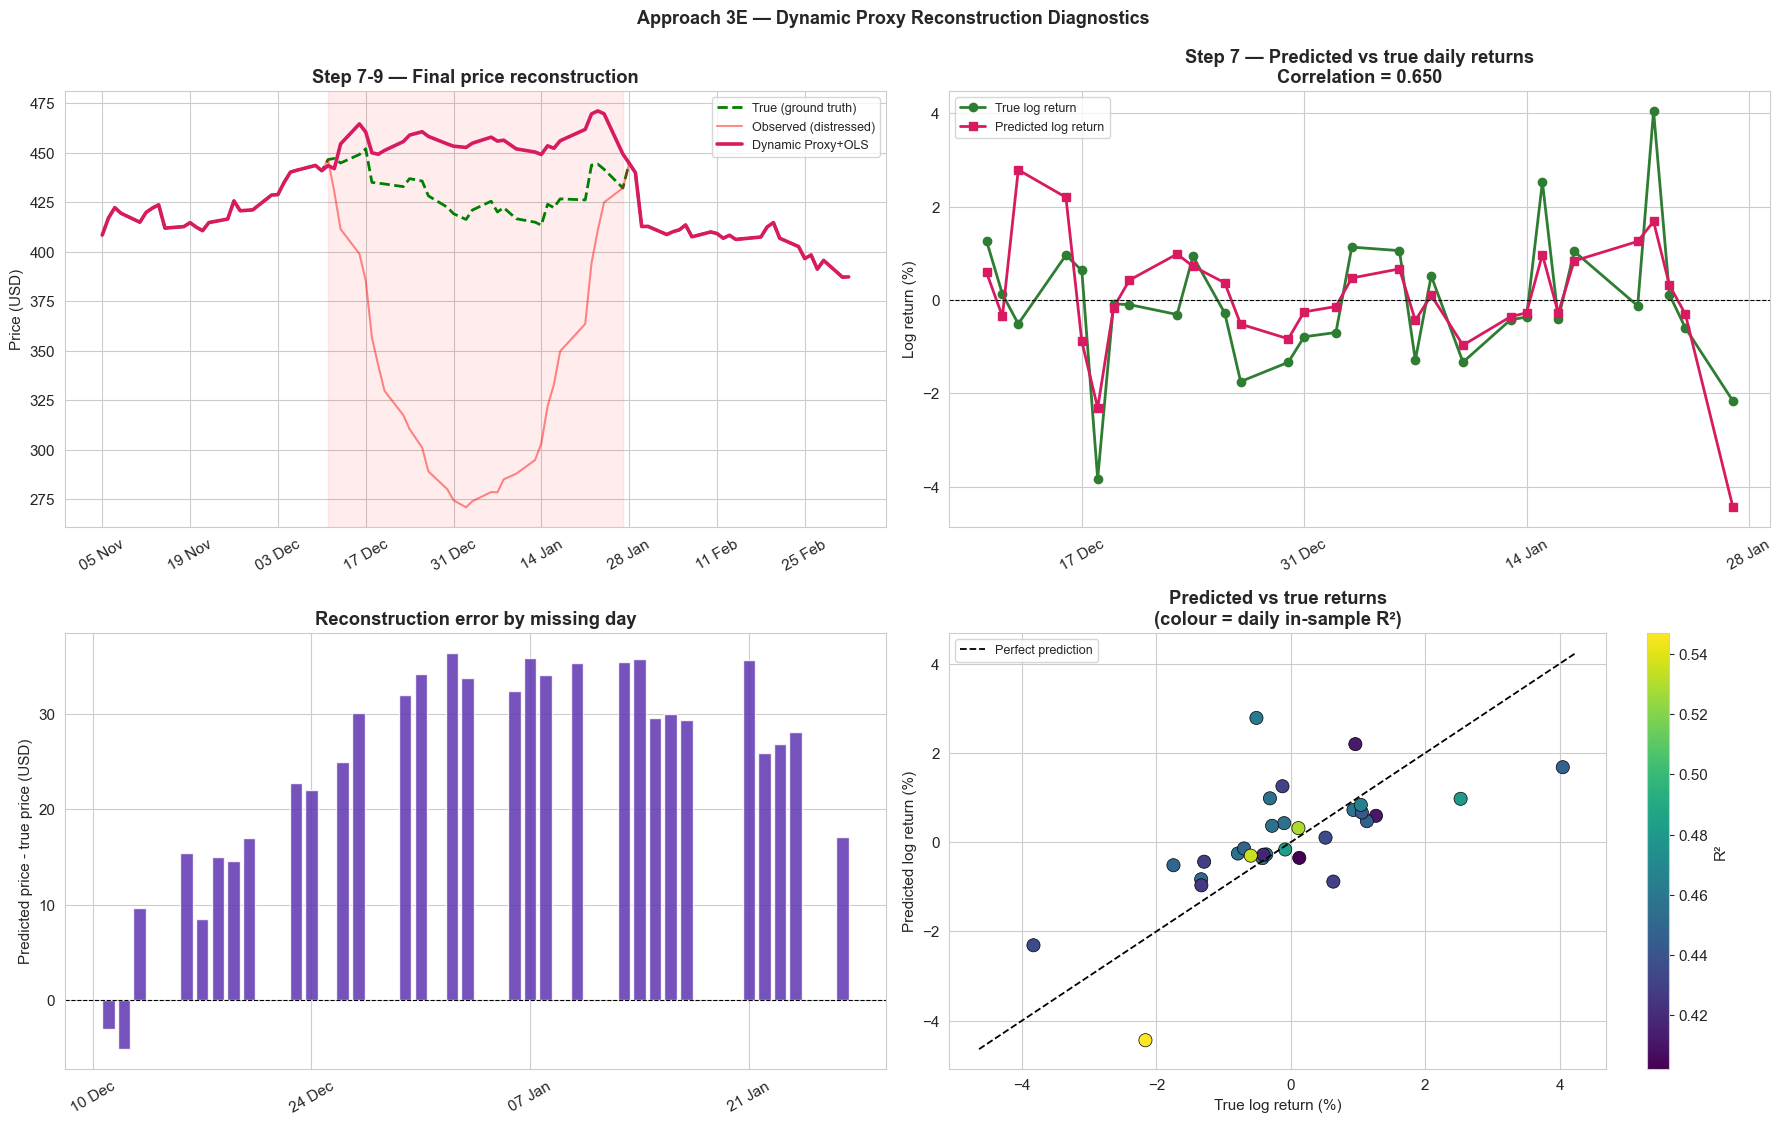

In [44]:
# Check how well the dynamic proxy method predicted returns and prices

pred_log_rets = proxy_daily_df['pred_log_ret'].values
true_log_rets = proxy_daily_df['true_log_ret'].values
pred_prices = recon['Dynamic Proxy+OLS'].iloc[DIST_START:DIST_END].values
true_prices = P['DIST_TRUE'].iloc[DIST_START:DIST_END].values
price_error = pred_prices - true_prices
ret_corr = np.corrcoef(pred_log_rets, true_log_rets)[0, 1]

print('Daily proxy diagnostics:')
print(proxy_daily_df[['date', 'peer_1', 'peer_2', 'peer_3', 'pred_log_ret', 'true_log_ret']]
      .head(8)
      .to_string(index=False))
print(f'\nReturn correlation during missing window: {ret_corr:.3f}')
print(f'Mean absolute price error during missing window: {np.mean(np.abs(price_error)):.3f}')

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
z0, z1 = DIST_START - 25, DIST_END + 25

# Panel A: compare the final reconstructed price path with truth
ax = axes[0, 0]
ax.plot(dates[z0:z1], P['DIST_TRUE'].iloc[z0:z1], 'g--', lw=2,
        label='True (ground truth)')
ax.plot(dates[z0:z1], P['DIST_OBS'].iloc[z0:z1], 'r-', lw=1.5, alpha=0.45,
        label='Observed (distressed)')
ax.plot(dates[z0:z1], recon['Dynamic Proxy+OLS'].iloc[z0:z1], color='#D81B60', lw=2.6,
        label='Dynamic Proxy+OLS')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
ax.set_title('Step 7-9 — Final price reconstruction', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Panel B: compare predicted and true daily returns
ax = axes[0, 1]
ax.plot(proxy_daily_df['date'], true_log_rets * 100, color='#2E7D32', lw=2,
        marker='o', label='True log return')
ax.plot(proxy_daily_df['date'], pred_log_rets * 100, color='#D81B60', lw=2,
        marker='s', label='Predicted log return')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title(f'Step 7 — Predicted vs true daily returns\nCorrelation = {ret_corr:.3f}',
             fontweight='bold')
ax.set_ylabel('Log return (%)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Panel C: show the price error on each missing day
ax = axes[1, 0]
ax.bar(proxy_daily_df['date'], price_error, color='#5E35B1', alpha=0.85)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Reconstruction error by missing day', fontweight='bold')
ax.set_ylabel('Predicted price - true price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Panel D: each point is one day; color shows how well the daily model fit
ax = axes[1, 1]
scatter = ax.scatter(true_log_rets * 100, pred_log_rets * 100,
                     c=proxy_daily_df['model_r2'], cmap='viridis', s=90,
                     edgecolor='black', linewidth=0.5)
mn = min(true_log_rets.min(), pred_log_rets.min()) * 100 - 0.2
mx = max(true_log_rets.max(), pred_log_rets.max()) * 100 + 0.2
ax.plot([mn, mx], [mn, mx], 'k--', lw=1.3, label='Perfect prediction')
ax.set_title('Predicted vs true returns\n(colour = daily in-sample R²)', fontweight='bold')
ax.set_xlabel('True log return (%)')
ax.set_ylabel('Predicted log return (%)')
ax.legend(fontsize=9)
plt.colorbar(scatter, ax=ax, label='R²')

plt.tight_layout()
plt.suptitle('Approach 3E — Dynamic Proxy Reconstruction Diagnostics',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

### How to Read the Approach 3E Diagnostics Graphs

This figure checks whether the dynamic proxy model is working day by day, not just in the final price chart.

### Panel A — Final Price Reconstruction

**What it shows**

The final dynamic-proxy price reconstruction against truth and the observed distressed series.

**Why we use it**

This is the headline result: did the dynamic proxy approach recover a plausible legacy path?

**How to read it**

1. Compare the reconstructed line with the dashed true line inside the distressed window.
2. Check whether the model tracks both the level and the shape.
3. Notice whether it drifts away near the end of the window.

### Panel B — Predicted vs True Daily Returns

**What it shows**

Daily predicted returns and true returns through the missing window.

**Why we use it**

The model predicts returns first and only then rebuilds prices. So this panel checks the prediction layer directly.

**How to read it**

1. Compare the timing of peaks and dips.
2. See whether the predicted returns get the sign and magnitude roughly right.
3. Higher correlation means the model is following the day-to-day direction better.

### Panel C — Reconstruction Error by Missing Day

**What it shows**

A bar chart of daily price error.

**Why we use it**

This reveals whether error is evenly spread or concentrated on a few especially hard days.

**How to read it**

1. Bars near zero are good.
2. Large positive bars mean overestimation; large negative bars mean underestimation.
3. Look for clustering of large errors on certain dates.

### Panel D — Predicted vs True Returns Scatter

**What it shows**

Each point is one missing day. The diagonal line is perfect prediction and the colour shows in-sample model fit.

**Why we use it**

This is a compact way to judge calibration, direction, and dispersion all at once.

**How to read it**

1. Points near the diagonal are better.
2. Points far above or below the diagonal indicate large return prediction error.
3. Use the colour to see whether days with stronger in-sample fit also tend to predict better out of sample.

**Debugger tip**

If Panel B looks weak and Panel D is widely scattered, the issue is usually the daily signal model itself, not just the final price compounding step.

## Approach 3F — Static vs Dynamic Proxy Selection

Now that we have both a **static** and a **dynamic** proxy engine, we can compare them directly.

### What is the difference?

- **Static proxy selection**: choose the proxy cluster once, right before the missing window begins, and keep the same peers for all missing days.
- **Dynamic proxy selection**: re-compute correlations, re-run clustering, and allow the chosen peer set to change each day.

### Why compare them side by side?

This comparison is useful because it separates two different modelling ideas:

1. **Model stability**: one fixed legacy peer basket may already describe the missing window well.
2. **Model adaptivity**: re-selecting peers each day may help if relationships genuinely drift during the event.

Under the restructuring assumption in this notebook, the key lesson is slightly different from before:

- the post-event stock is a new regime, so both methods are evaluated only on the **legacy** distressed window,
- if the legacy peer relationships remain fairly stable inside that window, the **static** method can outperform the dynamic one,
- if the legacy peer relationships are unstable, dynamic re-selection can still be preferable.

So the right choice is not "dynamic is always better". The right choice is: **use the least adaptive model that still tracks the legacy regime well.**

Static vs dynamic proxy metrics:
                     RMSE     MAE  Return Corr
Method                                        
Static Proxy+OLS   20.313  17.152        0.735
Dynamic Proxy+OLS  27.069  25.177        0.650

Static peer basket used throughout:
['MPWR', 'AAPL']


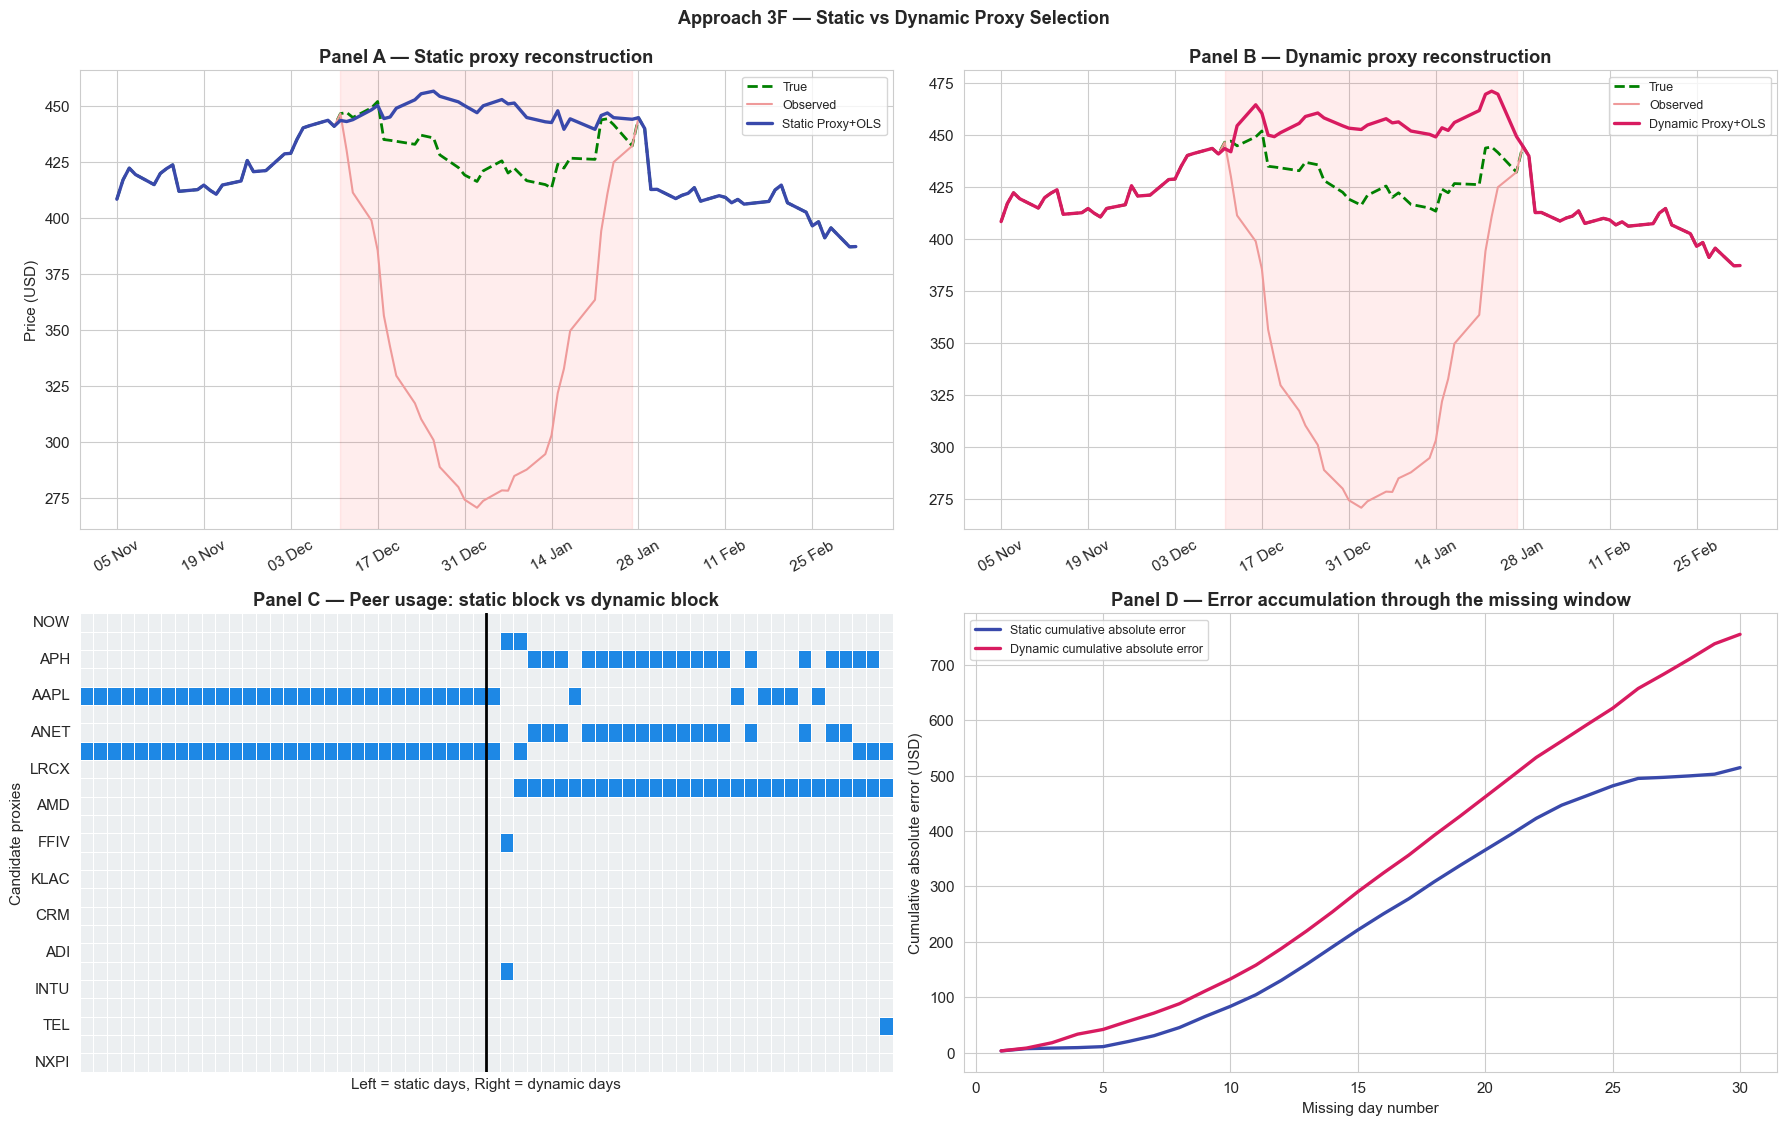

In [45]:
# Compare the static and dynamic proxy versions side by side

compare_true_prices = prices_df['DIST_TRUE'].iloc[DIST_START:DIST_END].values
static_prices = recon['Static Proxy+OLS'].iloc[DIST_START:DIST_END].values
dynamic_prices = recon['Dynamic Proxy+OLS'].iloc[DIST_START:DIST_END].values
compare_z0, compare_z1 = DIST_START - 25, DIST_END + 25

compare_df = pd.DataFrame({
    'Method': ['Static Proxy+OLS', 'Dynamic Proxy+OLS'],
    'RMSE': [
        np.sqrt(mean_squared_error(compare_true_prices, static_prices)),
        np.sqrt(mean_squared_error(compare_true_prices, dynamic_prices)),
    ],
    'MAE': [
        np.mean(np.abs(static_prices - compare_true_prices)),
        np.mean(np.abs(dynamic_prices - compare_true_prices)),
    ],
    'Return Corr': [
        np.corrcoef(static_proxy_df['pred_log_ret'], static_proxy_df['true_log_ret'])[0, 1],
        np.corrcoef(proxy_daily_df['pred_log_ret'], proxy_daily_df['true_log_ret'])[0, 1],
    ],
}).set_index('Method')

print('Static vs dynamic proxy metrics:')
print(compare_df.round(3).to_string())
print('\nStatic peer basket used throughout:')
print(static_result['static_setup']['peers'])

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
zoom_dates = dates[compare_z0:compare_z1]

# Panel A: static proxy reconstruction
ax = axes[0, 0]
ax.plot(zoom_dates, prices_df['DIST_TRUE'].iloc[compare_z0:compare_z1], 'g--', lw=2, label='True')
ax.plot(zoom_dates, prices_df['DIST_OBS'].iloc[compare_z0:compare_z1], color='#EF9A9A', lw=1.5, label='Observed')
ax.plot(zoom_dates, recon['Static Proxy+OLS'].iloc[compare_z0:compare_z1], color='#3949AB', lw=2.4,
        label='Static Proxy+OLS')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
ax.set_title('Panel A — Static proxy reconstruction', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Panel B: dynamic proxy reconstruction
ax = axes[0, 1]
ax.plot(zoom_dates, prices_df['DIST_TRUE'].iloc[compare_z0:compare_z1], 'g--', lw=2, label='True')
ax.plot(zoom_dates, prices_df['DIST_OBS'].iloc[compare_z0:compare_z1], color='#EF9A9A', lw=1.5, label='Observed')
ax.plot(zoom_dates, recon['Dynamic Proxy+OLS'].iloc[compare_z0:compare_z1], color='#D81B60', lw=2.4,
        label='Dynamic Proxy+OLS')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
ax.set_title('Panel B — Dynamic proxy reconstruction', fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Panel C: show which peers each version used
ax = axes[1, 0]
static_peer_map = pd.DataFrame(False, index=static_proxy_df['date'], columns=proxy_candidates)
dynamic_peer_map = pd.DataFrame(False, index=proxy_daily_df['date'], columns=proxy_candidates)
for _, row in static_proxy_df.iterrows():
    for col in ['peer_1', 'peer_2', 'peer_3']:
        if pd.notna(row[col]):
            static_peer_map.loc[row['date'], row[col]] = True
for _, row in proxy_daily_df.iterrows():
    for col in ['peer_1', 'peer_2', 'peer_3']:
        if pd.notna(row[col]):
            dynamic_peer_map.loc[row['date'], row[col]] = True
combined_peer_map = pd.concat(
    [static_peer_map.fillna(False).T.astype(int), dynamic_peer_map.fillna(False).T.astype(int)],
    axis=1,
)
separator = len(static_peer_map.index)
sns.heatmap(combined_peer_map, cmap=sns.color_palette(['#ECEFF1', '#1E88E5']),
            cbar=False, linewidths=0.4, linecolor='white', ax=ax)
ax.axvline(separator, color='black', lw=2)
ax.set_title('Panel C — Peer usage: static block vs dynamic block', fontweight='bold')
ax.set_xlabel('Left = static days, Right = dynamic days')
ax.set_ylabel('Candidate proxies')
ax.set_xticks([])

# Panel D: compare how quickly error builds up over time
ax = axes[1, 1]
static_cum_abs_err = np.cumsum(np.abs(static_prices - compare_true_prices))
dynamic_cum_abs_err = np.cumsum(np.abs(dynamic_prices - compare_true_prices))
missing_day_num = np.arange(1, len(compare_true_prices) + 1)
ax.plot(missing_day_num, static_cum_abs_err, color='#3949AB', lw=2.4,
        label='Static cumulative absolute error')
ax.plot(missing_day_num, dynamic_cum_abs_err, color='#D81B60', lw=2.4,
        label='Dynamic cumulative absolute error')
ax.set_title('Panel D — Error accumulation through the missing window', fontweight='bold')
ax.set_xlabel('Missing day number')
ax.set_ylabel('Cumulative absolute error (USD)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle('Approach 3F — Static vs Dynamic Proxy Selection',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

### How to Read the Approach 3F Graphs

This figure compares the static and dynamic proxy methods side by side.
Read it as: **does daily re-selection really improve the reconstruction, or does it just add complexity?**

### Panel A and Panel B — Static vs Dynamic Reconstruction

**What they show**

These two panels show the final reconstructed price paths for the static and dynamic methods separately.

**Why we use them**

It is easier to compare two methods when each gets its own panel against the same truth and observed series.

**How to read them**

1. Compare each method to the dashed true line in the distressed window.
2. Then compare the static and dynamic panels against each other.
3. Ask whether the extra adaptivity in the dynamic method actually improves the fit.

### Panel C — Peer Usage Heatmap

**What it shows**

A visual summary of which peers each method used across the missing days.

**Why we use it**

This panel makes the modelling difference concrete. Static should show one fixed block; dynamic may change across days.

**How to read it**

1. The left side corresponds to static selection, the right side to dynamic selection.
2. Repeated highlights in the same rows mean repeated use of the same peers.
3. Variation on the dynamic side shows changing peer choice over time.

### Panel D — Error Accumulation

**What it shows**

Cumulative absolute error for static and dynamic reconstruction.

**Why we use it**

This reveals whether one method makes many small mistakes that build up through the window.

**How to read it**

1. Lower is better.
2. A flatter line means errors are accumulating more slowly.
3. If dynamic starts worse but later catches up, or vice versa, the crossing pattern is important.

**Debugger tip**

If the dynamic method changes peers a lot but does not reduce cumulative error, the extra flexibility may just be adding noise.

## Approach 3G — Parameter Sweep for Lookback Window and Dendrogram Threshold

A model can look impressive with one set of parameters, but beginners should see that every tuning choice is a tradeoff.

### What are we sweeping?

- **Lookback window**: how many past trading days we use to estimate correlations and fit the OLS model.
- **Dendrogram threshold**: where we cut the clustering tree to define "same-cluster" peers.

### Intuition

- A **short** lookback reacts quickly to recent market changes, but may be noisy.
- A **long** lookback is more stable, but may average over relationships that are no longer current.
- A **low** threshold creates tighter clusters, so peer groups are more selective.
- A **high** threshold creates broader clusters, so peer groups are more inclusive.

The goal of the sweep is not just to find the numerically best combination. It is to understand **why** the reconstruction changes when we make the model more reactive or more conservative.

Parameter sweep summary (sorted by RMSE):
 lookback  threshold   RMSE    MAE  Price Corr  Return Corr  Avg R2
      120       0.25  9.176  8.350       0.734        0.721   0.496
       60       0.45 10.004  8.887       0.536        0.749   0.499
      120       0.45 10.893  8.795       0.649        0.764   0.533
      120       0.55 10.893  8.795       0.649        0.764   0.533
       60       0.55 13.007 11.060       0.475        0.773   0.516
      120       0.35 14.371 10.771       0.509        0.749   0.519
       60       0.35 24.076 20.800       0.207        0.651   0.516
       80       0.35 27.069 25.177       0.295        0.650   0.454

Best setting: lookback=120, threshold=0.25
Worst setting: lookback=80, threshold=0.25


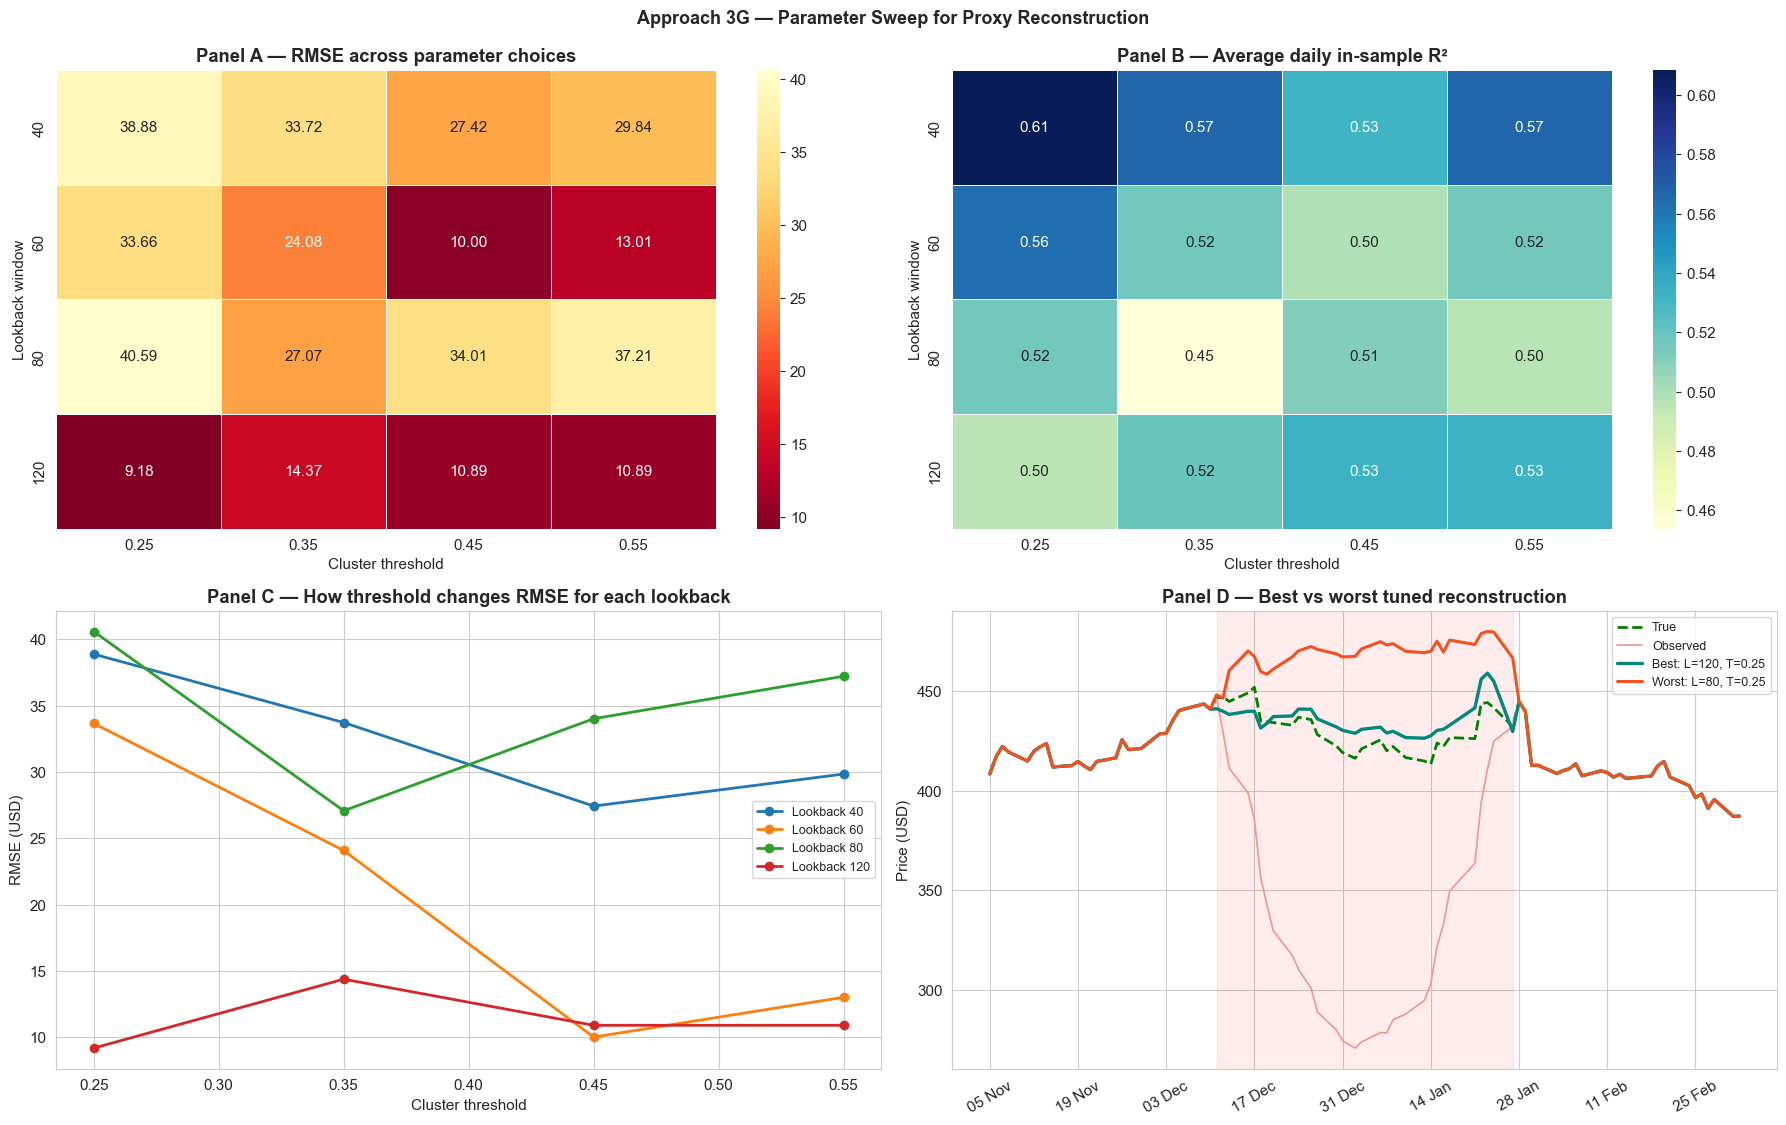

In [46]:
# Try several lookback windows and clustering thresholds

LOOKBACK_GRID = [40, 60, 80, 120]
THRESH_GRID = [0.25, 0.35, 0.45, 0.55]
sweep_true_period = P['DIST_TRUE'].iloc[DIST_START:DIST_END].values
sweep_z0, sweep_z1 = DIST_START - 25, DIST_END + 25

sweep_rows = []
sweep_results = {}

for lookback_val in LOOKBACK_GRID:
    for thr_val in THRESH_GRID:
        result = compute_proxy_reconstruction(
            mode='dynamic',
            lookback=lookback_val,
            cluster_thr=thr_val,
            max_peers=MAX_PEERS,
            min_peers=MIN_PEERS,
        )
        result_name = f'L={lookback_val}, T={thr_val:.2f}'
        series = result['series'].iloc[DIST_START:DIST_END].values
        daily_df = result['daily_df']

        # Save the whole result and also store a few summary metrics
        sweep_results[(lookback_val, thr_val)] = result
        sweep_rows.append({
            'lookback': lookback_val,
            'threshold': thr_val,
            'RMSE': np.sqrt(mean_squared_error(sweep_true_period, series)),
            'MAE': np.mean(np.abs(series - sweep_true_period)),
            'Price Corr': np.corrcoef(sweep_true_period, series)[0, 1],
            'Return Corr': np.corrcoef(daily_df['pred_log_ret'], daily_df['true_log_ret'])[0, 1],
            'Avg R2': daily_df['model_r2'].mean(),
            'Avg Peer Count': daily_df['peer_count'].mean(),
            'label': result_name,
        })

sweep_df = pd.DataFrame(sweep_rows).sort_values(['lookback', 'threshold'])
rmse_pivot = sweep_df.pivot(index='lookback', columns='threshold', values='RMSE')
r2_pivot = sweep_df.pivot(index='lookback', columns='threshold', values='Avg R2')

best_row = sweep_df.loc[sweep_df['RMSE'].idxmin()]
worst_row = sweep_df.loc[sweep_df['RMSE'].idxmax()]
best_result = sweep_results[(best_row['lookback'], best_row['threshold'])]
worst_result = sweep_results[(worst_row['lookback'], worst_row['threshold'])]

print('Parameter sweep summary (sorted by RMSE):')
print(sweep_df[['lookback', 'threshold', 'RMSE', 'MAE', 'Price Corr', 'Return Corr', 'Avg R2']]
      .sort_values('RMSE')
      .head(8)
      .round(3)
      .to_string(index=False))
print(f'\nBest setting: lookback={int(best_row["lookback"])}, threshold={best_row["threshold"]:.2f}')
print(f'Worst setting: lookback={int(worst_row["lookback"])}, threshold={worst_row["threshold"]:.2f}')

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

# Panel A: RMSE heatmap across parameter choices
ax = axes[0, 0]
sns.heatmap(rmse_pivot, annot=True, fmt='.2f', cmap='YlOrRd_r',
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Panel A — RMSE across parameter choices', fontweight='bold')
ax.set_xlabel('Cluster threshold')
ax.set_ylabel('Lookback window')

# Panel B: average in-sample R² heatmap
ax = axes[0, 1]
sns.heatmap(r2_pivot, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Panel B — Average daily in-sample R²', fontweight='bold')
ax.set_xlabel('Cluster threshold')
ax.set_ylabel('Lookback window')

# Panel C: line plot of RMSE as the threshold changes
ax = axes[1, 0]
for lookback_val in LOOKBACK_GRID:
    subset = sweep_df[sweep_df['lookback'] == lookback_val]
    ax.plot(subset['threshold'], subset['RMSE'], marker='o', lw=2,
            label=f'Lookback {lookback_val}')
ax.set_title('Panel C — How threshold changes RMSE for each lookback', fontweight='bold')
ax.set_xlabel('Cluster threshold')
ax.set_ylabel('RMSE (USD)')
ax.legend(fontsize=9)

# Panel D: compare the best and worst reconstructions
ax = axes[1, 1]
ax.plot(dates[sweep_z0:sweep_z1], P['DIST_TRUE'].iloc[sweep_z0:sweep_z1], 'g--', lw=2, label='True')
ax.plot(dates[sweep_z0:sweep_z1], P['DIST_OBS'].iloc[sweep_z0:sweep_z1], color='#EF9A9A', lw=1.3,
        label='Observed')
ax.plot(dates[sweep_z0:sweep_z1], best_result['series'].iloc[sweep_z0:sweep_z1], color='#00897B', lw=2.4,
        label=f'Best: L={int(best_row["lookback"])}, T={best_row["threshold"]:.2f}')
ax.plot(dates[sweep_z0:sweep_z1], worst_result['series'].iloc[sweep_z0:sweep_z1], color='#F4511E', lw=2.2,
        label=f'Worst: L={int(worst_row["lookback"])}, T={worst_row["threshold"]:.2f}')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
ax.set_title('Panel D — Best vs worst tuned reconstruction', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.suptitle('Approach 3G — Parameter Sweep for Proxy Reconstruction',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

### How to Read the Approach 3G Graphs

This figure explains the parameter sweep for the dynamic proxy model.
Read it as: **which settings work best, and how sensitive is the model to tuning choices?**

### Panel A — RMSE Heatmap

**What it shows**

A grid of reconstruction RMSE values for combinations of lookback window and cluster threshold.

**Why we use it**

This is the quickest way to see which parameter regions produce lower error.

**How to read it**

1. Lower RMSE is better.
2. Scan for the strongest cells rather than focusing on one number only.
3. Look for stable low-error regions, not just one lucky setting.

### Panel B — Average Daily In-Sample R²

**What it shows**

A heatmap of average regression fit across the missing days.

**Why we use it**

This tells you how well the daily models fit their training data, which is useful but not the same as final reconstruction quality.

**How to read it**

1. Higher is better for in-sample fit.
2. Compare this panel with Panel A.
3. If high R² does not align with low RMSE, good training fit is not translating into better reconstruction.

### Panel C — Threshold Sensitivity Curves

**What it shows**

Lines showing how RMSE changes as the cluster threshold changes for each lookback choice.

**Why we use it**

This panel makes the tradeoff more intuitive than a heatmap alone.

**How to read it**

1. Follow one line at a time for a fixed lookback.
2. Check whether RMSE is stable or highly sensitive to threshold changes.
3. Flatter curves mean more robust tuning; steep curves mean fragile tuning.

### Panel D — Best vs Worst Reconstruction

**What it shows**

A direct visual comparison between the best and worst parameter settings found in the sweep.

**Why we use it**

This helps connect abstract tuning numbers back to actual reconstructed price paths.

**How to read it**

1. Compare both lines with the dashed true path.
2. Notice whether the worst setting misses the shape, level, or both.
3. Use this panel to judge whether the tuning differences are economically large or only numerically small.

**Debugger tip**

If Panel B looks strong but Panel D still looks poor, the model may be overfitting the training windows rather than improving the actual missing-window reconstruction.

## Approach 3H — Feature Selection Beyond Raw Returns, with Raw and PCA Proxy Variants

So far the proxy models used the peers' **daily returns** directly. That is often a good baseline, but it is also narrow.

### Why go beyond raw returns?

Two stocks can be related in ways that a single-day return does not fully capture.
For example, a peer may help explain DIST because it shares:

- short-term momentum over the last 3 to 10 days,
- recent volatility regime,
- drawdown stress patterns,
- downside-only risk behaviour,
- relative mispricing versus the rest of the selected proxy cluster.

Instead of feeding only one predictor per peer, we can build a **feature set** for the peers inside DIST's cluster.

### Feature Engineering Used Here

For each selected peer, we now create:

- `ret_1d`: today's log return
- `ret_3d`, `ret_5d`, `ret_10d`: cumulative multi-day log returns
- `vol_5d`, `vol_10d`: rolling volatility
- `drawdown_5d`, `drawdown_10d`: rolling drawdown from a pseudo-price path built from returns
- `downside_semivol_5d`, `downside_semivol_10d`: rolling downside semivolatility
- `spread_mean_1d`, `spread_mean_3d`, `spread_mean_5d`: peer return spread versus the cluster mean

### Why feature selection?

If we keep every feature from every peer, we quickly create a noisy, redundant predictor matrix.
So we first rank features by how strongly they relate to the legacy DIST return inside the training window, then keep only the top few.

### Raw-feature regression vs PCA-compressed regression

After feature selection, we compare two ways to use those inputs:

- **Feature Raw Proxy+OLS**: regress directly on the selected, standardised features
- **Feature PCA Proxy+OLS**: first compress the selected features into a few orthogonal components, then regress on those components

In beginner terms:

- raw-feature regression asks: **can we use the best engineered inputs directly?**
- PCA asks: **are those inputs redundant enough that a smaller compressed representation is safer?**

The plots below show both models so we can see **when PCA helps and when it just throws away useful detail.**

Feature proxy comparison: raw regression vs PCA compression
                         RMSE     MAE  Return Corr
Method                                            
Feature Raw Proxy+OLS  12.533  11.627        0.684
Feature PCA Proxy+OLS  23.107  21.485        0.680

First 8 days of the raw-feature model:
      date peer_1 peer_2 peer_3  n_components  model_r2
2024-12-11   MPWR   AAPL   None             6     0.424
2024-12-12   CDNS   ORCL   FFIV             6     0.428
2024-12-13   AVGO   MPWR   CDNS             6     0.470
2024-12-16   MPWR   AVGO   ANET             6     0.447
2024-12-17   MPWR   AVGO   ANET             6     0.456
2024-12-18   AVGO   ANET    APH             6     0.401
2024-12-19   MPWR   AVGO    APH             6     0.496
2024-12-20   MPWR   AVGO    APH             6     0.499

First 8 days of the PCA-feature model:
      date peer_1 peer_2 peer_3  n_components  explained_var  model_r2
2024-12-11   MPWR   AAPL   None             3          0.944     0.423
2024-12-12

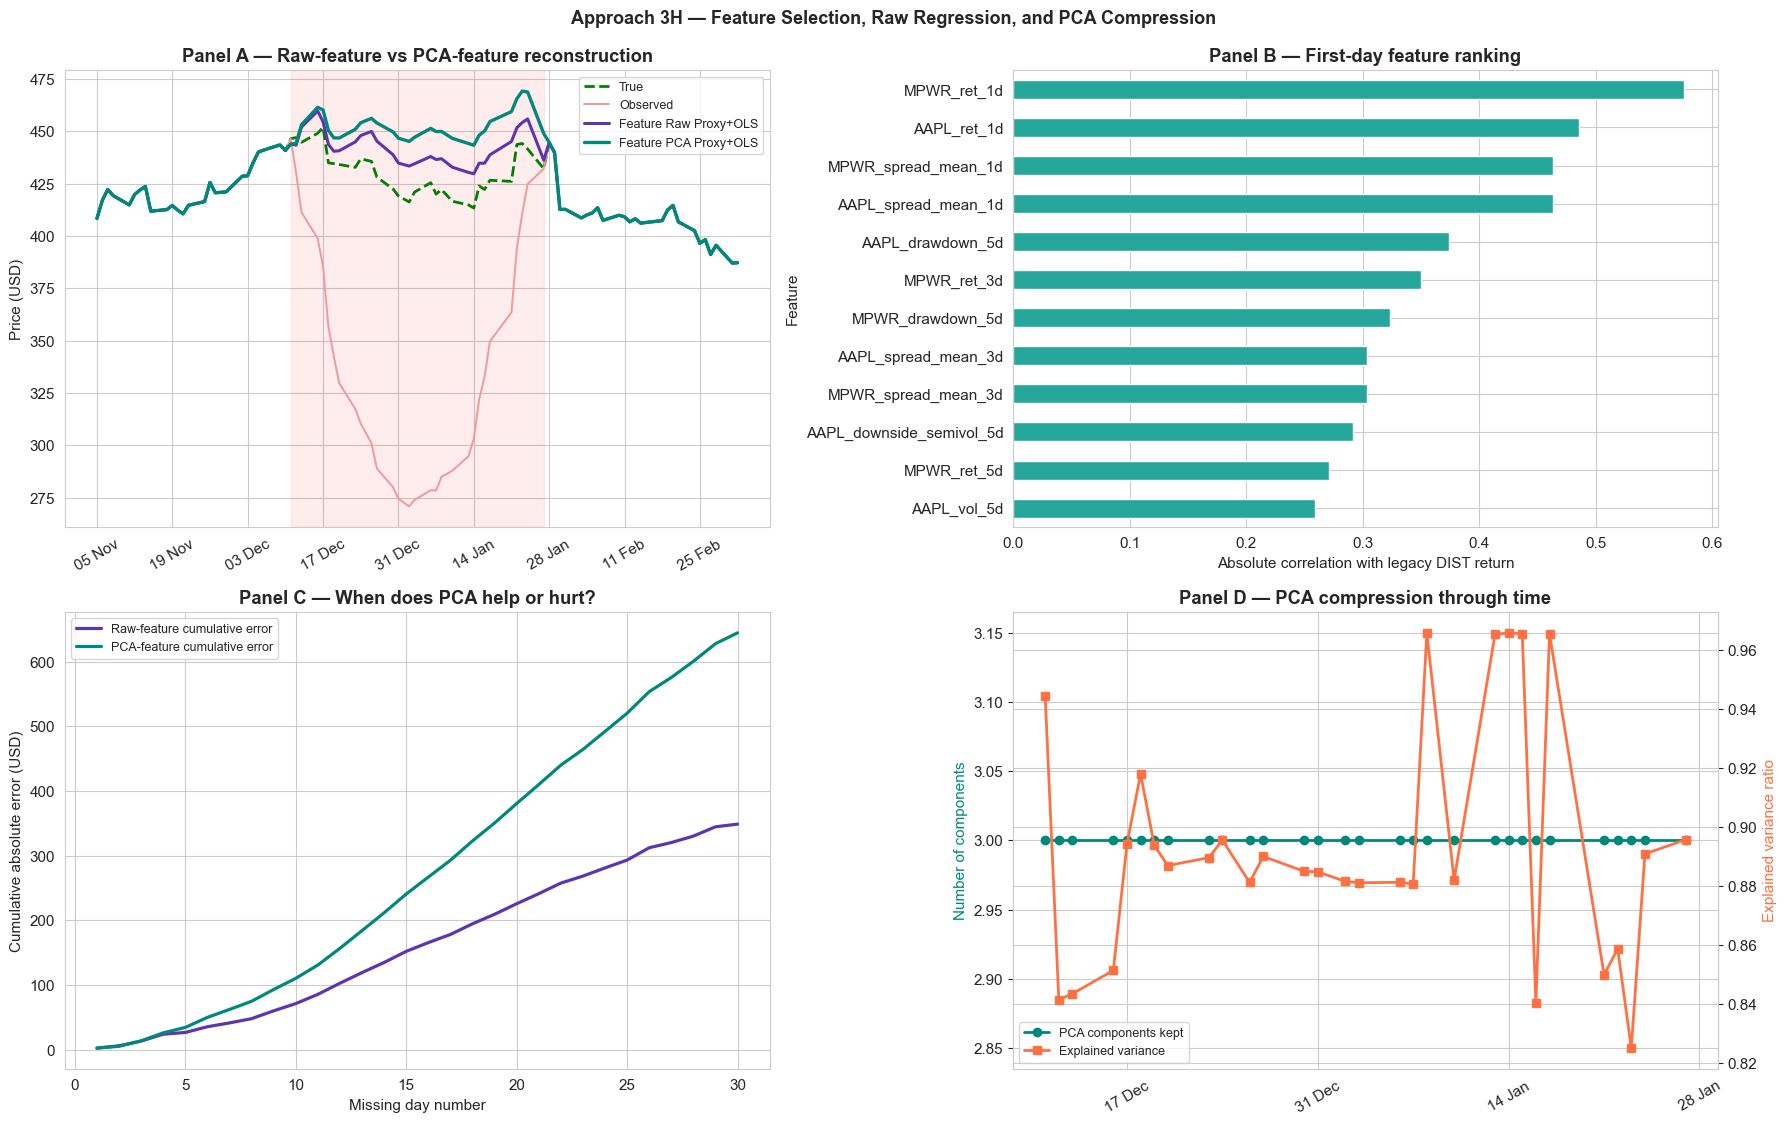

In [47]:
# Compare the richer feature model with and without PCA compression

feature_raw_prices = recon['Feature Raw Proxy+OLS'].iloc[DIST_START:DIST_END].values
feature_pca_prices = recon['Feature PCA Proxy+OLS'].iloc[DIST_START:DIST_END].values
feature_true = P['DIST_TRUE'].iloc[DIST_START:DIST_END].values
feature_raw_error = feature_raw_prices - feature_true
feature_pca_error = feature_pca_prices - feature_true
feature_raw_ret_corr = np.corrcoef(feature_raw_df['pred_log_ret'], feature_raw_df['true_log_ret'])[0, 1]
feature_pca_ret_corr = np.corrcoef(feature_pca_df['pred_log_ret'], feature_pca_df['true_log_ret'])[0, 1]
feature_rank_first_day = feature_pca_result['first_day_feature_scores'].head(12)

feature_compare_df = pd.DataFrame({
    'Method': ['Feature Raw Proxy+OLS', 'Feature PCA Proxy+OLS'],
    'RMSE': [
        np.sqrt(mean_squared_error(feature_true, feature_raw_prices)),
        np.sqrt(mean_squared_error(feature_true, feature_pca_prices)),
    ],
    'MAE': [
        np.mean(np.abs(feature_raw_error)),
        np.mean(np.abs(feature_pca_error)),
    ],
    'Return Corr': [feature_raw_ret_corr, feature_pca_ret_corr],
}).set_index('Method')

print('Feature proxy comparison: raw regression vs PCA compression')
print(feature_compare_df.round(3).to_string())
print('\nFirst 8 days of the raw-feature model:')
print(feature_raw_df[['date', 'peer_1', 'peer_2', 'peer_3', 'n_components', 'model_r2']]
      .head(8)
      .round(3)
      .to_string(index=False))
print('\nFirst 8 days of the PCA-feature model:')
print(feature_pca_df[['date', 'peer_1', 'peer_2', 'peer_3', 'n_components', 'explained_var', 'model_r2']]
      .head(8)
      .round(3)
      .to_string(index=False))
print('\nTop first-day feature scores:')
print(feature_rank_first_day.round(3).to_string())

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
feature_z0, feature_z1 = DIST_START - 25, DIST_END + 25
feature_zoom_dates = dates[feature_z0:feature_z1]

# Panel A: compare the two reconstructed price paths
ax = axes[0, 0]
ax.plot(feature_zoom_dates, P['DIST_TRUE'].iloc[feature_z0:feature_z1], 'g--', lw=2, label='True')
ax.plot(feature_zoom_dates, P['DIST_OBS'].iloc[feature_z0:feature_z1], color='#EF9A9A', lw=1.4, label='Observed')
ax.plot(feature_zoom_dates, recon['Feature Raw Proxy+OLS'].iloc[feature_z0:feature_z1], color='#5E35B1', lw=2.2,
        label='Feature Raw Proxy+OLS')
ax.plot(feature_zoom_dates, recon['Feature PCA Proxy+OLS'].iloc[feature_z0:feature_z1], color='#00897B', lw=2.4,
        label='Feature PCA Proxy+OLS')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
ax.set_title('Panel A — Raw-feature vs PCA-feature reconstruction', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Panel B: show which engineered features looked strongest on day 1
ax = axes[0, 1]
feature_rank_first_day.sort_values().plot(kind='barh', color='#26A69A', ax=ax)
ax.set_title('Panel B — First-day feature ranking', fontweight='bold')
ax.set_xlabel('Absolute correlation with legacy DIST return')
ax.set_ylabel('Feature')

# Panel C: compare how error builds up over time
ax = axes[1, 0]
missing_day_num = np.arange(1, len(feature_true) + 1)
ax.plot(missing_day_num, np.cumsum(np.abs(feature_raw_error)), color='#5E35B1', lw=2.3,
        label='Raw-feature cumulative error')
ax.plot(missing_day_num, np.cumsum(np.abs(feature_pca_error)), color='#00897B', lw=2.3,
        label='PCA-feature cumulative error')
ax.set_title('Panel C — When does PCA help or hurt?', fontweight='bold')
ax.set_xlabel('Missing day number')
ax.set_ylabel('Cumulative absolute error (USD)')
ax.legend(fontsize=9)

# Panel D: track how many PCA components were kept each day
ax = axes[1, 1]
ax.plot(feature_pca_df['date'], feature_pca_df['n_components'], color='#00897B', lw=2,
        marker='o', label='PCA components kept')
ax2 = ax.twinx()
ax2.plot(feature_pca_df['date'], feature_pca_df['explained_var'], color='#FF7043', lw=2,
         marker='s', label='Explained variance')
ax.set_title('Panel D — PCA compression through time', fontweight='bold')
ax.set_ylabel('Number of components', color='#00897B')
ax2.set_ylabel('Explained variance ratio', color='#FF7043')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=9, loc='lower left')

plt.tight_layout()
plt.suptitle('Approach 3H — Feature Selection, Raw Regression, and PCA Compression',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

### How to Read the Approach 3H Graphs — Beginner Guide

This cell explains **what each panel is trying to teach you**, **why we plot it**, and **how to read it correctly**.

A useful mindset is this:

- Panel A asks: **which method gives the better reconstructed price path?**
- Panel B asks: **which engineered features seem most informative?**
- Panel C asks: **does PCA reduce error or remove useful signal?**
- Panel D asks: **how aggressively is PCA compressing the feature space over time?**

### Panel A — Raw-feature vs PCA-feature reconstruction

**What it shows**

This panel overlays four price paths around the distressed window:

- `True`: the clean legacy reference path (`DIST_TRUE`)
- `Observed`: the corrupted distressed series (`DIST_OBS`)
- `Feature Raw Proxy+OLS`: reconstruction using the selected engineered features directly
- `Feature PCA Proxy+OLS`: reconstruction after compressing the selected features with PCA

**Why we use it**

This is the most direct visual test of whether the richer feature model is actually helping.
Instead of staring only at regression statistics, we look at the final object we care about: the reconstructed price path.

**How to read it**

1. First compare both reconstructed lines to the dashed `True` line.
2. Then check whether the raw-feature model or the PCA-feature model stays closer through the full missing window, not just on one day.
3. Look especially at the red shaded distressed region, because that is the period we are trying to reconstruct.
4. Notice whether one method gets the **shape** right but the **level** wrong, or vice versa.

**What a good panel looks like**

- the reconstruction tracks the dashed true line closely
- it follows the same rises and falls
- it does not drift far away by the end of the window

**What a bad panel looks like**

- the line is systematically too high or too low
- it misses turning points
- the gap versus truth gets wider as time passes

**Debugger tip**

If both models are far from the true line, the problem may not be PCA at all. The issue may be poor peer selection, weak features, or unstable regression coefficients earlier in the pipeline.

### Panel B — First-day feature ranking

**What it shows**

This is a horizontal bar chart of the strongest engineered features on the **first missing day**. Each bar measures the absolute correlation between a candidate feature and the target DIST return inside the training window.

Examples of features include:

- multi-day returns such as `ret_3d` or `ret_10d`
- rolling volatility such as `vol_5d`
- drawdown features
- downside semivolatility features
- spread-versus-cluster-mean features

**Why we use it**

When we build many features, we need a way to see which ones actually carry signal.
This panel makes feature selection interpretable. It answers: **which inputs looked most useful before we fit the model?**

**How to read it**

1. Longer bars mean the feature had a stronger linear relationship with the DIST target return in the training sample.
2. The chart uses **absolute** correlation, so both strongly positive and strongly negative relationships appear important.
3. Read the feature names carefully: they tell you whether the signal is about momentum, volatility, drawdown, downside risk, or relative spread.
4. Check whether the strongest features come from one peer only or from several peers.

**What to look for**

- If many top features come from the same peer, that peer may dominate the model.
- If the top features are all very similar, PCA may help by compressing redundancy.
- If the top features are diverse, PCA may remove useful detail if it compresses too much.

**Debugger tip**

If the rankings look unstable day to day, or if obviously irrelevant features dominate, the issue may be the feature-engineering choices, lookback window, or noisy peer set rather than the regression step itself.

### Panel C — When does PCA help or hurt?

**What it shows**

This panel plots **cumulative absolute error** across the missing days for:

- the raw-feature model
- the PCA-feature model

Instead of showing only the final error, it shows how error **builds up over time**.

**Why we use it**

A reconstruction method can look fine on average but fail progressively as small daily mistakes compound into a large final price error.
This panel helps us see whether PCA makes the model more stable over the whole window.

**How to read it**

1. Start at the left: both methods usually begin with low accumulated error.
2. As you move right, watch which line rises faster.
3. The lower line is better because it means less total reconstruction error has accumulated so far.
4. If the PCA line stays below the raw-feature line, PCA is helping.
5. If the PCA line rises above the raw-feature line, PCA is likely throwing away useful information.

**What patterns mean**

- **Lines stay close together**: PCA has little practical effect.
- **PCA line clearly below raw line**: compression is improving stability.
- **PCA line clearly above raw line**: compression is too aggressive or the raw features contain useful detail.
- **Lines cross**: one method may be better early in the window and worse later.

**Debugger tip**

If both curves explode upward quickly, that often means prediction errors are compounding day by day. In that case, inspect the daily selected peers, feature quality, and model fit rather than only the final price chart.

### Panel D — PCA compression through time

**What it shows**

This panel has two y-axes:

- the green line shows how many PCA components were kept each day
- the orange line shows how much total variance those components explained

So this panel tells you **how much the model compressed the feature space** on each missing day.

**Why we use it**

PCA is not just a black-box transformation. We want to know whether it is doing light compression or heavy compression, and whether that amount changes over time.

**How to read it**

1. Read the green line first: fewer components means stronger compression.
2. Read the orange line next: higher explained variance means the kept components still retain most of the information in the original selected features.
3. The best case is usually: **few components, high explained variance**.
4. If very few components explain only modest variance, the model may be oversimplifying the feature set.

**What patterns mean**

- **Stable component count and stable explained variance**: the feature space is structurally consistent across the missing window.
- **Jumping component count**: the feature set becomes more or less redundant over time.
- **High explained variance with low component count**: features are overlapping strongly, so PCA is useful.
- **Low explained variance unless many components are kept**: the selected features carry distinct information, so PCA may be less helpful.

**Debugger tip**

If the explained variance drops sharply on the same days that prediction quality worsens, PCA compression may be too strong for those days.

### How to use all four panels together

Read the panels in this order:

1. **Panel B first**: understand what kinds of features the model thinks are important.
2. **Panel D second**: see how much PCA compresses those features.
3. **Panel C third**: check whether that compression reduces or increases cumulative error.
4. **Panel A last**: verify whether the final reconstructed price path actually improved in the way you expected.

That sequence helps you debug the logic from **inputs → compression → accumulated error → final reconstruction result**.

## Approach 3I — Feature Tuning Sweep and When PCA Helps

Now we tune the **feature-model** hyperparameters the same way we previously tuned lookback and clustering.

### What are we sweeping?

- `MAX_SELECTED_FEATURES`: how many top-ranked engineered features we keep
- `PCA_VAR_THRESHOLD`: how much variance PCA should retain before stopping
- `PCA_MAX_COMPONENTS`: the hard cap on the number of PCA components

### Why this matters

This sweep answers two practical questions:

1. **Do richer engineered features help if we use them directly?**
2. **At what point does PCA start helping by compressing redundancy instead of discarding useful signal?**

If the raw-feature model improves as we add more features but the PCA model degrades, then compression may be too aggressive.
If the raw-feature model worsens while PCA stays stable, then PCA is acting as a useful regulariser.

Best raw-feature configuration:
max_features    10.0000
RMSE             5.9352
MAE              5.0155

Best PCA configuration:
max_features          8.0000
pca_var_threshold     0.9500
pca_components        4.0000
RMSE                 12.7381
MAE                  11.8108

Raw sweep table:
 max_features    RMSE     MAE
            4 18.3077 15.8272
            6 12.5330 11.6273
            8  7.2151  6.1926
           10  5.9352  5.0155

Top PCA sweep rows:
 max_features  pca_var_threshold  pca_components    RMSE     MAE
            8               0.95               4 12.7381 11.8108
            8               0.90               4 12.9411 11.9998
           10               0.95               4 14.2999 13.2545
           10               0.90               4 14.2999 13.2545
            8               0.80               4 14.5469 12.9781
            8               0.95               3 14.8163 13.3517
            8               0.90               3 14.8163 13.3517
            8    

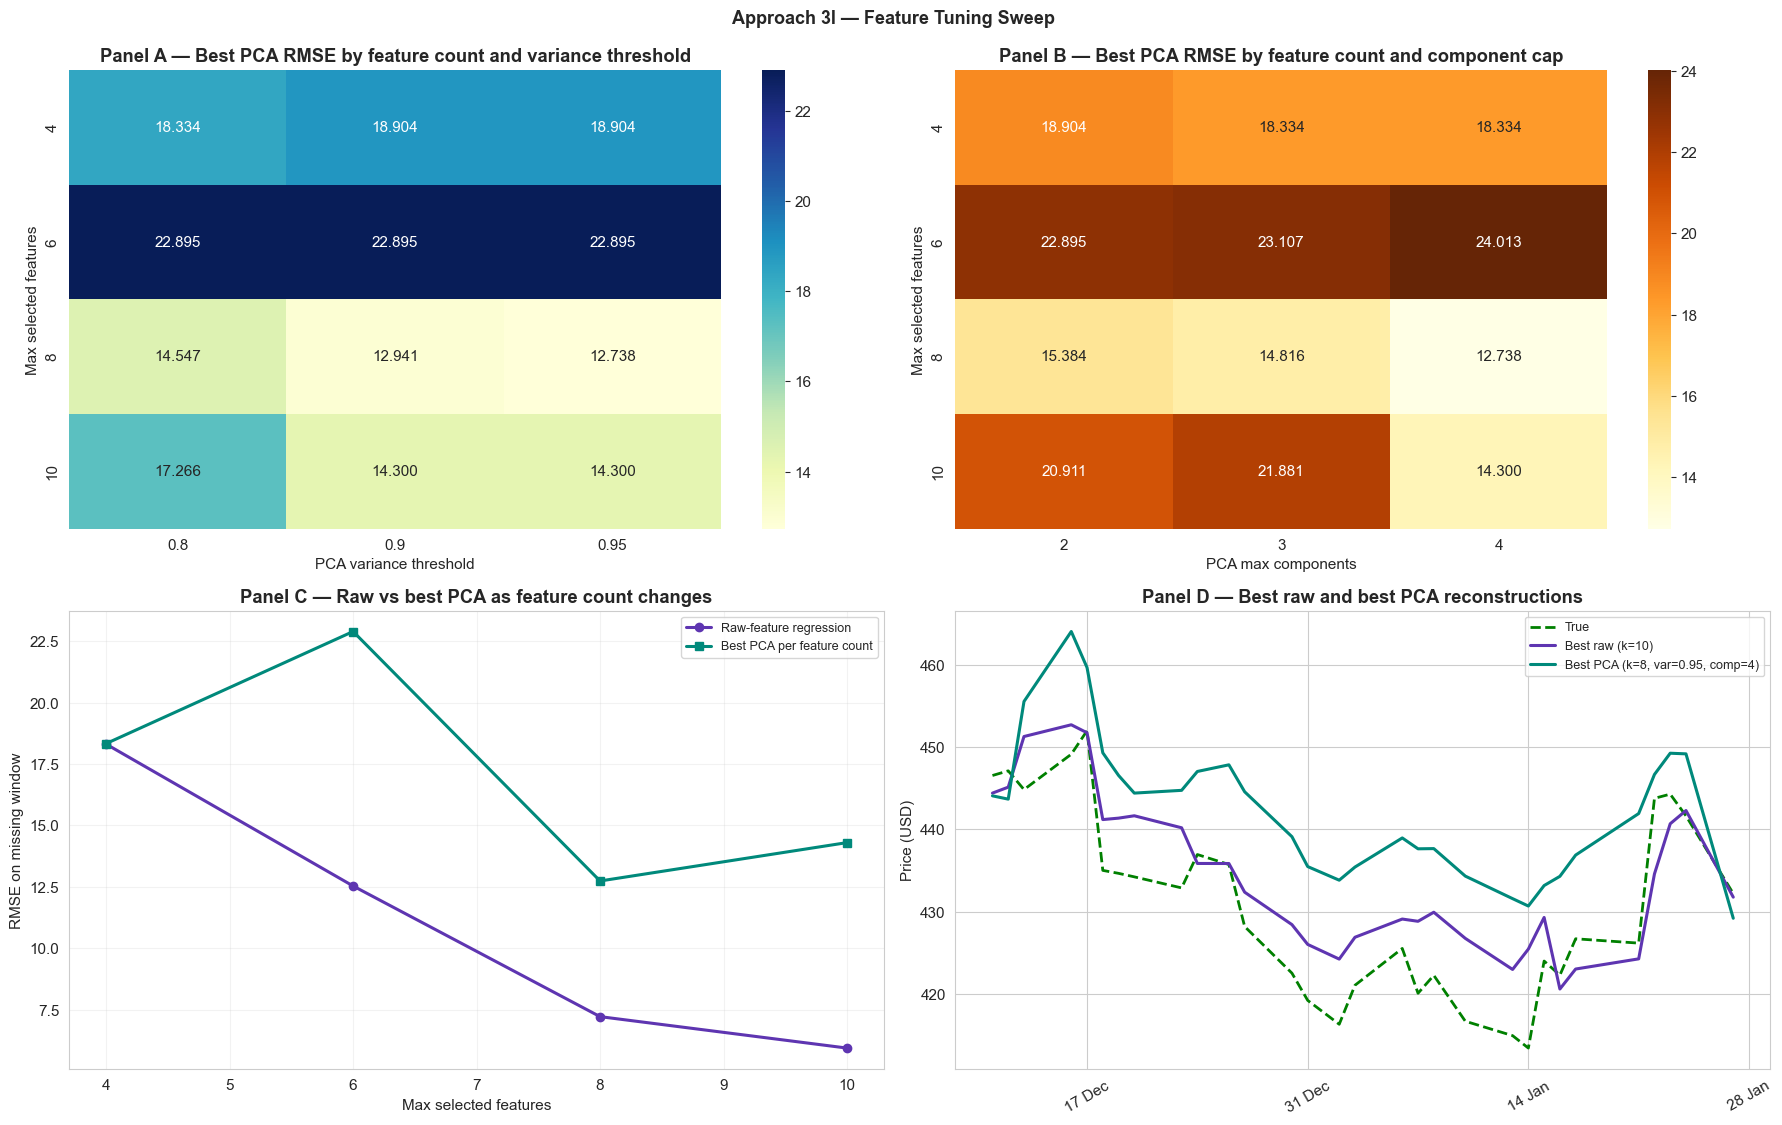

In [48]:
# Sweep the feature-model settings to see when PCA helps

raw_sweep_rows = []
for feature_count in FEATURE_COUNT_GRID:
    sweep_result = compute_feature_proxy_reconstruction(
        use_pca=False,
        lookback=LOOKBACK,
        cluster_thr=CLUSTER_THR,
        max_peers=MAX_PEERS,
        min_peers=MIN_PEERS,
        max_selected_features=feature_count,
    )
    sweep_prices = sweep_result['series'].iloc[DIST_START:DIST_END].values
    raw_sweep_rows.append({
        'max_features': feature_count,
        'RMSE': np.sqrt(mean_squared_error(feature_true, sweep_prices)),
        'MAE': np.mean(np.abs(sweep_prices - feature_true)),
    })
raw_sweep_df = pd.DataFrame(raw_sweep_rows)

pca_sweep_rows = []
for feature_count in FEATURE_COUNT_GRID:
    for pca_var in PCA_VAR_GRID:
        for pca_components in PCA_COMPONENT_GRID:
            sweep_result = compute_feature_proxy_reconstruction(
                use_pca=True,
                lookback=LOOKBACK,
                cluster_thr=CLUSTER_THR,
                max_peers=MAX_PEERS,
                min_peers=MIN_PEERS,
                max_selected_features=feature_count,
                pca_var_threshold=pca_var,
                pca_max_components=pca_components,
            )
            sweep_prices = sweep_result['series'].iloc[DIST_START:DIST_END].values
            pca_sweep_rows.append({
                'max_features': feature_count,
                'pca_var_threshold': pca_var,
                'pca_components': pca_components,
                'RMSE': np.sqrt(mean_squared_error(feature_true, sweep_prices)),
                'MAE': np.mean(np.abs(sweep_prices - feature_true)),
            })
pca_sweep_df = pd.DataFrame(pca_sweep_rows)

best_raw_row = raw_sweep_df.loc[raw_sweep_df['RMSE'].idxmin()]
best_pca_row = pca_sweep_df.loc[pca_sweep_df['RMSE'].idxmin()]
pca_by_var = pca_sweep_df.groupby(['max_features', 'pca_var_threshold'])['RMSE'].min().unstack()
pca_by_components = pca_sweep_df.groupby(['max_features', 'pca_components'])['RMSE'].min().unstack()
best_pca_by_feature_count = pca_sweep_df.groupby('max_features')['RMSE'].min().reset_index()

# Re-run the best settings so we can plot them cleanly
best_pca_sweep_result = compute_feature_proxy_reconstruction(
    use_pca=True,
    lookback=LOOKBACK,
    cluster_thr=CLUSTER_THR,
    max_peers=MAX_PEERS,
    min_peers=MIN_PEERS,
    max_selected_features=int(best_pca_row['max_features']),
    pca_var_threshold=float(best_pca_row['pca_var_threshold']),
    pca_max_components=int(best_pca_row['pca_components']),
)
best_raw_sweep_result = compute_feature_proxy_reconstruction(
    use_pca=False,
    lookback=LOOKBACK,
    cluster_thr=CLUSTER_THR,
    max_peers=MAX_PEERS,
    min_peers=MIN_PEERS,
    max_selected_features=int(best_raw_row['max_features']),
)

print('Best raw-feature configuration:')
print(best_raw_row.round(4).to_string())
print('\nBest PCA configuration:')
print(best_pca_row.round(4).to_string())
print('\nRaw sweep table:')
print(raw_sweep_df.round(4).to_string(index=False))
print('\nTop PCA sweep rows:')
print(pca_sweep_df.sort_values('RMSE').head(10).round(4).to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

# Panel A: best PCA RMSE by feature count and variance target
ax = axes[0, 0]
sns.heatmap(pca_by_var, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax)
ax.set_title('Panel A — Best PCA RMSE by feature count and variance threshold', fontweight='bold')
ax.set_xlabel('PCA variance threshold')
ax.set_ylabel('Max selected features')

# Panel B: best PCA RMSE by feature count and component cap
ax = axes[0, 1]
sns.heatmap(pca_by_components, annot=True, fmt='.3f', cmap='YlOrBr', ax=ax)
ax.set_title('Panel B — Best PCA RMSE by feature count and component cap', fontweight='bold')
ax.set_xlabel('PCA max components')
ax.set_ylabel('Max selected features')

# Panel C: raw model versus the best PCA setting at each feature count
ax = axes[1, 0]
ax.plot(raw_sweep_df['max_features'], raw_sweep_df['RMSE'], color='#5E35B1', marker='o', lw=2.2,
        label='Raw-feature regression')
ax.plot(best_pca_by_feature_count['max_features'], best_pca_by_feature_count['RMSE'],
        color='#00897B', marker='s', lw=2.2, label='Best PCA per feature count')
ax.set_title('Panel C — Raw vs best PCA as feature count changes', fontweight='bold')
ax.set_xlabel('Max selected features')
ax.set_ylabel('RMSE on missing window')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

# Panel D: compare the best raw and best PCA reconstructions
ax = axes[1, 1]
ax.plot(dates[DIST_START:DIST_END], P['DIST_TRUE'].iloc[DIST_START:DIST_END], 'g--', lw=2, label='True')
ax.plot(dates[DIST_START:DIST_END], best_raw_sweep_result['series'].iloc[DIST_START:DIST_END],
        color='#5E35B1', lw=2.2, label=f'Best raw (k={int(best_raw_row["max_features"])})')
ax.plot(dates[DIST_START:DIST_END], best_pca_sweep_result['series'].iloc[DIST_START:DIST_END],
        color='#00897B', lw=2.2,
        label=(
            f'Best PCA (k={int(best_pca_row["max_features"])}, '
            f'var={best_pca_row["pca_var_threshold"]:.2f}, '
            f'comp={int(best_pca_row["pca_components"])})'
        ))
ax.set_title('Panel D — Best raw and best PCA reconstructions', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.suptitle('Approach 3I — Feature Tuning Sweep', fontweight='bold', fontsize=13, y=1.02)
plt.show()

### How to Read the Approach 3I Graphs

This figure explains the feature-model tuning sweep.
Read it as: **how many engineered features should we keep, and when does PCA compression help?**

### Panel A — Best PCA RMSE by Feature Count and Variance Threshold

**What it shows**

A heatmap of the best RMSE values for different combinations of feature count and PCA variance target.

**Why we use it**

It shows whether keeping more variance always helps, or whether there is a useful middle ground.

**How to read it**

1. Lower RMSE is better.
2. Compare rows to see whether adding more selected features helps.
3. Compare columns to see whether tighter or looser PCA retention works better.

### Panel B — Best PCA RMSE by Feature Count and Component Cap

**What it shows**

A heatmap of best RMSE values for different feature counts and maximum PCA component limits.

**Why we use it**

This tells you whether the model benefits from strong compression or needs more components to keep enough signal.

**How to read it**

1. Lower cells are better.
2. If performance improves with more allowed components, PCA may need more room to preserve structure.
3. If low component caps already work well, the features are probably highly redundant.

### Panel C — Raw vs Best PCA as Feature Count Changes

**What it shows**

A direct performance comparison between the raw-feature model and the best PCA setup at each feature count.

**Why we use it**

This is the simplest answer to the practical question: does PCA help once we control for how many features we allow?

**How to read it**

1. Compare the two lines at each feature count.
2. The lower line has lower RMSE and is better.
3. Watch whether the gap widens as the feature set grows; if it does, PCA may be helping manage redundancy.

### Panel D — Best Raw and Best PCA Reconstructions

**What it shows**

A visual comparison of the best raw-feature reconstruction and the best PCA reconstruction against truth.

**Why we use it**

This turns the tuning summary back into an actual price-path comparison.

**How to read it**

1. Compare both reconstructions with the dashed true path.
2. Ask whether the better-tuned model improves the full shape or only the ending level.
3. Use this to judge whether the sweep's numeric improvement is visually meaningful.

**Debugger tip**

If the heatmaps suggest PCA should help but Panel D shows little improvement, the gain may be statistically real but economically small.

## Section 4 — Evaluation & Comparison

Now we compare all methods against the **legacy ground truth** (`DIST_TRUE`) on the
distress period (days 180–209), using three standard metrics:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **RMSE** | $\sqrt{\frac{1}{n}\sum (\hat P_t - P_t^{\text{true}})^2}$ | Average dollar error (penalises large deviations more) |
| **MAE** | $\frac{1}{n}\sum |\hat P_t - P_t^{\text{true}}|$ | Average absolute dollar error (equal weight) |
| **Correlation** | Pearson $\rho(\hat P, P^{\text{true}})$ | Whether the *shape* of the reconstruction matches the true path |

This comparison now includes three cluster-based proxy variants:

- **Static Proxy+OLS**: choose peers once at the start of the missing legacy window.
- **Dynamic Proxy+OLS**: allow the peer cluster to be re-selected every missing day.
- **Feature PCA Proxy+OLS**: build richer peer features, select the strongest ones, then compress them with PCA before regression.

Under the restructuring assumption, the interpretation of the mechanical methods changes:

- forward fill stays a crude legacy-only benchmark,
- backward fill, linear interpolation, and spline methods may be contaminated by a post-restructuring anchor,
- regime-aware proxy methods are the cleanest way to avoid stitching the legacy stock to the restructured stock.

,Method,RMSE,MAE,Max AE,Return Corr,Final Gap
0,Cubic Spline,12.021,9.935,27.426,0.095,9.454
1,Feature Raw Proxy+OLS,12.533,11.627,19.063,0.684,4.080
2,Forward Fill,14.905,12.710,27.509,nan,8.722
3,Linear Interp,16.594,14.047,30.240,-0.104,12.447
4,Backward Fill,17.700,14.813,31.358,0.175,12.571
5,Static Proxy+OLS,20.313,17.152,30.928,0.735,11.854
6,Feature PCA Proxy+OLS,23.107,21.485,33.340,0.680,16.764
7,Dynamic Proxy+OLS,27.069,25.177,36.391,0.650,17.124
8,No-op Baseline,103.395,91.802,147.147,0.566,0.000


Ranking by RMSE:
 1. Cubic Spline             RMSE=12.021  MAE=9.935  Corr=0.0951
 2. Feature Raw Proxy+OLS    RMSE=12.533  MAE=11.627  Corr=0.6842
 3. Forward Fill             RMSE=14.905  MAE=12.710  Corr=nan
 4. Linear Interp            RMSE=16.594  MAE=14.047  Corr=-0.1037
 5. Backward Fill            RMSE=17.700  MAE=14.813  Corr=0.1750
 6. Static Proxy+OLS         RMSE=20.313  MAE=17.152  Corr=0.7351
 7. Feature PCA Proxy+OLS    RMSE=23.107  MAE=21.485  Corr=0.6804
 8. Dynamic Proxy+OLS        RMSE=27.069  MAE=25.177  Corr=0.6499
 9. No-op Baseline           RMSE=103.395  MAE=91.802  Corr=0.5658


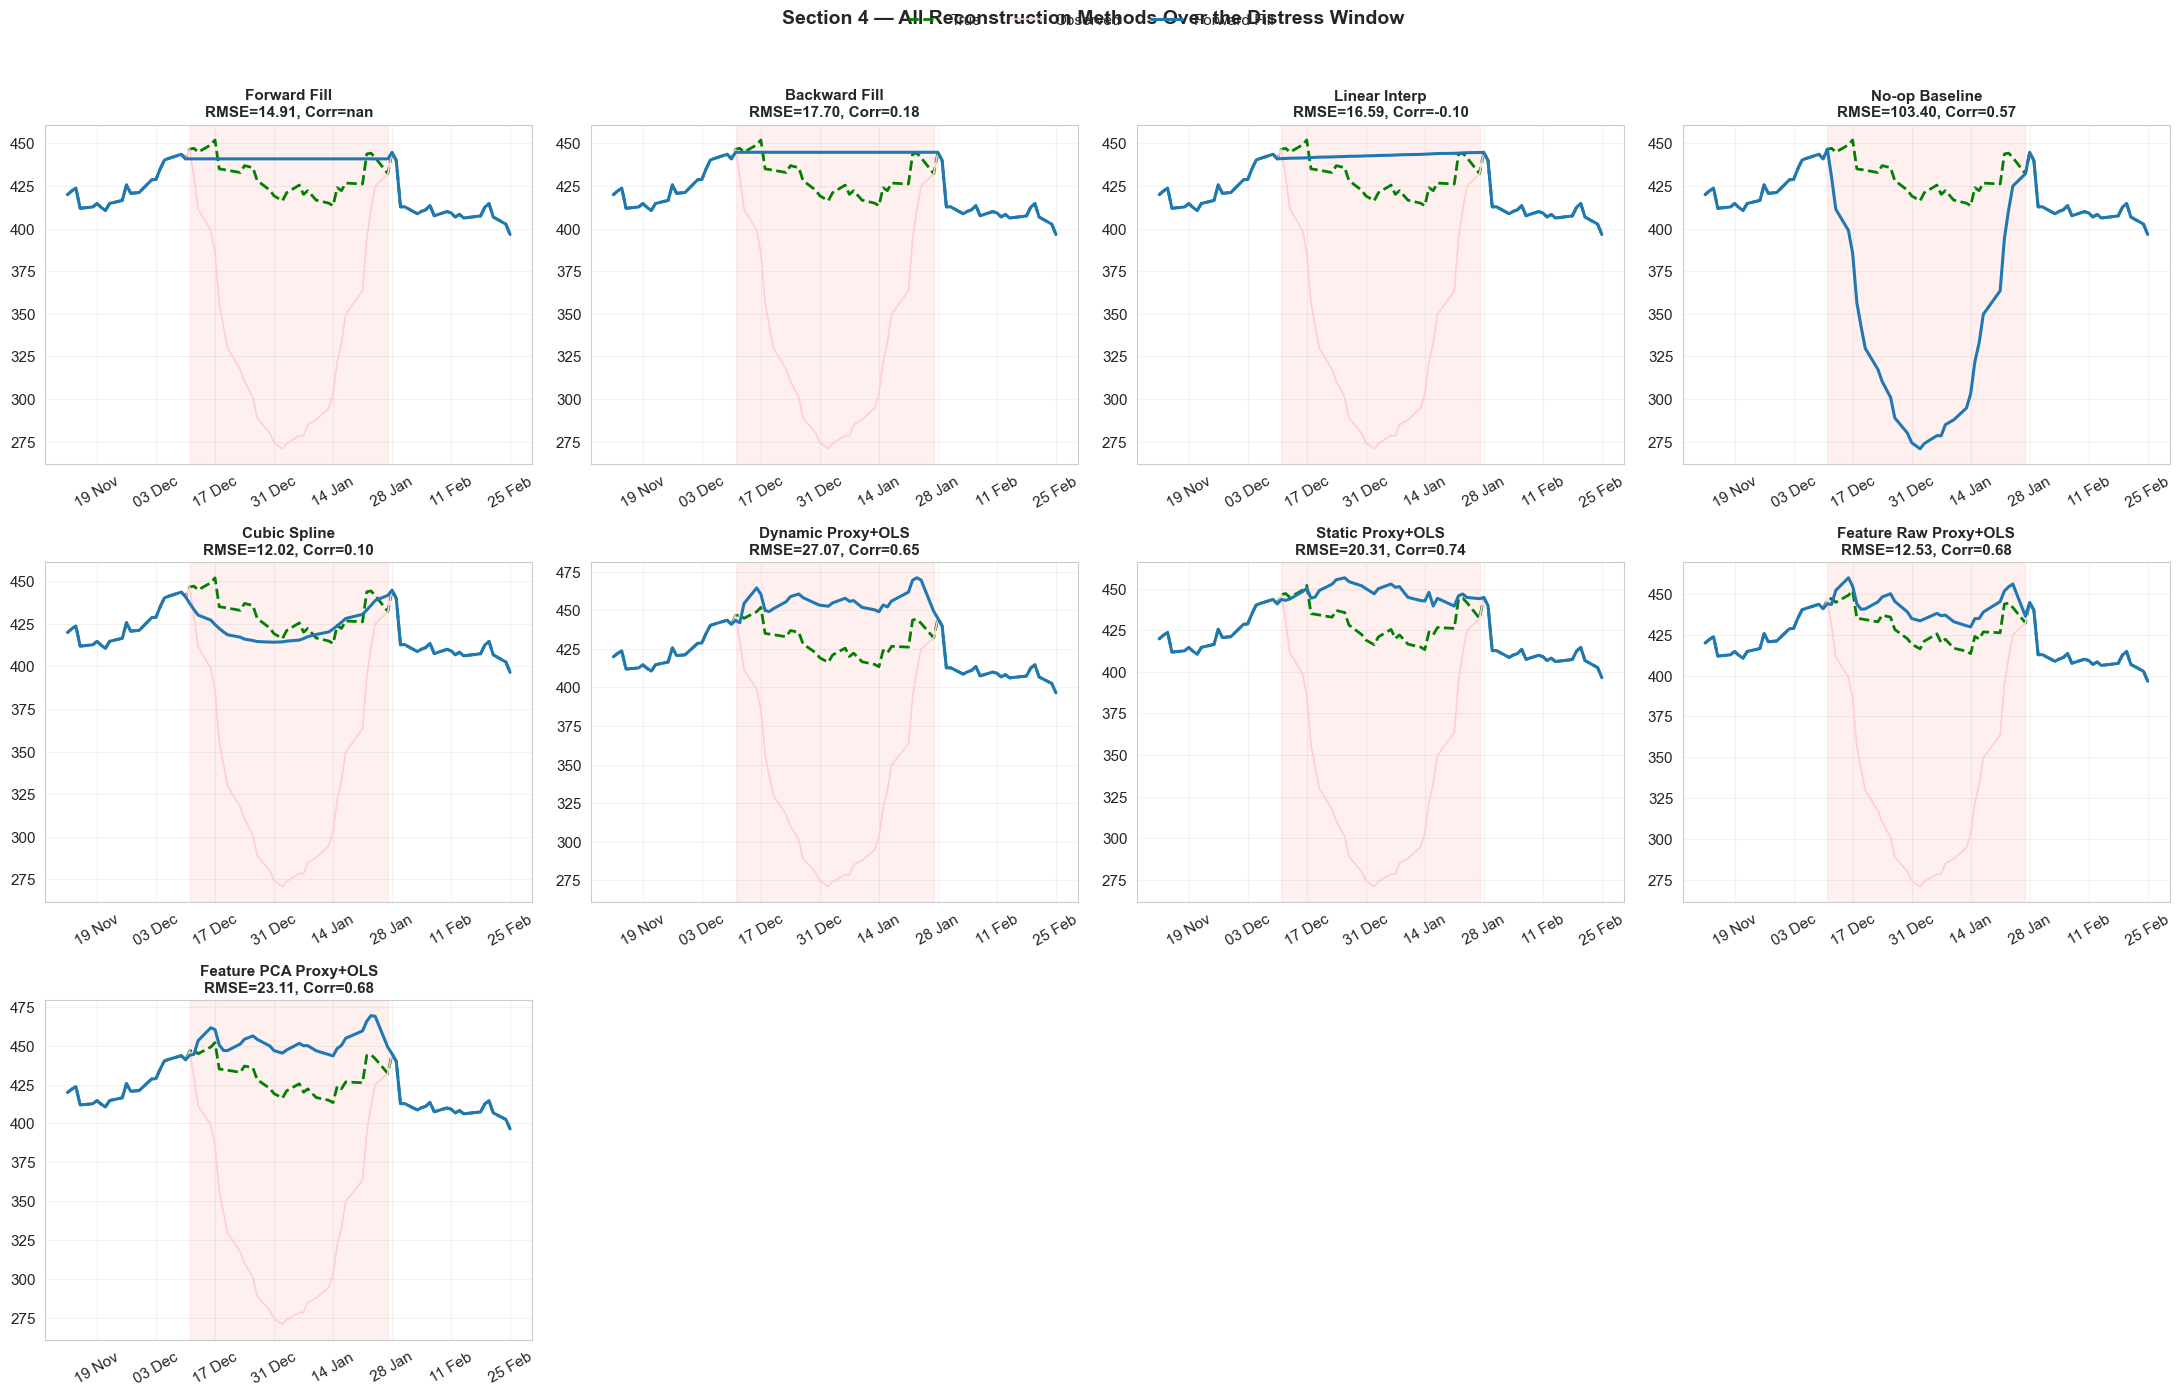

In [49]:
# Build one summary table so all reconstruction methods can be compared

summary_rows = []
for name, series in recon.items():
    pred = series.iloc[DIST_START:DIST_END].values
    true = P['DIST_TRUE'].iloc[DIST_START:DIST_END].values
    pred_ret = np.log(series.iloc[DIST_START:DIST_END].values / series.iloc[DIST_START - 1:DIST_END - 1].values)
    true_ret = np.log(P['DIST_TRUE'].iloc[DIST_START:DIST_END].values / P['DIST_TRUE'].iloc[DIST_START - 1:DIST_END - 1].values)

    # Store several error measures for this method
    summary_rows.append({
        'Method': name,
        'RMSE': np.sqrt(mean_squared_error(true, pred)),
        'MAE': np.mean(np.abs(true - pred)),
        'Max AE': np.max(np.abs(true - pred)),
        'Return Corr': np.corrcoef(pred_ret, true_ret)[0, 1],
        'Final Gap': pred[-1] - true[-1],
    })

summary_df = pd.DataFrame(summary_rows).sort_values('RMSE').reset_index(drop=True)
display(summary_df.style.format({
    'RMSE': '{:.3f}', 'MAE': '{:.3f}', 'Max AE': '{:.3f}',
    'Return Corr': '{:.3f}', 'Final Gap': '{:.3f}'
}).background_gradient(cmap='RdYlGn_r', subset=['RMSE', 'MAE', 'Max AE'])
  .background_gradient(cmap='RdYlGn', subset=['Return Corr']))

print('Ranking by RMSE:')
for i, row in summary_df.iterrows():
    print(f"{i + 1:2d}. {row['Method']:<24} RMSE={row['RMSE']:.3f}  MAE={row['MAE']:.3f}  Corr={row['Return Corr']:.4f}")

zoom_start = max(0, DIST_START - 20)
zoom_end = min(len(dates), DIST_END + 20)

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
plot_methods = list(recon.keys())
for ax, method in zip(axes.flat, plot_methods):
    # Each panel shows one method against the true and observed series
    ax.plot(dates[zoom_start:zoom_end], P['DIST_TRUE'].iloc[zoom_start:zoom_end], 'g--', lw=2, label='True')
    ax.plot(dates[zoom_start:zoom_end], P['DIST_OBS'].iloc[zoom_start:zoom_end], color='#FFCDD2', lw=1.2, label='Observed')
    ax.plot(dates[zoom_start:zoom_end], recon[method].iloc[zoom_start:zoom_end], lw=2.2, label=method)
    ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.06)
    rmse_val = summary_df.loc[summary_df['Method'] == method, 'RMSE'].iloc[0]
    corr_val = summary_df.loc[summary_df['Method'] == method, 'Return Corr'].iloc[0]
    ax.set_title(f'{method}\nRMSE={rmse_val:.2f}, Corr={corr_val:.2f}', fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
    ax.grid(alpha=0.25)

for ax in axes.flat[len(plot_methods):]:
    ax.axis('off')

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle('Section 4 — All Reconstruction Methods Over the Distress Window',
             fontweight='bold', fontsize=14, y=0.995)
plt.show()

### How to Read the Section 4 Comparison Graph

This large comparison figure is the notebook's visual scoreboard for all reconstruction methods.

### What it shows

Each small panel shows one reconstruction method against the same true and observed series over the distress window.
The panel title also reports that method's RMSE and return correlation.

### Why we use it

After studying each method separately, we need one place where we can compare them all on equal footing.
This helps answer: **which methods are only interesting in theory, and which ones actually reconstruct the missing path better?**

### How to read it

1. Do not jump across all panels at once. Start by comparing each method to the dashed true line inside its own panel.
2. Then compare titles: lower RMSE and higher correlation are better.
3. Look for systematic patterns:

- methods that stay close in level but miss turning points
- methods that match the shape but drift in price level
- methods that clearly fail under restructuring assumptions

4. Compare mechanical methods against proxy methods to see whether the extra modelling complexity produced a real gain.

### How to use the panel titles

- **RMSE** tells you average price error size
- **Correlation** tells you how well the shape matches the true path
- a method can have acceptable correlation but poor RMSE if it gets direction right while drifting in level
- a method can have decent RMSE but poor correlation if it stays near the right level but misses the day-to-day shape

**Debugger tip**

If two methods look visually similar but have noticeably different metrics, the difference is usually coming from a few days with large errors or from return-shape mismatch rather than overall visual appearance.

## Section 5 — Summary & Decision Guide

### Method Comparison at a Glance

| Method | Best For | Avoid When | Key Assumption |
|--------|----------|------------|----------------|
| **Forward fill** | Short gaps (1–2 days), quick fix | Long distress windows | Price is locally constant |
| **Backward fill** | Known future anchor exists | The future point is already post-restructuring | Future price is from the same economic entity |
| **Linear interp** | Smooth, gradual moves | The end point belongs to a new regime | Price changes linearly within one regime |
| **Return winsorizaton** | Any-length spikes, gap removal | Cumulative drift over long series | Extreme returns are errors |
| **No-op baseline** | Compatibility / control | Need actual reconstruction | No transformation is applied |
| **Cubic spline** | Smooth trajectory, medium-length gaps | Post-window anchors belong to the restructured stock | Smooth underlying trajectory with consistent anchors |
| **Static Proxy+OLS** | Legacy distress windows with stable peer relationships | Peer relationships change materially inside the window | One fixed legacy peer basket remains representative |
| **Dynamic Proxy+OLS** | Legacy distress windows with genuinely time-varying peer relationships | Daily re-selection adds noise without improving fit | Recent legacy peer relationships must be re-estimated often |
| **Feature PCA Proxy+OLS** | Cluster proxy models with many overlapping peer signals | Too little data to estimate richer features reliably | Multi-horizon peer features contain signal that PCA can compress cleanly |

### Decision Flowchart

```
Is it a multi-day distress window?
├── YES → Does the issuer restructure after the event?
│         ├── YES → Treat post-event data as a new stock regime
│         │         → Avoid unquestioned post-event anchors
│         └── NO  → Continue with interpolation / proxy choices
├── Are there clean, correlated peer stocks available?
│    ├── YES → Check cluster size and peer stability inside the legacy window
│    │         → Stable small peer basket: use Static Proxy+OLS
│    │         → Drifting peers: use Dynamic Proxy+OLS
│    │         → Rich overlapping cluster features: try Feature PCA Proxy+OLS
│    └── NO  → Is the window short (< 5 days)?
│               ├── YES → Forward Fill or a clearly labelled mechanical benchmark
│               └── NO  → Use caution: interpolation may mix regimes
└── Do you need to preserve the legacy economic interpretation?
     ├── YES → Use a pre-restructuring proxy method
     └── NO  → Mechanical methods may still be plotted as rough benchmarks
```

### Key Practical Insights

1. **Distress reconstruction is distinct from regime interpretation**. Always separate legacy-window reconstruction from post-restructuring behavior.

2. **A restructuring can create a new statistical asset**. Once leverage, business mix, or sector exposure changes materially, post-event observations should not automatically be used as anchors for the legacy stock.

3. **Mechanical methods become weaker under regime breaks**. Backward fill, linear interpolation, and spline methods all rely on continuity assumptions that may fail after restructuring.

4. **Static vs dynamic is an empirical question, not a slogan**. In this notebook, the static legacy peer basket can outperform daily re-selection when peer relationships are stable enough that daily re-clustering adds noise.

5. **Feature engineering helps when returns alone are too thin**. Multi-horizon momentum and volatility features let the proxy model capture richer peer behaviour than a one-day return can provide.

6. **PCA is useful when selected features overlap heavily**. It compresses several correlated signals into a few orthogonal components, which can stabilise regression and reduce overfitting.

7. **Proxy quality still dominates model quality**. Even a perfect regression cannot help if chosen peers are poor economic matches.

8. **Use only information available at the time**. Each daily prediction should be based on returns observed up to the prior day, plus any previously reconstructed target returns.

9. **Evaluate against the reference series when possible**. Use RMSE and correlation to rank methods objectively in controlled experiments.

## Section 6 — Time-Series Backtesting of the Proposed Methods

So far we judged each reconstruction method by **statistical accuracy**: RMSE, MAE, and return correlation versus the clean legacy reference path (`DIST_TRUE`).
That is useful, but in practice a quant also asks a second question:

> **If I used this cleaned or reconstructed series inside a trading strategy, how much would my backtest change?**

This section builds a small **time-series backtester** to answer that question.

### Backtesting idea used here

We use a very simple **time-series momentum** rule on DIST:

1. Compute a 5-day momentum signal from each method's reconstructed price series.
2. Convert that into a trading position:
   - `+1` if momentum is positive
   - `-1` if momentum is negative
   - `0` if it is exactly flat
3. Shift the position by one day so the strategy only trades using information available at the close of the prior day.
4. Apply that position to the **reference next-day DIST return** from the scenario setup.

Why do we use the reference next-day return for realised PnL?

Because this notebook runs a controlled real-data-driven AAPL scenario. We want to isolate the effect of **input data quality** on the strategy signal.
If a reconstruction method produces a bad cleaned series, it can generate the wrong signal even when we evaluate against the same reference legacy process.

### Measures reported

We report two groups of metrics:

#### A. Prediction-quality measures during the distressed window

- **Price RMSE**: how far the reconstructed prices are from the reference legacy prices
- **Return correlation**: whether the reconstructed return shape matches the reference return shape
- **Sign accuracy**: how often the reconstructed return gets the direction right

#### B. Backtest measures

- **Total return**: final compounded strategy return
- **Annualised return**: yearly growth rate implied by the strategy
- **Annualised volatility**: yearly risk level
- **Sharpe ratio**: return per unit of volatility
- **Max drawdown**: worst peak-to-trough loss
- **Hit rate**: fraction of days with positive strategy return
- **Average turnover**: how often the strategy changes position
- **Tracking error vs oracle**: how far each strategy drifts from the strategy built on the reference clean series

### Important caveat

This is a **teaching backtester**, not a production execution engine.
Some earlier reconstruction methods use future anchor information, so they should not be interpreted as fully tradable live signals. The purpose here is to show how data cleaning quality flows through to downstream backtest results.

,Method,Price RMSE,Return Corr,Sign Acc,Total Return,Ann Return,Ann Vol,Sharpe,Max Drawdown,Hit Rate,Avg Turnover,Tracking Error
0,Observed,103.395,0.570,0.633,-13.710%,-7.163%,22.236%,-0.222,-25.727%,0.508,0.386,11.333%
1,No-op Baseline,103.395,0.570,0.633,-13.710%,-7.163%,22.236%,-0.222,-25.727%,0.508,0.386,11.333%
2,Linear Interp,16.594,-0.105,0.400,-13.797%,-7.210%,22.236%,-0.225,-25.802%,0.496,0.386,5.567%
3,Backward Fill,17.700,0.174,0.033,-13.670%,-7.140%,21.628%,-0.234,-25.692%,0.480,0.378,5.163%
4,Oracle Truth,0.000,1.000,1.000,-14.432%,-7.555%,22.236%,-0.242,-26.348%,0.506,0.402,0.000%
5,Forward Fill,14.905,nan,0.000,-14.074%,-7.360%,21.477%,-0.248,-26.040%,0.476,0.386,5.990%
6,Cubic Spline,12.021,0.097,0.533,-15.045%,-7.889%,22.235%,-0.258,-26.875%,0.506,0.386,11.502%
7,Feature PCA Proxy+OLS,23.107,0.678,0.800,-19.713%,-10.475%,22.232%,-0.386,-30.893%,0.502,0.402,5.014%
8,Feature Raw Proxy+OLS,12.533,0.682,0.700,-20.004%,-10.640%,22.231%,-0.394,-31.144%,0.506,0.402,5.088%
9,Dynamic Proxy+OLS,27.069,0.647,0.767,-20.715%,-11.040%,22.231%,-0.415,-31.756%,0.502,0.402,5.263%


Time-series backtester uses a 5-day momentum signal with a 1-day execution lag.
Top methods by Sharpe ratio:
        Method  Sharpe  Total Return  Max Drawdown  Tracking Error
      Observed -0.2223       -0.1371       -0.2573          0.1133
No-op Baseline -0.2223       -0.1371       -0.2573          0.1133
 Linear Interp -0.2249       -0.1380       -0.2580          0.0557
 Backward Fill -0.2338       -0.1367       -0.2569          0.0516
  Oracle Truth -0.2416       -0.1443       -0.2635          0.0000
  Forward Fill -0.2481       -0.1407       -0.2604          0.0599


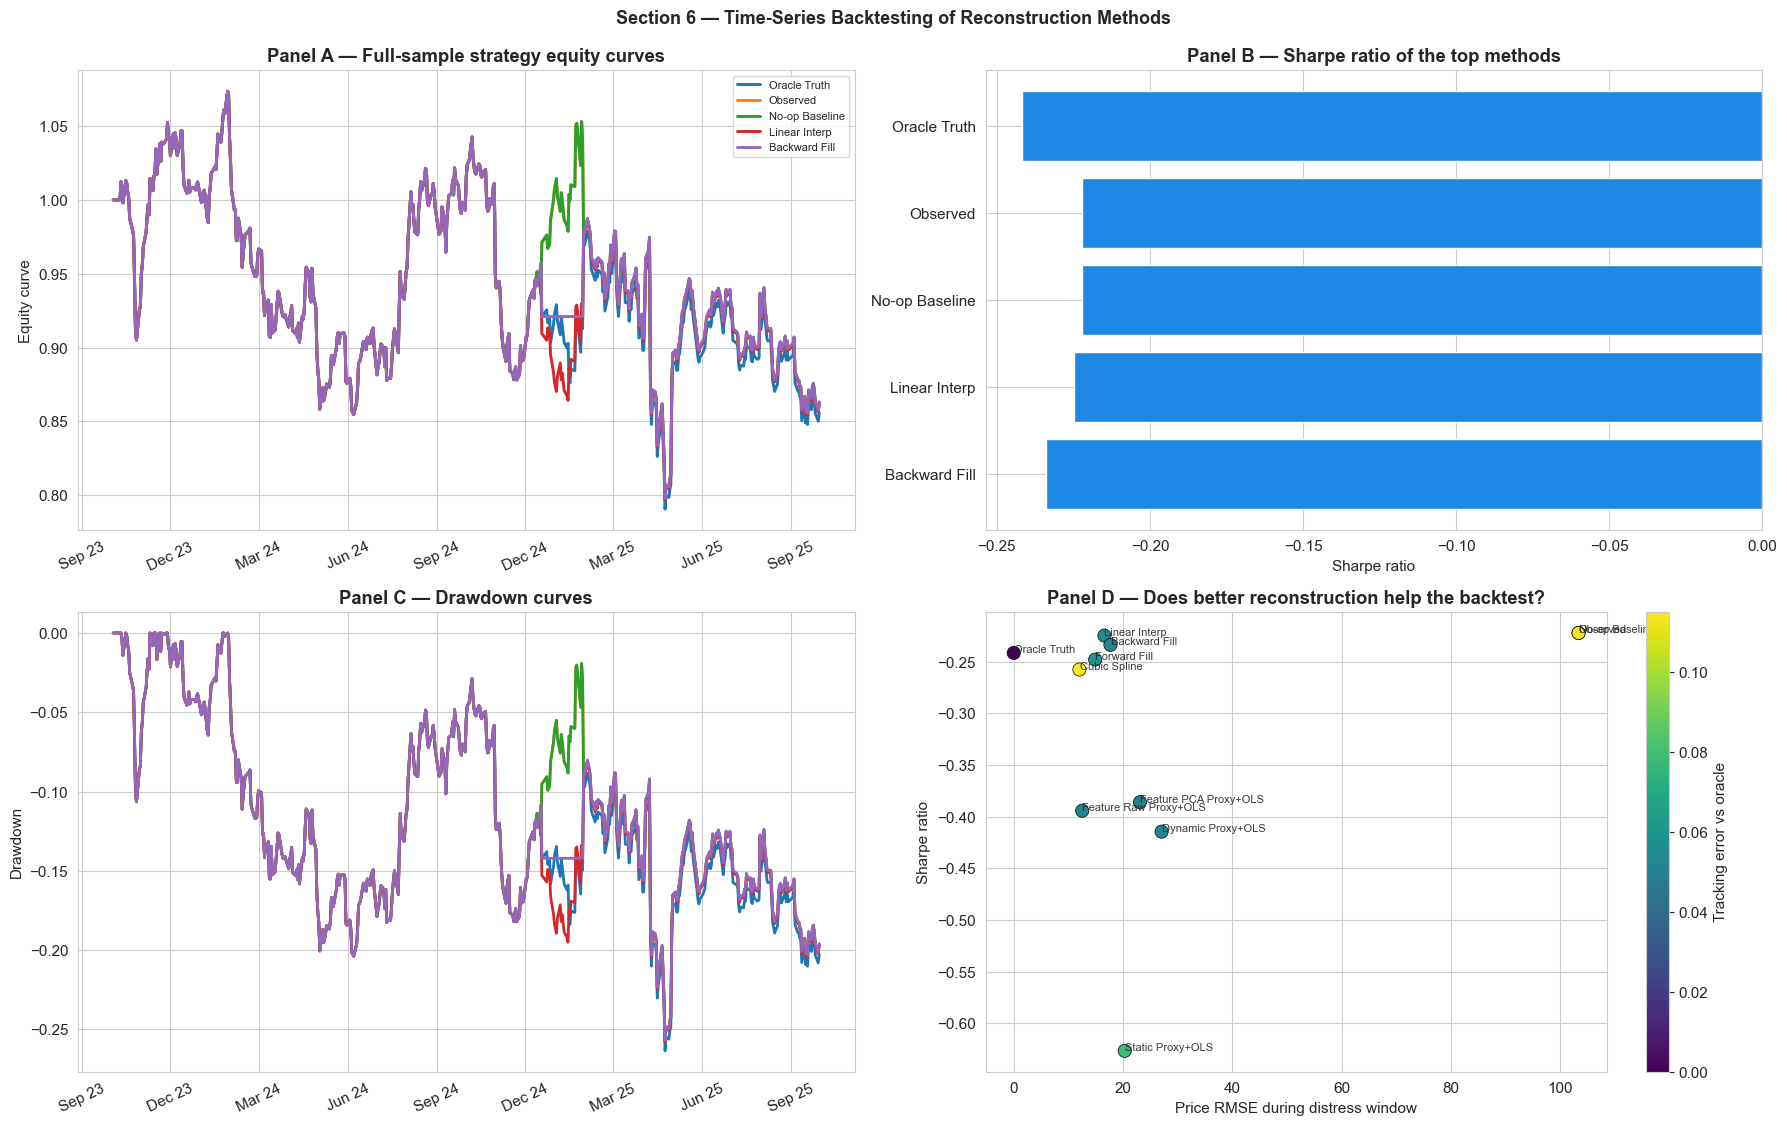

In [50]:
# Build a simple time-series backtester to see how reconstruction quality changes strategy results

BT_LOOKBACK = 5
BT_ANN_FACTOR = 252
bt_true_price = P['DIST_TRUE'].copy()
bt_true_ret = bt_true_price.pct_change().fillna(0.0)

bt_method_series = {'Observed': P['DIST_OBS'], **recon, 'Oracle Truth': P['DIST_TRUE']}

def build_ts_momentum_signal(price_series, lookback=5):
    # Positive recent momentum -> long, negative momentum -> short
    momentum = price_series.pct_change(lookback)
    signal = np.sign(momentum).shift(1).fillna(0.0)
    return signal

def max_drawdown_from_returns(return_series):
    # Convert returns into an equity curve, then measure the worst drawdown
    equity_curve = (1.0 + return_series.fillna(0.0)).cumprod()
    running_peak = equity_curve.cummax()
    drawdown = equity_curve / running_peak - 1.0
    return drawdown.min(), drawdown

def annualised_return(return_series, ann_factor=252):
    valid = return_series.dropna()
    if len(valid) == 0:
        return np.nan
    equity_final = (1.0 + valid).prod()
    return equity_final ** (ann_factor / len(valid)) - 1.0

def sharpe_ratio(return_series, ann_factor=252):
    valid = return_series.dropna()
    vol = valid.std()
    if len(valid) == 0 or pd.isna(vol) or vol == 0:
        return np.nan
    return valid.mean() / vol * np.sqrt(ann_factor)

def sign_accuracy(pred_ret, true_ret):
    aligned = pd.concat([pred_ret, true_ret], axis=1).dropna()
    aligned.columns = ['pred', 'true']
    if aligned.empty:
        return np.nan
    return (np.sign(aligned['pred']) == np.sign(aligned['true'])).mean()

oracle_signal = build_ts_momentum_signal(bt_true_price, lookback=BT_LOOKBACK)
oracle_strategy_ret = oracle_signal * bt_true_ret

bt_rows = []
bt_equity_curves = {}
bt_drawdowns = {}

for method_name, method_series in bt_method_series.items():
    method_ret = method_series.pct_change().fillna(0.0)
    signal = build_ts_momentum_signal(method_series, lookback=BT_LOOKBACK)
    strategy_ret = signal * bt_true_ret

    total_return = (1.0 + strategy_ret).prod() - 1.0
    ann_return = annualised_return(strategy_ret, ann_factor=BT_ANN_FACTOR)
    ann_vol = strategy_ret.std() * np.sqrt(BT_ANN_FACTOR)
    sharpe = sharpe_ratio(strategy_ret, ann_factor=BT_ANN_FACTOR)
    max_dd, drawdown = max_drawdown_from_returns(strategy_ret)
    hit_rate = (strategy_ret > 0).mean()
    avg_turnover = signal.diff().abs().fillna(0.0).mean()
    tracking_error = (strategy_ret - oracle_strategy_ret).std() * np.sqrt(BT_ANN_FACTOR)

    pred_price = method_series.iloc[DIST_START:DIST_END].values
    true_price = bt_true_price.iloc[DIST_START:DIST_END].values
    pred_ret_window = method_ret.iloc[DIST_START:DIST_END]
    true_ret_window = bt_true_ret.iloc[DIST_START:DIST_END]
    return_corr = np.corrcoef(pred_ret_window, true_ret_window)[0, 1]
    price_rmse = np.sqrt(mean_squared_error(true_price, pred_price))
    dir_acc = sign_accuracy(pred_ret_window, true_ret_window)

    bt_rows.append({
        'Method': method_name,
        'Price RMSE': price_rmse,
        'Return Corr': return_corr,
        'Sign Acc': dir_acc,
        'Total Return': total_return,
        'Ann Return': ann_return,
        'Ann Vol': ann_vol,
        'Sharpe': sharpe,
        'Max Drawdown': max_dd,
        'Hit Rate': hit_rate,
        'Avg Turnover': avg_turnover,
        'Tracking Error': tracking_error,
    })

    bt_equity_curves[method_name] = (1.0 + strategy_ret).cumprod()
    bt_drawdowns[method_name] = drawdown

backtest_df = pd.DataFrame(bt_rows).sort_values('Sharpe', ascending=False).reset_index(drop=True)
display(backtest_df.style.format({
    'Price RMSE': '{:.3f}',
    'Return Corr': '{:.3f}',
    'Sign Acc': '{:.3f}',
    'Total Return': '{:.3%}',
    'Ann Return': '{:.3%}',
    'Ann Vol': '{:.3%}',
    'Sharpe': '{:.3f}',
    'Max Drawdown': '{:.3%}',
    'Hit Rate': '{:.3f}',
    'Avg Turnover': '{:.3f}',
    'Tracking Error': '{:.3%}',
}).background_gradient(cmap='RdYlGn_r', subset=['Price RMSE', 'Tracking Error'])
  .background_gradient(cmap='RdYlGn', subset=['Return Corr', 'Sign Acc', 'Total Return', 'Ann Return', 'Sharpe', 'Hit Rate'])
  .background_gradient(cmap='RdYlGn_r', subset=['Ann Vol'])
  .background_gradient(cmap='RdYlGn', subset=['Max Drawdown']))

print(f'Time-series backtester uses a {BT_LOOKBACK}-day momentum signal with a 1-day execution lag.')
print('Top methods by Sharpe ratio:')
print(backtest_df[['Method', 'Sharpe', 'Total Return', 'Max Drawdown', 'Tracking Error']]
      .head(6)
      .round(4)
      .to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

ax = axes[0, 0]
top_methods = backtest_df['Method'].head(5).tolist()
plot_methods = ['Oracle Truth'] + [m for m in top_methods if m != 'Oracle Truth']
for method_name in plot_methods:
    ax.plot(bt_equity_curves[method_name].index, bt_equity_curves[method_name].values, lw=2.1, label=method_name)
ax.set_title('Panel A — Full-sample strategy equity curves', fontweight='bold')
ax.set_ylabel('Equity curve')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

ax = axes[0, 1]
bar_df = backtest_df.set_index('Method').loc[plot_methods[::-1]]
ax.barh(bar_df.index, bar_df['Sharpe'], color='#1E88E5')
ax.set_title('Panel B — Sharpe ratio of the top methods', fontweight='bold')
ax.set_xlabel('Sharpe ratio')

ax = axes[1, 0]
for method_name in plot_methods:
    ax.plot(bt_drawdowns[method_name].index, bt_drawdowns[method_name].values, lw=2.0, label=method_name)
ax.set_title('Panel C — Drawdown curves', fontweight='bold')
ax.set_ylabel('Drawdown')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

ax = axes[1, 1]
scatter = ax.scatter(backtest_df['Price RMSE'], backtest_df['Sharpe'],
                     c=backtest_df['Tracking Error'], cmap='viridis', s=90,
                     edgecolor='black', linewidth=0.5)
for _, row in backtest_df.iterrows():
    ax.text(row['Price RMSE'] + 0.02, row['Sharpe'], row['Method'], fontsize=8, alpha=0.9)
ax.set_title('Panel D — Does better reconstruction help the backtest?', fontweight='bold')
ax.set_xlabel('Price RMSE during distress window')
ax.set_ylabel('Sharpe ratio')
plt.colorbar(scatter, ax=ax, label='Tracking error vs oracle')

plt.tight_layout()
plt.suptitle('Section 6 — Time-Series Backtesting of Reconstruction Methods',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

### How to Read the Section 6 Backtesting Graphs

This figure answers a different question from the earlier sections.
Earlier plots asked: **which method reconstructs the series better?**
These plots ask: **does better reconstruction actually improve a trading backtest?**

### Panel A — Full-Sample Strategy Equity Curves

**What it shows**

Each line is the growth of 1 unit of capital under the time-series momentum strategy built from a given reconstructed series.

**Why we use it**

This is the most intuitive strategy-performance picture. It shows which methods lead to better compounded trading outcomes over time.

**How to read it**

1. Higher ending equity is better.
2. Smoother upward paths are generally preferable to jagged or steadily falling paths.
3. Compare each method with the oracle truth strategy to see how close it gets to the best possible signal built from perfect data.

### Panel B — Sharpe Ratio Ranking

**What it shows**

A bar chart of Sharpe ratios for the top methods.

**Why we use it**

Total return alone is not enough. Sharpe adjusts for how much volatility the strategy took to earn that return.

**How to read it**

1. Higher Sharpe is better.
2. Methods close together may not be meaningfully different unless the gap is large.
3. A method can have decent total return but weaker Sharpe if it took a rougher path to get there.

### Panel C — Drawdown Curves

**What it shows**

The running drawdown of each strategy over time.

**Why we use it**

Backtests are not only about return. They are also about how painful the losses feel on the way.

**How to read it**

1. Values closer to zero are better.
2. Deeper troughs mean worse peak-to-trough losses.
3. A method with similar return but much smaller drawdown may be more attractive in practice.

### Panel D — Reconstruction Quality vs Backtest Quality

**What it shows**

A scatter plot relating price RMSE during the missing window to Sharpe ratio, with colour showing tracking error versus the oracle strategy.

**Why we use it**

This is the link between the data-cleaning problem and the trading problem. It checks whether better reconstruction actually translates into a better strategy.

**How to read it**

1. Points farther left have lower reconstruction error.
2. Points higher up have better Sharpe ratio.
3. Better methods tend to sit toward the upper-left.
4. The colour tells you how far the strategy's returns drift from the oracle truth strategy.

**Debugger tip**

If a method has good RMSE but weak Sharpe, reconstruction quality may be improving the level of the series without improving the timing of the trading signal.